# **COREPULSE**


# **Proceso técnico de preparación de datos**

## 🔧 **1. Preparación de fuentes de datos.**

🎯 **Objetivo del script**

El primer paso del pipeline consiste en preparar y alinear las fuentes de datos que servirán como base para el cuadro de mando final. En esta fase no se construye todavía la tabla de hechos definitiva ni se seleccionan los productos que formarán parte del análisis, sino que se realiza una depuración estructural previa que garantiza que los siguientes pasos trabajen sobre un conjunto de datos coherente.

Este script tiene como finalidad principal:

- definir un universo válido de productos a partir del catálogo enriquecido,
- preparar el histórico de ventas que se utilizará como base del análisis,
- preparar la previsión de demanda bajo distintos escenarios,
- unificar el marco temporal del proyecto,
- y excluir productos que no puedan relacionarse correctamente con la futura dimensión de producto.


> En términis prácticos, este script deja listas las fuentes intermedias necesarias para:

1. seleccionar posteriormente el subconjunto final de productos del dashboard,
2. construir la fact table final,construir la fact table final,
3. y filtrar la dimensión producto de forma consistente.y filtrar la dimensión producto de forma consistente.



🧠 **Lógica aplicada**

El script realiza las siguientes transformaciones:

**1. Definición del universo válido de productos.**

Se toma como referencia el archivo catalog_items_enriquecido.csv, que actúa como base operativa de la futura dimensión de producto. A partir de él se obtiene el conjunto de Product_ID válidos sobre los que se construirá el análisis.

**2.  Preparación del histórico**

A partir de dataset_ml_ready.parquet se:

- elimina el año 2022,
- se conserva únicamente el histórico originalmente correspondiente a 2023 y 2024,
- y se renombra el eje temporal para adaptarlo al marco narrativo del dashboard:
    - 2023 → 2024
    - 2024 → 2025

De este modo, el cuadro de mando trabajará con un histórico visible de ventas para 2024 y 2025.

3. **Preparación de la previsión**

A partir de los archivos de predicción se construye la previsión futura:

- escenario base: predicciones_2025_estacional.parquet
- escenario optimista: predicciones_2025_optimista.parquet
- escenario pesimista: predicciones_2025_pesimista.parquet

Estas predicciones, originalmente calculadas para 2025, se desplazan temporalmente para que el dashboard trabaje con:

- 2025 → 2026

Así, la previsión pasa a representar el ejercicio futuro completo de 2026.

4. **Exclusión de productos fuera de catálogo.**

Se eliminan todos los productos presentes en el histórico o en la previsión que no existan en el catálogo enriquecido. Esta decisión evita inconsistencias posteriores en el modelo estrella y garantiza que toda fila de la fact final pueda relacionarse con su dimensión de producto.

🔍 **Validaciones aplicadas**

En esta fase se han aplicado validaciones técnicas y estructurales, no todavía validaciones de negocio o analíticas avanzadas. El objetivo aquí era asegurar que las fuentes quedaran correctamente alineadas antes de pasar a la selección de productos y a la construcción del modelo final.

1. **Validación de existencia de archivos de entrada**

Antes de iniciar el procesamiento, el script comprueba que estén disponibles todos los archivos necesarios en la ruta de trabajo. Esta validación evita errores silenciosos derivados de nombres incorrectos, archivos movidos o ausencia de alguna fuente clave.

2. **Validación de columnas obligatorias**

Se revisa que tanto el histórico como los archivos de previsión contengan las columnas mínimas necesarias para continuar con el pipeline, como por ejemplo:

- product_id
- date
- sales_quantity
- precio_medio
- cluster_id
- y_pred_estacional en el caso de la previsión

Esta validación garantiza que la lógica posterior no dependa de supuestos implícitos ni falle por cambios en la estructura de los archivos.

3. **Normalización del identificador de producto**

Los identificadores de producto se normalizan para evitar diferencias de formato entre archivos, como:

- enteros frente a strings,
- presencia de espacios,
- sufijos .0,
- o valores nulos codificados de formas distintas.

Esta validación es importante porque el Product_ID será la clave de relación principal entre las tablas del modelo.

4. **Validación temporaL**

Se comprueba que el histórico y la previsión queden correctamente reubicados tras el cambio de fechas. Esta fase era especialmente delicada porque el dashboard va a trabajar con una cronología reetiquetada respecto a la del proyecto original.

5. **Ajuste por año bisiesto**

Al desplazar 2024 a 2025 surgía un problema técnico: el 29/02/2024 no existe en 2025 y podía generar colisiones de fecha al transformarse. Para evitar duplicados artificiales por la clave product_id + date, se eliminó previamente ese día.

Dado que el análisis final se construirá a nivel semanal, esta decisión no compromete la calidad analítica del dashboard y evita inconsistencias estructurales posteriores.

6. **Validación de duplicados por clave natural**

Una vez transformadas las fechas, se valida que no existan duplicados para la combinación:

- product_id
- date

Esta comprobación es fundamental porque garantiza que cada producto tenga una única observación por fecha dentro de cada fuente preparada.

7.**Validación de coherencia entre catálogo y hechos**

Se verifica que el universo de productos usado en históricos y previsión coincida con el universo del catálogo enriquecido, excluyendo aquellos casos que no puedan enlazarse correctamente con la dimensión.

🗂️ **Outputs obtenidos**

Los outputs generados por el script fueron los siguientes:

- ventas_2024_2025_preparadas.parquet
- forecast_2026_preparado.parquet
- product_ids_validos_catalogo.csv
- product_ids_excluidos_catalogo.csv
- resumen_preparacion_fuentes.csv

1. **Universo válido de productos**

El catálogo enriquecido define un universo de 3562 productos válidos.

2. **Producto exlcuidos** 

Se detectaron y excluyeron 34 productos. Estos productos aparecían en históricos o previsiones, pero no estaban presentes en el catálogo enriquecido, por lo que no podían integrarse de forma consistente en el modelo dimensional.

3. **Histórico preparado**

El histórico final quedó con:

- 2.600.260 filas
- 3562 productos
- rango temporal desde 2024-01-01 hasta 2025-12-31

Este resultado es coherente con dos años completos de observación para 3562 productos.

3. **Forecast preparado**

La previsión final quedó con:

- 1.300.130 filas
- 3562 productos
- rango temporal desde 2026-01-01 hasta 2026-12-31

Este resultado es coherente con un año completo de previsión para los mismos productos válidos.

✅ **Interpretación y validez de los resultados**.

Los resultados obtenidos se consideran válidos a nivel estructural y técnico por varias razones.

1. **Coherencia entre número de productos y número de filas**.

Los volúmenes generados encajan exactamente con lo esperado tras la exclusión de productos y la reubicación temporal, lo que refuerza la idea de que no han quedado duplicados ni pérdidas inesperadas de información.

2. **Alineación correcta entre hechos y catálogo**.

El hecho de que histórico y forecast trabajen ya sobre el mismo universo de 3562 productos garantiza que los siguientes pasos puedan construirse sin conflictos de relación con la dimensión de producto.

3. **Rango temporal correctamente transformado**.

Los periodos resultantes reflejan exactamente el marco temporal deseado para el dashboard:

- ventas reales: 2024–2025
- previsión: 2026

Esto confirma que el cambio de fechas se aplicó correctamente.

4. **Eliminación controlada del problema del año bisiesto**.

La colisión del 29 de febrero quedó resuelta sin introducir duplicados artificiales, lo que permite continuar con una base limpia y consistente.

> Es importante señalar que esta fase no valida todavía la calidad analítica o de negocio del dataset. Es decir, en este punto aún no se ha evaluado, por ejemplo:
- si hay productos con comportamiento extremo o poco representativo,
- si algún clúster está infrarrepresentado,
- si precio_medio presenta valores anómalos,
- si ciertos productos conviene o no incluir en el dashboard final,
- o si los escenarios optimista y pesimista aportan valor para todos los productos.



In [ ]:
"""
===============================================================================
SCRIPT: 01_preparar_fuentes_dashboard.py
===============================================================================
DESCRIPCIÓN
-----------
Prepara y alinea las fuentes base del cuadro de mando para el proyecto final de
Cívica, dejando listas las tablas intermedias que servirán para:

1) Seleccionar el subconjunto final de productos del dashboard.
2) Construir la fact table final.
3) Filtrar posteriormente la dimensión de producto.

FLUJO DEL PIPELINE
------------------
1. Cargar el catálogo enriquecido para obtener el universo válido de Product_ID.
2. Cargar el histórico de ventas/demanda ya preparado para ML.
3. Eliminar el año 2022 del histórico.
4. Renombrar el histórico:
      - 2023 -> 2024
      - 2024 -> 2025
5. Cargar las predicciones de 2025 (base, optimista y pesimista).
6. Renombrar la previsión:
      - 2025 -> 2026
7. Excluir los productos presentes en históricos/predicciones pero ausentes del
   catálogo enriquecido.
8. Guardar:
      - histórico preparado 2024-2025
      - forecast preparado 2026 con escenarios en columnas
      - listado de Product_ID válidos
      - listado de Product_ID excluidos
      - resumen de preparación

INPUT ESPERADO (data/raw)
-------------------------
- dataset_ml_ready.parquet
- predicciones_2025_estacional.parquet
- predicciones_2025_optimista.parquet
- predicciones_2025_pesimista.parquet
- catalog_items_enriquecido.csv

OUTPUT ESPERADO (data/interim)
------------------------------
- ventas_2024_2025_preparadas.parquet
- forecast_2026_preparado.parquet
- product_ids_validos_catalogo.csv
- product_ids_excluidos_catalogo.csv
- resumen_preparacion_fuentes.csv

DEPENDENCIAS
------------
- pandas
- pyarrow
- openpyxl
- numpy

INSTALACIÓN RÁPIDA
------------------
pip install pandas pyarrow openpyxl numpy

NOTAS
-----
- Este script NO construye todavía la fact final semanal.
- Este script NO selecciona todavía los productos finales del dashboard.
- La selección de productos se hará en un script posterior.
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

# -------------------------------------------------------------------------
# IMPORTANTE:
# Se fija explícitamente la raíz del proyecto para evitar que el script tome
# por error la ruta de .venv u otras carpetas de ejecución.
# -------------------------------------------------------------------------
ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

HIST_FILE = RAW_DIR / "dataset_ml_ready.parquet"
FORECAST_BASE_FILE = RAW_DIR / "predicciones_2025_estacional.parquet"
FORECAST_OPT_FILE = RAW_DIR / "predicciones_2025_optimista.parquet"
FORECAST_PES_FILE = RAW_DIR / "predicciones_2025_pesimista.parquet"
CATALOG_ENRICHED_FILE = RAW_DIR / "catalog_items_enriquecido.csv"

OUT_HIST_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
OUT_FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
OUT_VALID_IDS_FILE = INTERIM_DIR / "product_ids_validos_catalogo.csv"
OUT_EXCLUDED_IDS_FILE = INTERIM_DIR / "product_ids_excluidos_catalogo.csv"
OUT_SUMMARY_FILE = INTERIM_DIR / "resumen_preparacion_fuentes.csv"

HIST_YEARS_TO_KEEP = [2023, 2024]
HIST_YEAR_SHIFT = 1
FORECAST_YEAR_SHIFT = 1

HIST_KEEP_COLS = [
    "product_id",
    "date",
    "cluster_id",
    "sales_quantity",
    "precio_medio",
    "is_outlier",
]

FORECAST_VALUE_COL_BASE = "y_pred_estacional"


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys
from typing import Iterable, Tuple

import pandas as pd

try:
    import pyarrow.parquet as pq
except ImportError:  # pragma: no cover
    pq = None


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea las carpetas necesarias si no existen."""
    for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Verifica que existan todos los archivos de entrada requeridos."""
    required_files = [
        HIST_FILE,
        FORECAST_BASE_FILE,
        FORECAST_OPT_FILE,
        FORECAST_PES_FILE,
        CATALOG_ENRICHED_FILE,
    ]

    missing = [str(file_path) for file_path in required_files if not file_path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada en data/raw:\n- " + "\n- ".join(missing)
        )


def safe_read_parquet(path: Path) -> pd.DataFrame:
    """
    Lee un parquet de forma robusta.
    """
    try:
        return pd.read_parquet(path)
    except Exception as exc:
        logger.warning(
            "Lectura estándar con pandas falló para %s. Se intentará con pyarrow. "
            "Detalle: %s",
            path.name,
            exc,
        )

        if pq is None:
            raise

        table = pq.read_table(path)
        return table.to_pandas(ignore_metadata=True)


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """
    Normaliza Product_ID / product_id a string homogéneo.
    """
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def shift_years_in_date_column(
    df: pd.DataFrame,
    date_col: str,
    years: int,
) -> pd.DataFrame:
    """Desplaza una fecha un número entero de años."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col]) + pd.DateOffset(years=years)
    return out


def filtrar_years(df: pd.DataFrame, date_col: str, years_to_keep: Iterable[int]) -> pd.DataFrame:
    """Filtra un DataFrame por años concretos."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out[out[date_col].dt.year.isin(years_to_keep)].copy()
    return out


def validar_duplicados(
    df: pd.DataFrame,
    key_cols: list[str],
    dataset_name: str,
) -> None:
    """Valida que no existan duplicados por clave natural."""
    dup_count = df.duplicated(subset=key_cols).sum()
    if dup_count > 0:
        raise ValueError(
            f"Se han detectado {dup_count} duplicados en {dataset_name} "
            f"para la clave {key_cols}."
        )


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión del archivo."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada para exportación: {path.suffix}")


def resumen_basico_fuente(
    df: pd.DataFrame,
    dataset_name: str,
    product_col: str,
    date_col: str,
) -> dict:
    """Devuelve un resumen sencillo y útil del dataset."""
    return {
        "dataset": dataset_name,
        "n_filas": int(len(df)),
        "n_productos": int(df[product_col].nunique(dropna=True)),
        "fecha_min": pd.to_datetime(df[date_col]).min(),
        "fecha_max": pd.to_datetime(df[date_col]).max(),
    }


# =============================================================================
# 3. LÓGICA PRINCIPAL
# =============================================================================

def cargar_product_ids_validos_catalogo(path_catalog: Path) -> set[str]:
    """
    Carga el catálogo enriquecido y devuelve el set de Product_ID válidos.
    """
    logger.info("Cargando catálogo enriquecido: %s", path_catalog.name)
    catalog = pd.read_csv(path_catalog)

    if "Product_ID" not in catalog.columns:
        raise KeyError("El catálogo enriquecido no contiene la columna 'Product_ID'.")

    catalog["Product_ID"] = normalizar_product_id(catalog["Product_ID"])
    catalog = catalog.dropna(subset=["Product_ID"]).copy()

    valid_ids = set(catalog["Product_ID"].unique())

    logger.info("Product_ID válidos en catálogo enriquecido: %s", len(valid_ids))
    return valid_ids


def preparar_historico(
    hist_path: Path,
    valid_ids: set[str],
) -> Tuple[pd.DataFrame, set[str]]:
    """
    Prepara el histórico:
    - elimina 2022
    - renombra 2023 -> 2024
    - renombra 2024 -> 2025
    - filtra Product_ID válidos
    - elimina 29/02/2024 para evitar duplicados artificiales al desplazar fechas
    """
    logger.info("Cargando histórico: %s", hist_path.name)
    hist = safe_read_parquet(hist_path)

    required_cols = {"product_id", "date", "sales_quantity", "precio_medio", "cluster_id"}
    missing = required_cols - set(hist.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en histórico: {missing}")

    hist["product_id"] = normalizar_product_id(hist["product_id"])
    hist["date"] = pd.to_datetime(hist["date"])

    # 1) Mantener solo 2023 y 2024
    hist = filtrar_years(hist, date_col="date", years_to_keep=HIST_YEARS_TO_KEEP)

    # 2) Mantener solo columnas útiles para el dashboard / selección
    keep_cols = [col for col in HIST_KEEP_COLS if col in hist.columns]
    hist = hist[keep_cols].copy()

    # 3) Filtrar solo productos presentes en catálogo enriquecido
    hist_ids_before = set(hist["product_id"].dropna().unique())
    hist = hist[hist["product_id"].isin(valid_ids)].copy()
    hist_ids_after = set(hist["product_id"].dropna().unique())
    excluded_ids = hist_ids_before - hist_ids_after

    # 4) Ajuste por año bisiesto:
    # al desplazar 2024 -> 2025, el 29/02/2024 colisiona con 28/02/2025.
    # Para evitar duplicados artificiales por product_id + date, eliminamos
    # el 29/02/2024 antes del renombrado temporal.
    mask_leap_day = (
        (hist["date"].dt.year == 2024) &
        (hist["date"].dt.month == 2) &
        (hist["date"].dt.day == 29)
    )

    n_leap_rows = int(mask_leap_day.sum())
    if n_leap_rows > 0:
        logger.warning(
            "Se eliminan %s filas correspondientes al 29/02/2024 para evitar "
            "duplicados artificiales al renombrar 2024 -> 2025.",
            n_leap_rows
        )
        hist = hist.loc[~mask_leap_day].copy()

    # 5) Renombrado temporal
    hist = shift_years_in_date_column(hist, date_col="date", years=HIST_YEAR_SHIFT)

    # 6) Limpieza final
    hist = hist.dropna(subset=["product_id", "date"]).copy()
    hist = hist.sort_values(["product_id", "date"]).reset_index(drop=True)

    # 7) Validación final de duplicados
    dup_count = hist.duplicated(subset=["product_id", "date"]).sum()
    if dup_count > 0:
        dup_sample = (
            hist.loc[hist.duplicated(subset=["product_id", "date"], keep=False),
                     ["product_id", "date"]]
            .sort_values(["product_id", "date"])
            .head(10)
        )
        logger.error("Muestra de duplicados detectados en histórico:\n%s", dup_sample)
        raise ValueError(
            f"Se han detectado {dup_count} duplicados en histórico preparado para la clave "
            f"['product_id', 'date']."
        )

    logger.info(
        "Histórico preparado | filas=%s | productos=%s | rango=%s -> %s",
        len(hist),
        hist["product_id"].nunique(),
        hist["date"].min().date(),
        hist["date"].max().date(),
    )

    return hist, excluded_ids


def preparar_forecast_escenario(
    forecast_path: Path,
    valid_ids: set[str],
    output_value_col: str,
) -> Tuple[pd.DataFrame, set[str]]:
    """
    Prepara un escenario de forecast.
    """
    logger.info("Cargando forecast: %s", forecast_path.name)
    fc = safe_read_parquet(forecast_path)

    required_cols = {"product_id", "date", "cluster_id", FORECAST_VALUE_COL_BASE}
    missing = required_cols - set(fc.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en forecast {forecast_path.name}: {missing}")

    fc["product_id"] = normalizar_product_id(fc["product_id"])
    fc["date"] = pd.to_datetime(fc["date"])

    fc = fc[["product_id", "date", "cluster_id", FORECAST_VALUE_COL_BASE]].copy()
    fc = fc.rename(columns={FORECAST_VALUE_COL_BASE: output_value_col})

    fc_ids_before = set(fc["product_id"].dropna().unique())
    fc = fc[fc["product_id"].isin(valid_ids)].copy()
    fc_ids_after = set(fc["product_id"].dropna().unique())
    excluded_ids = fc_ids_before - fc_ids_after

    fc = shift_years_in_date_column(fc, date_col="date", years=FORECAST_YEAR_SHIFT)

    fc = fc.dropna(subset=["product_id", "date"]).copy()
    fc = fc.sort_values(["product_id", "date"]).reset_index(drop=True)

    validar_duplicados(fc, key_cols=["product_id", "date"], dataset_name=f"forecast {output_value_col}")

    logger.info(
        "Forecast %s preparado | filas=%s | productos=%s | rango=%s -> %s",
        output_value_col,
        len(fc),
        fc["product_id"].nunique(),
        fc["date"].min().date(),
        fc["date"].max().date(),
    )

    return fc, excluded_ids


def construir_forecast_combinado(
    forecast_base: pd.DataFrame,
    forecast_opt: pd.DataFrame,
    forecast_pes: pd.DataFrame,
) -> pd.DataFrame:
    """
    Combina los tres escenarios de forecast en una sola tabla.
    """
    logger.info("Combinando escenarios de forecast en una única tabla...")

    forecast = forecast_base.copy()

    forecast_opt_merge = forecast_opt[["product_id", "date", "forecast_optimista"]].copy()
    forecast_pes_merge = forecast_pes[["product_id", "date", "forecast_pesimista"]].copy()

    forecast = forecast.merge(
        forecast_opt_merge,
        on=["product_id", "date"],
        how="left",
        validate="one_to_one",
    )

    forecast = forecast.merge(
        forecast_pes_merge,
        on=["product_id", "date"],
        how="left",
        validate="one_to_one",
    )

    forecast = forecast.sort_values(["product_id", "date"]).reset_index(drop=True)

    validar_duplicados(
        forecast,
        key_cols=["product_id", "date"],
        dataset_name="forecast combinado",
    )

    return forecast


def construir_resumen(
    hist_prepared: pd.DataFrame,
    forecast_prepared: pd.DataFrame,
    valid_ids: set[str],
    excluded_ids_total: set[str],
) -> pd.DataFrame:
    """Construye una tabla resumen de la preparación."""
    summary_rows = [
        {
            **resumen_basico_fuente(
                hist_prepared,
                dataset_name="ventas_2024_2025_preparadas",
                product_col="product_id",
                date_col="date",
            ),
            "universo_catalogo_valido": len(valid_ids),
            "n_productos_excluidos_por_catalogo": len(excluded_ids_total),
        },
        {
            **resumen_basico_fuente(
                forecast_prepared,
                dataset_name="forecast_2026_preparado",
                product_col="product_id",
                date_col="date",
            ),
            "universo_catalogo_valido": len(valid_ids),
            "n_productos_excluidos_por_catalogo": len(excluded_ids_total),
        },
    ]
    return pd.DataFrame(summary_rows)


# =============================================================================
# 4. EXPORTACIÓN / I/O
# =============================================================================

def guardar_outputs(
    hist_prepared: pd.DataFrame,
    forecast_prepared: pd.DataFrame,
    valid_ids: set[str],
    excluded_ids_total: set[str],
) -> None:
    """Guarda todos los outputs del script."""
    logger.info("Exportando outputs intermedios...")

    valid_ids_df = pd.DataFrame({"product_id": sorted(valid_ids)})
    excluded_ids_df = pd.DataFrame({"product_id": sorted(excluded_ids_total)})

    summary_df = construir_resumen(
        hist_prepared=hist_prepared,
        forecast_prepared=forecast_prepared,
        valid_ids=valid_ids,
        excluded_ids_total=excluded_ids_total,
    )

    export_dataframe(hist_prepared, OUT_HIST_FILE)
    export_dataframe(forecast_prepared, OUT_FORECAST_FILE)
    export_dataframe(valid_ids_df, OUT_VALID_IDS_FILE)
    export_dataframe(excluded_ids_df, OUT_EXCLUDED_IDS_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_HIST_FILE.name)
    logger.info("Archivo exportado: %s", OUT_FORECAST_FILE.name)
    logger.info("Archivo exportado: %s", OUT_VALID_IDS_FILE.name)
    logger.info("Archivo exportado: %s", OUT_EXCLUDED_IDS_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 5. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de preparación de fuentes."""
    logger.info("==== INICIO | Preparación de fuentes para dashboard ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    valid_ids = cargar_product_ids_validos_catalogo(CATALOG_ENRICHED_FILE)

    hist_prepared, excluded_hist = preparar_historico(
        hist_path=HIST_FILE,
        valid_ids=valid_ids,
    )

    forecast_base, excluded_base = preparar_forecast_escenario(
        forecast_path=FORECAST_BASE_FILE,
        valid_ids=valid_ids,
        output_value_col="forecast_base",
    )

    forecast_opt, excluded_opt = preparar_forecast_escenario(
        forecast_path=FORECAST_OPT_FILE,
        valid_ids=valid_ids,
        output_value_col="forecast_optimista",
    )

    forecast_pes, excluded_pes = preparar_forecast_escenario(
        forecast_path=FORECAST_PES_FILE,
        valid_ids=valid_ids,
        output_value_col="forecast_pesimista",
    )

    forecast_prepared = construir_forecast_combinado(
        forecast_base=forecast_base,
        forecast_opt=forecast_opt,
        forecast_pes=forecast_pes,
    )

    excluded_ids_total = set().union(excluded_hist, excluded_base, excluded_opt, excluded_pes)

    logger.info(
        "Product_ID excluidos por no existir en catálogo enriquecido: %s",
        len(excluded_ids_total),
    )

    guardar_outputs(
        hist_prepared=hist_prepared,
        forecast_prepared=forecast_prepared,
        valid_ids=valid_ids,
        excluded_ids_total=excluded_ids_total,
    )

    logger.info("==== FIN | Preparación de fuentes completada ====")


if __name__ == "__main__":
    main()

⏭️ **Siguiente paso: selección del subconjunto de productos**

 Una vez preparadas y validadas las fuentes base, el siguiente script tendrá como objetivo seleccionar el conjunto final de productos que formarán parte del cuadro de mando.

 Esta fase será necesaria porque, aunque ya disponemos de un universo consistente de 3562 productos, el dashboard final debe construirse sobre un subconjunto más reducido y curado, que permita:

- mantener el límite técnico de registros,
- facilitar una visualización clara y útil,
- representar distintos comportamientos de negocio,
- y conservar variedad suficiente por categoría, proveedor y clúster.

En consecuencia, el siguiente script no se centrará ya en la preparación estructural, sino en una selección analítica y estratégica de productos, orientada a construir un catálogo final equilibrado, representativo y útil para la toma de decisiones.

## 🪄 **2. Selección del subconjunto final de productos.**

🎯 **Objetivo del script.**

Una vez preparadas y alineadas las fuentes de datos, el siguiente paso consiste en seleccionar el subconjunto final de productos que se incorporará al cuadro de mando.

Aunque tras la fase anterior se dispone de un universo válido de 3562 productos, no resulta conveniente trasladar todo ese catálogo al modelo final. La razón no es únicamente técnica, sino también analítica y visual: un dashboard orientado a negocio debe trabajar con un conjunto de productos que sea representativo, interpretable y útil para la toma de decisiones, no simplemente con el mayor número posible de referencias.

Por ello, este segundo script tendrá como finalidad:

- reducir el universo de productos a un conjunto manejable,
- conservar variedad suficiente para reflejar distintos comportamientos de negocio,
- garantizar representación por segmentos relevantes,
- y construir una selección defendible tanto desde el punto de vista técnico como desde la lógica comercial.

En consecuencia, este script no se plantea como un simple filtro por volumen, sino como una selección curada y reproducible, diseñada para apoyar el objetivo real del dashboard: ayudar a decidir en qué productos conviene invertir, cuáles deben mantenerse, cuáles revisar y cuáles presentan potencial de crecimiento.



📚 **Justificación de la necesidad de seleccionar productoS**

La reducción del catálogo no responde a una simplificación arbitraria, sino a varios motivos concretos.

1. **Límite técnico del modelo**: 10.000 registros. 
2. **Claridad visual y capacidad de interpretación**.

Un catálogo demasiado amplio genera visualizaciones más densas, rankings menos legibles y una lectura menos ejecutiva del dashboard. Desde la perspectiva de negocio, es preferible un subconjunto bien elegido que permita ver con claridad:

- productos líderes,
- productos maduros,
- productos con crecimiento,
- productos estacionales
- y productos con comportamiento irregular. 

3. **Representatividad frente a volumen bruto**

El objetivo del dashboard no es reconstruir la totalidad del negocio real con precisión exhaustiva, sino ofrecer un entorno analítico coherente donde se puedan observar patrones relevantes y extraer conclusiones útiles. Por ello, la selección debe priorizar la representatividad analítica por encima del tamaño del catálogo.




🛠️ **Enfoques de selección.**


Antes de definir la lógica final, se valoraron distintas formas de reducir el catálogo.

1. **Selección manual**

Elegir manualmente un conjunto reducido de productos revisando el catálogo y el histórico.

- **Ventajas**
    - rápida de ejecutar en apariencia,
    - permite introducir intuición de negocio.

-**Inconvenientes**
    - poco reproducible,
    - difícil de justificar de forma objetiva,
    - expuesta a sesgos,
    - y menos sólida desde el punto de vista metodológico. 

> Se descartó como enfoque principal porque debilita la trazabilidad del proyecto.

2. **Selección solo por top ventas**.

Quedarse únicamente con los productos de mayor volumen o mayor valor vendido.

- **Ventajas**
    - muy sencilla de automatizar,
    - intuitiva,
    - fácil de explicar.

- **Inconvenientes**
    - sesga el catálogo hacia los productos dominantes,
    - deja fuera referencias con crecimiento interesante,
    - reduce la diversidad de comportamientos,
    - y empobrece el valor analítico del dashboard.

> Se consideró útil como punto de partida, pero insuficiente como criterio único.

3. **Selección por Pareto puro**

Aplicar una regla tipo 80/20 para quedarse con los productos que concentran la mayor parte del valor o volumen.

- **Ventajas**
    - muy defendible desde negocio,
    - alinea bien con lógica de concentración comercial,
    - permite una reducción eficiente. 

- **Inconvenientes**
    - puede excluir productos no dominantes pero estratégicos,
    - tiende a sobrerrepresentar pocos segmentos,
    - y no asegura diversidad de patrones temporales.

> Se consideró una base útil, pero demasiado restrictiva si se aplica sin criterios complementarios.

4. **Selección aleatoria estratificada**

Tomar una muestra aleatoria por categoría, clúster o proveedor.

- **Ventajas**
    - ayuda a mantener representatividad por grupos,
    - es fácil de automatizar.

- **Inconvenientes**
    - puede dejar fuera productos relevantes para negocio,
    - no garantiza inclusión de líderes ni de productos crecientes,
    - y puede generar una selección poco expresiva a nivel visual.

> Se descartó como enfoque principal porque prioriza equilibrio estadístico sobre valor analítico.

💡 **Enfoque adoptado**

Finalmente, se opta por una selección híbrida y guiada por reglas, combinando varios criterios complementarios en lugar de depender de un único filtro.

Su lógica principal será:

- partir de métricas agregadas por producto, 
- identificar productos fuertes por contribución, 
- incorporar producto con crecimiento o comportamiento diferencial,
- asegurar diversidad de patrones, 
- garantizar una representación mínimo pro segementos relevantes. 



⚖️ **Criterios de selección**

1. **Contribución al negocio**.

Se priorizarán productos con mayor peso en el negocio, utilizando una métrica de valor estimado del tipo:

valor_estimado = ventas_unidades × precio_medio

Este criterio permite aproximar la importancia relativa del producto en términos económicos, incluso aunque todavía no se haya incorporado un coste explícito.

Propósito:

- asegurar que el dashboard incluya productos relevantes,
- construir rankings significativos,
- y reflejar concentración de ventas.


2. **Crecimiento**.

Se incorporarán productos que, sin ser necesariamente los más vendidos, muestren señales positivas de crecimiento entre 2024 y 2025.

Propósito:

- detectar oportunidades de inversión,
- incorporar productos emergentes,
- y enriquecer el análisis estratégico.

3. **Estabilidad**.

Se reservará espacio para productos con comportamiento estable y sostenido, es decir, referencias con menor volatilidad relativa y una demanda más regular a lo largo del tiempo.

Propósito:

- contar con ejemplos de productos “seguros” o maduros,
- comparar estabilidad frente a irregularidad,
- y mejorar la lectura de patrones en el dashboard.


4. **Irregularidad o estacionalidad**.

También se incluirán productos con picos visibles, concentración temporal o sensibilidad a campañas. Este tipo de productos aporta riqueza visual y permite representar fenómenos como Black Friday, campañas de fin de año, estacionalidad por categoría o o ventas concentradas en determinados periodos.

Propósito:

- hacer más expresiva la capa temporal del cuadro de mando,
- y apoyar análisis de oportunidad o riesgo.

5. **Cobertura por segmentos.**

La selección no debe quedar concentrada únicamente en unos pocos grupos. Por ello, se garantizará una representación mínima por variables como categoría, clúster y proveedor. 

Propósito:
- evitar que el dashboard quede sesgado hacia un único bloque de productos,
- mejorar la comparabilidad,
- y facilitar visuales segmentados con suficiente variedad.

⭐ **Utilidad analítia de esta fase**.

La selección de productos no es un paso accesorio, sino una parte central del diseño del dashboard. De ella depende que el cuadro de mando sea capaz de mostrar:

- productos líderes, 
- productos prometedores, 
- productos maduros, 
- productos sensibles a campañas,
- diferencias entre segmentos relevantes.

El objetivo último es, por tanto, transformar un universo demasiado amplio en un catálogo final equilibrado, suficientemente pequeño para ser viable técnicamente, pero lo bastante rico como para sostener un análisis de inversión en catálogo con sentido de negocio.

In [ ]:
"""
===============================================================================
SCRIPT: 02_seleccionar_productos_dashboard.py
===============================================================================
DESCRIPCIÓN
-----------
Selecciona el subconjunto final de productos que se utilizará en el dashboard.

La selección no se basa en un único criterio, sino en una lógica híbrida que
combina:
1. Relevancia económica (valor estimado en 2025).
2. Crecimiento interanual.
3. Potencial futuro según forecast 2026.
4. Estabilidad de ventas.
5. Comportamiento estacional / irregular.
6. Cobertura mínima por categoría, clúster y proveedores principales.

El objetivo es obtener un catálogo final reducido, pero equilibrado y útil
para un dashboard orientado a decisiones de inversión en catálogo.

FLUJO DEL PIPELINE
------------------
1. Cargar ventas preparadas 2024-2025.
2. Cargar forecast preparado 2026.
3. Cargar catálogo enriquecido.
4. Construir métricas agregadas por producto.
5. Aplicar selección híbrida por bloques.
6. Garantizar cobertura mínima por segmentos.
7. Completar hasta el tamaño objetivo.
8. Exportar productos seleccionados y trazabilidad.

INPUT ESPERADO
--------------
- data/interim/ventas_2024_2025_preparadas.parquet
- data/interim/forecast_2026_preparado.parquet
- data/raw/catalog_items_enriquecido.csv

OUTPUT ESPERADO
---------------
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv
- data/processed/trazabilidad_seleccion_productos.csv
- data/processed/resumen_seleccion_productos.csv

DEPENDENCIAS
------------
- pandas
- numpy
- pyarrow

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy pyarrow

NOTAS
-----
- Este script NO construye todavía la fact final semanal.
- Este script sí genera el universo final de Product_ID del dashboard.
- La lógica prioriza variedad analítica y utilidad de negocio frente a volumen bruto.
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SALES_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
CATALOG_FILE = RAW_DIR / "catalog_items_enriquecido.csv"

OUT_SELECTED_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
OUT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"
OUT_TRACE_FILE = PROCESSED_DIR / "trazabilidad_seleccion_productos.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_seleccion_productos.csv"

# -------------------------------------------------------------------------
# PARÁMETROS DE SELECCIÓN
# -------------------------------------------------------------------------
TARGET_N_PRODUCTS = 60

PARETO_SHARE_2025 = 0.65
MAX_CORE_PRODUCTS = 25

N_GROWTH_PRODUCTS = 8
N_FORECAST_OPPORTUNITY_PRODUCTS = 6
N_STABLE_PRODUCTS = 6
N_SEASONAL_PRODUCTS = 6

TOP_N_PROVIDERS_FOR_COVERAGE = 8

MIN_ACTIVE_WEEKS_STABLE = 40
MIN_ACTIVE_WEEKS_SEASONAL = 10

EPSILON = 1e-9


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys
from typing import Dict, List, Set

import numpy as np
import pandas as pd


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [SALES_FILE, FORECAST_FILE, CATALOG_FILE]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    """División segura evitando divisiones por cero."""
    den_adj = den.replace(0, np.nan)
    return num / den_adj


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def first_non_null(series: pd.Series):
    """Devuelve el primer valor no nulo de una serie, si existe."""
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    return s.iloc[0]


def mode_non_null(series: pd.Series):
    """Devuelve la moda no nula de una serie, si existe."""
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    mode_values = s.mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]


def add_selected_products(
    candidate_df: pd.DataFrame,
    selected_ids: Set[str],
    selected_rows: List[dict],
    reasons_map: Dict[str, Set[str]],
    reason: str,
    max_new: int | None = None,
) -> None:
    """
    Añade productos al conjunto seleccionado preservando el orden del DataFrame.
    También acumula motivos de selección por producto.
    """
    new_count = 0

    for _, row in candidate_df.iterrows():
        product_id = row["product_id"]

        if product_id not in reasons_map:
            reasons_map[product_id] = set()
        reasons_map[product_id].add(reason)

        if product_id in selected_ids:
            continue

        selected_ids.add(product_id)
        selected_rows.append(row.to_dict())
        new_count += 1

        if max_new is not None and new_count >= max_new:
            break


# =============================================================================
# 3. CARGA Y PREPARACIÓN DE DATOS
# =============================================================================

def load_sales() -> pd.DataFrame:
    """Carga ventas preparadas 2024-2025."""
    logger.info("Cargando ventas preparadas...")
    df = pd.read_parquet(SALES_FILE)

    required_cols = {"product_id", "date", "sales_quantity", "precio_medio", "cluster_id"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en ventas: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_forecast() -> pd.DataFrame:
    """Carga forecast preparado 2026."""
    logger.info("Cargando forecast preparado...")
    df = pd.read_parquet(FORECAST_FILE)

    required_cols = {
        "product_id",
        "date",
        "forecast_base",
        "forecast_optimista",
        "forecast_pesimista",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en forecast: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_catalog() -> pd.DataFrame:
    """
    Carga catálogo enriquecido y renombra columnas relevantes a snake_case.
    """
    logger.info("Cargando catálogo enriquecido...")
    df = pd.read_csv(CATALOG_FILE)

    rename_map = {
        "Product_ID": "product_id",
        "EAN13": "ean13",
        "Marca": "marca",
        "Proveedor": "proveedor",
        "Nombre": "nombre",
        "Categoria": "categoria",
        "Cluster": "cluster_catalogo",
        "precio_medio": "precio_medio_catalogo",
        "is_outlier": "is_outlier_catalogo",
    }

    available_rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=available_rename_map)

    if "product_id" not in df.columns:
        raise KeyError("El catálogo no contiene la columna Product_ID/product_id.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).copy()

    # Dejar una fila por producto
    df = df.drop_duplicates(subset=["product_id"]).copy()

    return df


# =============================================================================
# 4. MÉTRICAS POR PRODUCTO
# =============================================================================

def build_product_metrics(
    sales: pd.DataFrame,
    forecast: pd.DataFrame,
    catalog: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye métricas agregadas por producto para la selección.
    """
    logger.info("Construyendo métricas agregadas por producto...")

    # ---------------------------------------------------------------------
    # 4.1. MÉTRICAS ANUALES DE VENTAS
    # ---------------------------------------------------------------------
    sales_yearly = (
        sales.groupby(["product_id", "year"], as_index=False)
        .agg(
            sales_units=("sales_quantity", "sum"),
            avg_price=("precio_medio", "mean"),
            cluster_mode=("cluster_id", mode_non_null),
        )
    )

    sales_pivot = (
        sales_yearly.pivot(index="product_id", columns="year", values="sales_units")
        .rename(columns={2024: "sales_units_2024", 2025: "sales_units_2025"})
        .reset_index()
    )

    price_2025 = (
        sales_yearly.loc[sales_yearly["year"] == 2025, ["product_id", "avg_price"]]
        .rename(columns={"avg_price": "avg_price_2025"})
    )

    cluster_sales = (
        sales_yearly.groupby("product_id", as_index=False)
        .agg(cluster_sales=("cluster_mode", mode_non_null))
    )

    product_metrics = sales_pivot.merge(price_2025, on="product_id", how="left")
    product_metrics = product_metrics.merge(cluster_sales, on="product_id", how="left")

    product_metrics["sales_units_2024"] = product_metrics["sales_units_2024"].fillna(0)
    product_metrics["sales_units_2025"] = product_metrics["sales_units_2025"].fillna(0)

    product_metrics["sales_value_2024_est"] = (
        product_metrics["sales_units_2024"] * product_metrics["avg_price_2025"]
    )
    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_2025"]
    )

    product_metrics["yoy_units_abs"] = (
        product_metrics["sales_units_2025"] - product_metrics["sales_units_2024"]
    )
    product_metrics["yoy_units_pct"] = safe_divide(
        product_metrics["yoy_units_abs"],
        product_metrics["sales_units_2024"],
    )

    product_metrics["yoy_value_abs_est"] = (
        product_metrics["sales_value_2025_est"] - product_metrics["sales_value_2024_est"]
    )
    product_metrics["yoy_value_pct_est"] = safe_divide(
        product_metrics["yoy_value_abs_est"],
        product_metrics["sales_value_2024_est"],
    )

    # ---------------------------------------------------------------------
    # 4.2. MÉTRICAS SEMANALES 2025: ESTABILIDAD / IRREGULARIDAD
    # ---------------------------------------------------------------------
    sales_2025 = sales.loc[sales["year"] == 2025].copy()
    sales_2025["week_start"] = sales_2025["date"].dt.to_period("W-MON").dt.start_time

    weekly_2025 = (
        sales_2025.groupby(["product_id", "week_start"], as_index=False)
        .agg(weekly_units=("sales_quantity", "sum"))
    )

    weekly_stats = (
        weekly_2025.groupby("product_id", as_index=False)
        .agg(
            weekly_mean_2025=("weekly_units", "mean"),
            weekly_std_2025=("weekly_units", "std"),
            weekly_max_2025=("weekly_units", "max"),
            active_weeks_2025=("weekly_units", lambda s: (s > 0).sum()),
        )
    )

    weekly_stats["weekly_std_2025"] = weekly_stats["weekly_std_2025"].fillna(0)
    weekly_stats["cv_2025"] = safe_divide(
        weekly_stats["weekly_std_2025"],
        weekly_stats["weekly_mean_2025"],
    )
    weekly_stats["peak_week_share_2025"] = safe_divide(
        weekly_stats["weekly_max_2025"],
        weekly_stats["weekly_mean_2025"] * weekly_stats["active_weeks_2025"],
    )

    product_metrics = product_metrics.merge(weekly_stats, on="product_id", how="left")

    # ---------------------------------------------------------------------
    # 4.3. MÉTRICAS DE FORECAST 2026
    # ---------------------------------------------------------------------
    forecast_2026 = (
        forecast.groupby("product_id", as_index=False)
        .agg(
            forecast_base_2026=("forecast_base", "sum"),
            forecast_optimista_2026=("forecast_optimista", "sum"),
            forecast_pesimista_2026=("forecast_pesimista", "sum"),
        )
    )

    product_metrics = product_metrics.merge(forecast_2026, on="product_id", how="left")

    product_metrics["forecast_base_vs_2025_abs"] = (
        product_metrics["forecast_base_2026"] - product_metrics["sales_units_2025"]
    )
    product_metrics["forecast_base_vs_2025_pct"] = safe_divide(
        product_metrics["forecast_base_vs_2025_abs"],
        product_metrics["sales_units_2025"],
    )

    # ---------------------------------------------------------------------
    # 4.4. ATRIBUTOS DE CATÁLOGO
    # ---------------------------------------------------------------------
    product_metrics = product_metrics.merge(catalog, on="product_id", how="left")

    # Rellenos defensivos
    if "cluster_catalogo" not in product_metrics.columns:
        product_metrics["cluster_catalogo"] = np.nan

    product_metrics["cluster_final"] = product_metrics["cluster_catalogo"].fillna(
        product_metrics["cluster_sales"]
    )

    for col in ["categoria", "proveedor", "marca", "nombre"]:
        if col not in product_metrics.columns:
            product_metrics[col] = "Desconocido"
        product_metrics[col] = product_metrics[col].fillna("Desconocido")

    # Precio final preferente
    if "precio_medio_catalogo" in product_metrics.columns:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"].fillna(
            product_metrics["precio_medio_catalogo"]
        )
    else:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"]

    # Recalcular valor final con precio final
    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_final"]
    )

    # ---------------------------------------------------------------------
    # 4.5. MÉTRICAS AUXILIARES PARA RANKING
    # ---------------------------------------------------------------------
    product_metrics["has_sales_2025"] = product_metrics["sales_units_2025"] > 0
    product_metrics["has_sales_2024"] = product_metrics["sales_units_2024"] > 0
    product_metrics["has_forecast_2026"] = product_metrics["forecast_base_2026"].fillna(0) > 0

    # Bucket simple de comportamiento
    product_metrics["perfil_comportamiento"] = "Mixto"

    stable_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (product_metrics["cv_2025"] <= product_metrics["cv_2025"].quantile(0.25))
    )

    seasonal_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (
            (product_metrics["peak_week_share_2025"] >= product_metrics["peak_week_share_2025"].quantile(0.75))
            | (product_metrics["cv_2025"] >= product_metrics["cv_2025"].quantile(0.75))
        )
    )

    growth_mask = product_metrics["yoy_units_pct"].fillna(-np.inf) > 0

    product_metrics.loc[stable_mask, "perfil_comportamiento"] = "Estable"
    product_metrics.loc[seasonal_mask, "perfil_comportamiento"] = "Estacional/Irregular"
    product_metrics.loc[growth_mask & ~stable_mask & ~seasonal_mask, "perfil_comportamiento"] = "Creciente"

    # Orden final auxiliar
    product_metrics = product_metrics.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    return product_metrics


# =============================================================================
# 5. LÓGICA DE SELECCIÓN
# =============================================================================

def select_products(product_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selección híbrida de productos para el dashboard.
    """
    logger.info("Iniciando selección híbrida de productos...")

    metrics = product_metrics.copy()

    # ---------------------------------------------------------------------
    # 5.1. UMBRALES AUXILIARES
    # ---------------------------------------------------------------------
    value_q30 = metrics["sales_value_2025_est"].quantile(0.30)
    value_q40 = metrics["sales_value_2025_est"].quantile(0.40)
    value_q50 = metrics["sales_value_2025_est"].quantile(0.50)
    value_q90 = metrics["sales_value_2025_est"].quantile(0.90)

    # ---------------------------------------------------------------------
    # 5.2. ESTRUCTURAS DE SELECCIÓN
    # ---------------------------------------------------------------------
    selected_ids: Set[str] = set()
    selected_rows: List[dict] = []
    reasons_map: Dict[str, Set[str]] = {}

    # ---------------------------------------------------------------------
    # 5.3. BLOQUE CORE: PARETO POR VALOR 2025
    # ---------------------------------------------------------------------
    core = metrics.loc[metrics["sales_value_2025_est"] > 0].copy()
    core = core.sort_values("sales_value_2025_est", ascending=False).reset_index(drop=True)

    total_value = core["sales_value_2025_est"].sum()
    core["cum_share_value_2025"] = core["sales_value_2025_est"].cumsum() / max(total_value, EPSILON)

    core_candidates = core.loc[
        (core["cum_share_value_2025"] <= PARETO_SHARE_2025) |
        (core.index < MAX_CORE_PRODUCTS)
    ].copy()

    core_candidates = core_candidates.head(MAX_CORE_PRODUCTS)
    add_selected_products(
        core_candidates,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Core Pareto valor 2025",
        max_new=MAX_CORE_PRODUCTS,
    )

    # ---------------------------------------------------------------------
    # 5.4. BLOQUE CRECIMIENTO YoY
    # Evitamos extremos muy pequeños exigiendo cierto peso económico mínimo.
    # ---------------------------------------------------------------------
    growth_candidates = metrics.loc[
        (metrics["yoy_units_pct"].fillna(-np.inf) > 0)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (metrics["sales_value_2025_est"] <= value_q90)
        & (metrics["sales_units_2024"] > 0)
        & (metrics["sales_units_2025"] > 0)
    ].copy()

    growth_candidates = growth_candidates.sort_values(
        ["yoy_units_pct", "sales_value_2025_est"],
        ascending=[False, False],
    )

    add_selected_products(
        growth_candidates,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Crecimiento YoY",
        max_new=N_GROWTH_PRODUCTS,
    )

    # ---------------------------------------------------------------------
    # 5.5. BLOQUE OPORTUNIDAD FORECAST 2026
    # Productos con forecast favorable frente a 2025 y peso económico suficiente.
    # ---------------------------------------------------------------------
    forecast_opportunity = metrics.loc[
        (metrics["forecast_base_vs_2025_pct"].fillna(-np.inf) > 0.10)
        & (metrics["sales_value_2025_est"] >= value_q30)
        & (metrics["sales_units_2025"] > 0)
    ].copy()

    forecast_opportunity = forecast_opportunity.sort_values(
        ["forecast_base_vs_2025_pct", "sales_value_2025_est"],
        ascending=[False, False],
    )

    add_selected_products(
        forecast_opportunity,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Oportunidad forecast 2026",
        max_new=N_FORECAST_OPPORTUNITY_PRODUCTS,
    )

    # ---------------------------------------------------------------------
    # 5.6. BLOQUE ESTABILIDAD
    # ---------------------------------------------------------------------
    stable_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (metrics["sales_value_2025_est"] >= value_q50)
        & (metrics["cv_2025"].notna())
    ].copy()

    stable_candidates = stable_candidates.sort_values(
        ["cv_2025", "sales_value_2025_est"],
        ascending=[True, False],
    )

    add_selected_products(
        stable_candidates,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Producto estable",
        max_new=N_STABLE_PRODUCTS,
    )

    # ---------------------------------------------------------------------
    # 5.7. BLOQUE ESTACIONAL / IRREGULAR
    # ---------------------------------------------------------------------
    seasonal_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (metrics["sales_value_2025_est"] >= value_q30)
        & (
            (metrics["peak_week_share_2025"] >= metrics["peak_week_share_2025"].quantile(0.75))
            | (metrics["cv_2025"] >= metrics["cv_2025"].quantile(0.75))
        )
    ].copy()

    seasonal_candidates = seasonal_candidates.sort_values(
        ["peak_week_share_2025", "cv_2025", "sales_value_2025_est"],
        ascending=[False, False, False],
    )

    add_selected_products(
        seasonal_candidates,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Producto estacional/irregular",
        max_new=N_SEASONAL_PRODUCTS,
    )

    # ---------------------------------------------------------------------
    # 5.8. COBERTURA MÍNIMA POR CATEGORÍA
    # ---------------------------------------------------------------------
    category_best = (
        metrics.sort_values(["categoria", "sales_value_2025_est"], ascending=[True, False])
        .groupby("categoria", as_index=False)
        .head(1)
    )

    add_selected_products(
        category_best,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Cobertura categoría",
        max_new=None,
    )

    # ---------------------------------------------------------------------
    # 5.9. COBERTURA MÍNIMA POR CLÚSTER
    # ---------------------------------------------------------------------
    cluster_best = (
        metrics.dropna(subset=["cluster_final"])
        .sort_values(["cluster_final", "sales_value_2025_est"], ascending=[True, False])
        .groupby("cluster_final", as_index=False)
        .head(1)
    )

    add_selected_products(
        cluster_best,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Cobertura clúster",
        max_new=None,
    )

    # ---------------------------------------------------------------------
    # 5.10. COBERTURA MÍNIMA POR PROVEEDORES PRINCIPALES
    # No cubrimos todos los proveedores porque eso inflaría demasiado la muestra.
    # Cubrimos únicamente los proveedores de mayor peso económico.
    # ---------------------------------------------------------------------
    top_providers = (
        metrics.groupby("proveedor", as_index=False)
        .agg(provider_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("provider_value_2025", ascending=False)
        .head(TOP_N_PROVIDERS_FOR_COVERAGE)
    )

    provider_best = metrics.merge(
        top_providers[["proveedor"]],
        on="proveedor",
        how="inner",
    )

    provider_best = (
        provider_best.sort_values(["proveedor", "sales_value_2025_est"], ascending=[True, False])
        .groupby("proveedor", as_index=False)
        .head(1)
    )

    add_selected_products(
        provider_best,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Cobertura proveedor",
        max_new=None,
    )

    # ---------------------------------------------------------------------
    # 5.11. RELLENO HASTA TAMAÑO OBJETIVO
    # ---------------------------------------------------------------------
    filler_candidates = metrics.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    )

    add_selected_products(
        filler_candidates,
        selected_ids,
        selected_rows,
        reasons_map,
        reason="Relleno por valor",
        max_new=max(0, TARGET_N_PRODUCTS - len(selected_ids)),
    )

    # ---------------------------------------------------------------------
    # 5.12. CONSTRUIR DATAFRAMES FINALES
    # ---------------------------------------------------------------------
    selected_df = pd.DataFrame(selected_rows).drop_duplicates(subset=["product_id"]).copy()

    # Si por coberturas nos pasamos ligeramente, priorizamos según una jerarquía
    # simple de negocio.
    if len(selected_df) > TARGET_N_PRODUCTS:
        logger.warning(
            "La selección supera el objetivo (%s > %s). Se priorizarán productos "
            "según valor 2025.",
            len(selected_df),
            TARGET_N_PRODUCTS,
        )
        selected_df = selected_df.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        ).head(TARGET_N_PRODUCTS).copy()

    # Reinsertar motivos
    selected_df["motivos_seleccion"] = selected_df["product_id"].map(
        lambda pid: "; ".join(sorted(reasons_map.get(pid, set())))
    )

    selected_df = selected_df.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    trace_df = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2024",
            "sales_units_2025",
            "sales_value_2025_est",
            "yoy_units_pct",
            "forecast_base_2026",
            "forecast_base_vs_2025_pct",
            "cv_2025",
            "peak_week_share_2025",
            "perfil_comportamiento",
            "motivos_seleccion",
        ]
    ].copy()

    return selected_df, trace_df


# =============================================================================
# 6. VALIDACIONES DE SALIDA
# =============================================================================

def validate_selection(selected_df: pd.DataFrame, metrics_df: pd.DataFrame) -> pd.DataFrame:
    """
    Valida la selección final y genera un resumen ejecutivo.
    """
    logger.info("Validando selección final...")

    if selected_df["product_id"].duplicated().any():
        raise ValueError("La selección final contiene Product_ID duplicados.")

    if len(selected_df) > TARGET_N_PRODUCTS:
        raise ValueError(
            f"La selección final supera el objetivo: {len(selected_df)} > {TARGET_N_PRODUCTS}"
        )

    summary = {
        "n_productos_seleccionados": int(len(selected_df)),
        "n_productos_objetivo": int(TARGET_N_PRODUCTS),
        "n_categorias_seleccionadas": int(selected_df["categoria"].nunique(dropna=True)),
        "n_clusters_seleccionados": int(selected_df["cluster_final"].nunique(dropna=True)),
        "n_proveedores_seleccionados": int(selected_df["proveedor"].nunique(dropna=True)),
        "ventas_2025_unidades_total_seleccion": float(selected_df["sales_units_2025"].sum()),
        "ventas_2025_valor_total_est_seleccion": float(selected_df["sales_value_2025_est"].sum()),
        "forecast_2026_base_total_seleccion": float(selected_df["forecast_base_2026"].sum()),
        "peso_valor_2025_seleccion_sobre_universo": float(
            selected_df["sales_value_2025_est"].sum() / max(metrics_df["sales_value_2025_est"].sum(), EPSILON)
        ),
    }

    summary_df = pd.DataFrame([summary])
    return summary_df


# =============================================================================
# 7. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(
    selected_df: pd.DataFrame,
    metrics_df: pd.DataFrame,
    trace_df: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> None:
    """Exporta los resultados del script."""
    logger.info("Exportando resultados de selección...")

    selected_export = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2025",
            "sales_value_2025_est",
            "forecast_base_2026",
            "motivos_seleccion",
        ]
    ].copy()

    export_dataframe(selected_export, OUT_SELECTED_FILE)
    export_dataframe(metrics_df, OUT_METRICS_FILE)
    export_dataframe(trace_df, OUT_TRACE_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_SELECTED_FILE.name)
    logger.info("Archivo exportado: %s", OUT_METRICS_FILE.name)
    logger.info("Archivo exportado: %s", OUT_TRACE_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 8. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de selección de productos."""
    logger.info("==== INICIO | Selección de productos para dashboard ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    sales = load_sales()
    forecast = load_forecast()
    catalog = load_catalog()

    metrics_df = build_product_metrics(
        sales=sales,
        forecast=forecast,
        catalog=catalog,
    )

    selected_df, trace_df = select_products(metrics_df)
    summary_df = validate_selection(selected_df, metrics_df)

    export_outputs(
        selected_df=selected_df,
        metrics_df=metrics_df,
        trace_df=trace_df,
        summary_df=summary_df,
    )

    logger.info(
        "Selección final completada | productos=%s | categorías=%s | clústeres=%s | proveedores=%s",
        len(selected_df),
        selected_df["categoria"].nunique(dropna=True),
        selected_df["cluster_final"].nunique(dropna=True),
        selected_df["proveedor"].nunique(dropna=True),
    )

    logger.info("==== FIN | Selección de productos completada ====")


if __name__ == "__main__":
    main()

Tras la ejecución del script, los archivos arrojados mostraron una serie de limitaciones que obligaron a modificar la estrategia de elección de productos. 

La primera versión del script consiguió:

- seleccionar exactamente 60 productos
- mantener representación de los 4 clústeres
- incluir 18 proveedores
- dejar una trazabilidad clara de por qué entra cada producto

Por lo tanto, la lógica funciona, el problema es que el resultado final no está equilibrado para el análisis que se quiere realizar:

1. **Hay demasiada dispersión por categoría**.

Se han obtenido 60 productos, repartidos en 42 categorías. Esto significa que muchísimas categorías están representadas por un solo producto. 

Esto supone un problema porque:
- no hay profundidad dentro de cada categoría, 
- la comparación entre categorías pierde fuerza, 
- el dashboard puede quedar muy fragmentado. 


2. **Los clústeres están mal repartidos**.

La distribución final ha quedado así:

- clúster 1 → 49 productos
- clúster 2 → 7
- clúster 0 → 2
- clúster 3 → 2

Esto también resulta problemático, ya que, aunque están todos presentes, los clústeres no están equilibrados, lo que supone que:

- el clúster 1 domine casi cualquier visual
- el análisis por clúster quede “incluido”, pero no fuerte
- y los clústeres pequeños apenas aporten lectura


3. **Los bloques más interesantes del script casi no tienen impacto**.

En la práctica, los motivos que más peso han tenido son:

- Cobertura categoría
- Relleno por valor
- Core Pareto valor 2025

Mientras que apenas han entrado productos por:

- Crecimiento YoY
- Producto estable

Y directamente no están aportando nada real los bloques de:

- oportunidad de forecast
- producto estacional/irregular

Esto es negativo, ya que  sobre el papel la estrategia era rica y equilibrada, pero en la práctica la selección se la han “comido”:

- la cobertura excesiva por categoría
- y el relleno final por valor

Es decir, la estrategia estaba bien pensada, pero la implementación actual está sesgando demasiado el resultado.

4. **Mucha cobertura, poca concentración de negocio**.

La selección final representa aproximadamente un 3,9% del valor estimado 2025 del universo total.

Esto hay que interpretarlo con cuidado, porque el universo completo está bastante repartido y no muy concentrado. Pero aun así, la selección actual:

- cubre muchas cosas
- pero no termina de construir un bloque especialmente fuerte en términos de negocio



💪🏼 **Nueva estrategia**

La nueva estrategia busca una muestra de 60 productos que sea:

- más equilibrada, 
- más defendible, 
- más útil para visuales de negocio, 
- más coherente con el enfoque de inversión en catálogo.

La selección se va a estructurar ahora como sigue:

1. Núcleo fuerte por negocio: se reserva una parte del catálogo para productos con peso real en el negocio. 

2. Productos con crecimiento: otra parte se reservará para productos que no sean necesariamente top, pero que muestren crecimiento YoY, mejora frente al año anterior y potencial de desarrollo.

3. Producto con oportunidad futura: aquí entran productos cuyo forecast 2026 es favorable respecto a 2025. 

4. Productos estables, es decir, aquellos que presentan un comportamiento regular y sostenido. Esto es útil puesto que:

- sirven como contraste frente a los más volátiles,
- dan una imagen más realista del catálogo,
- enriquecen el análisis de perfiles de producto.

5. Productos estacionales o irregulares. Los productos con picos, irregularidad o concentración temporal ayudan a que el dashboard tenga mejores visuales temporales, productos sensibles a campañas y patrones más expresivos. 


Además, ya no se cubrirán todas las categorías, sino solo aquellas que sean más relevantes. Así ganamos profundidad sin perder variedad. En cuanto a los clústeres, no se trata solo de que estén representados, sino de que tengan una distribución más equilibrada. Por último, también se reducirá la dispersión en proveedores. 

Con esta estrategia se persigue conseguir que la selección final:

- siga siendo técnicamente viable,
- mantenga variedad real,
- tenga más fuerza de negocio
- y y sea mejor para construir visuales comparables. 

En concreto, se quiere mejorar:

- el equilibrio entre categorías, 
- la representación por clúster, 
- la presencia real de productos de crecimiento y forecast
- y la utilidad del conjunto final para análisis de inversión. 



In [ ]:
"""
===============================================================================
SCRIPT: 02_seleccionar_productos_dashboard.py
===============================================================================
DESCRIPCIÓN
-----------
Selecciona el subconjunto final de productos que se utilizará en el dashboard.

Esta versión aplica una estrategia de selección más controlada que la iteración
anterior, con el objetivo de evitar:
- una dispersión excesiva por categoría,
- una sobrerrepresentación del clúster dominante,
- y la pérdida de peso real de los bloques de crecimiento, forecast,
  estabilidad y estacionalidad.

La selección combina:
1. Núcleo fuerte por valor 2025.
2. Productos con crecimiento YoY.
3. Productos con oportunidad forecast 2026.
4. Productos estables.
5. Productos estacionales / irregulares.
6. Cobertura controlada de categorías top y proveedores top.
7. Cuotas mínimas y máximas por clúster.

FLUJO DEL PIPELINE
------------------
1. Cargar ventas preparadas 2024-2025.
2. Cargar forecast preparado 2026.
3. Cargar catálogo enriquecido.
4. Construir métricas agregadas por producto.
5. Calcular cuotas objetivo por clúster.
6. Seleccionar productos por bloques con control de cuotas.
7. Completar hasta el tamaño objetivo.
8. Exportar productos seleccionados, métricas y trazabilidad.

INPUT ESPERADO
--------------
- data/interim/ventas_2024_2025_preparadas.parquet
- data/interim/forecast_2026_preparado.parquet
- data/raw/catalog_items_enriquecido.csv

OUTPUT ESPERADO
---------------
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv
- data/processed/trazabilidad_seleccion_productos.csv
- data/processed/resumen_seleccion_productos.csv

DEPENDENCIAS
------------
- pandas
- numpy
- pyarrow

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy pyarrow

NOTAS
-----
- Este script NO construye todavía la fact final semanal.
- Este script sí genera el universo final de Product_ID del dashboard.
- La selección prioriza equilibrio analítico + utilidad de negocio.
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SALES_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
CATALOG_FILE = RAW_DIR / "catalog_items_enriquecido.csv"

OUT_SELECTED_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
OUT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"
OUT_TRACE_FILE = PROCESSED_DIR / "trazabilidad_seleccion_productos.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_seleccion_productos.csv"

# -------------------------------------------------------------------------
# PARÁMETROS DE SELECCIÓN
# -------------------------------------------------------------------------
TARGET_N_PRODUCTS = 60

CORE_PRODUCTS = 18
GROWTH_PRODUCTS = 8
FORECAST_PRODUCTS = 8
STABLE_PRODUCTS = 6
SEASONAL_PRODUCTS = 6

TOP_CATEGORIES_ELIGIBLE = 15
TOP_CATEGORIES_COVERAGE = 12
TOP_PROVIDERS_COVERAGE = 6

MIN_PRODUCTS_PER_CLUSTER = 6
MAX_CLUSTER_SHARE = 0.50  # ningún clúster podrá superar el 50% del total final

MIN_ACTIVE_WEEKS_STABLE = 40
MIN_ACTIVE_WEEKS_SEASONAL = 10

EPSILON = 1e-9


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import math
import sys
from typing import Dict, Optional, Set

import numpy as np
import pandas as pd


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [SALES_FILE, FORECAST_FILE, CATALOG_FILE]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    """División segura evitando divisiones por cero."""
    den_adj = den.replace(0, np.nan)
    return num / den_adj


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def mode_non_null(series: pd.Series):
    """Devuelve la moda no nula de una serie, si existe."""
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    mode_values = s.mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]


# =============================================================================
# 3. CARGA Y PREPARACIÓN DE DATOS
# =============================================================================

def load_sales() -> pd.DataFrame:
    """Carga ventas preparadas 2024-2025."""
    logger.info("Cargando ventas preparadas...")
    df = pd.read_parquet(SALES_FILE)

    required_cols = {"product_id", "date", "sales_quantity", "precio_medio", "cluster_id"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en ventas: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_forecast() -> pd.DataFrame:
    """Carga forecast preparado 2026."""
    logger.info("Cargando forecast preparado...")
    df = pd.read_parquet(FORECAST_FILE)

    required_cols = {
        "product_id",
        "date",
        "forecast_base",
        "forecast_optimista",
        "forecast_pesimista",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en forecast: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_catalog() -> pd.DataFrame:
    """
    Carga catálogo enriquecido y renombra columnas relevantes a snake_case.
    """
    logger.info("Cargando catálogo enriquecido...")
    df = pd.read_csv(CATALOG_FILE)

    rename_map = {
        "Product_ID": "product_id",
        "EAN13": "ean13",
        "Marca": "marca",
        "Proveedor": "proveedor",
        "Nombre": "nombre",
        "Categoria": "categoria",
        "Cluster": "cluster_catalogo",
        "precio_medio": "precio_medio_catalogo",
        "is_outlier": "is_outlier_catalogo",
    }

    available_rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=available_rename_map)

    if "product_id" not in df.columns:
        raise KeyError("El catálogo no contiene la columna Product_ID/product_id.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).copy()
    df = df.drop_duplicates(subset=["product_id"]).copy()

    return df


# =============================================================================
# 4. MÉTRICAS POR PRODUCTO
# =============================================================================

def build_product_metrics(
    sales: pd.DataFrame,
    forecast: pd.DataFrame,
    catalog: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye métricas agregadas por producto para la selección.
    """
    logger.info("Construyendo métricas agregadas por producto...")

    # ---------------------------------------------------------------------
    # 4.1. MÉTRICAS ANUALES DE VENTAS
    # ---------------------------------------------------------------------
    sales_yearly = (
        sales.groupby(["product_id", "year"], as_index=False)
        .agg(
            sales_units=("sales_quantity", "sum"),
            avg_price=("precio_medio", "mean"),
            cluster_mode=("cluster_id", mode_non_null),
        )
    )

    sales_pivot = (
        sales_yearly.pivot(index="product_id", columns="year", values="sales_units")
        .rename(columns={2024: "sales_units_2024", 2025: "sales_units_2025"})
        .reset_index()
    )

    price_2025 = (
        sales_yearly.loc[sales_yearly["year"] == 2025, ["product_id", "avg_price"]]
        .rename(columns={"avg_price": "avg_price_2025"})
    )

    cluster_sales = (
        sales_yearly.groupby("product_id", as_index=False)
        .agg(cluster_sales=("cluster_mode", mode_non_null))
    )

    product_metrics = sales_pivot.merge(price_2025, on="product_id", how="left")
    product_metrics = product_metrics.merge(cluster_sales, on="product_id", how="left")

    product_metrics["sales_units_2024"] = product_metrics["sales_units_2024"].fillna(0)
    product_metrics["sales_units_2025"] = product_metrics["sales_units_2025"].fillna(0)

    product_metrics["sales_value_2024_est"] = (
        product_metrics["sales_units_2024"] * product_metrics["avg_price_2025"]
    )
    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_2025"]
    )

    product_metrics["yoy_units_abs"] = (
        product_metrics["sales_units_2025"] - product_metrics["sales_units_2024"]
    )
    product_metrics["yoy_units_pct"] = safe_divide(
        product_metrics["yoy_units_abs"],
        product_metrics["sales_units_2024"],
    )

    product_metrics["yoy_value_abs_est"] = (
        product_metrics["sales_value_2025_est"] - product_metrics["sales_value_2024_est"]
    )
    product_metrics["yoy_value_pct_est"] = safe_divide(
        product_metrics["yoy_value_abs_est"],
        product_metrics["sales_value_2024_est"],
    )

    # ---------------------------------------------------------------------
    # 4.2. MÉTRICAS SEMANALES 2025: ESTABILIDAD / IRREGULARIDAD
    # ---------------------------------------------------------------------
    sales_2025 = sales.loc[sales["year"] == 2025].copy()
    sales_2025["week_start"] = sales_2025["date"].dt.to_period("W-MON").dt.start_time

    weekly_2025 = (
        sales_2025.groupby(["product_id", "week_start"], as_index=False)
        .agg(weekly_units=("sales_quantity", "sum"))
    )

    weekly_stats = (
        weekly_2025.groupby("product_id", as_index=False)
        .agg(
            weekly_mean_2025=("weekly_units", "mean"),
            weekly_std_2025=("weekly_units", "std"),
            weekly_max_2025=("weekly_units", "max"),
            active_weeks_2025=("weekly_units", lambda s: (s > 0).sum()),
        )
    )

    weekly_stats["weekly_std_2025"] = weekly_stats["weekly_std_2025"].fillna(0)
    weekly_stats["cv_2025"] = safe_divide(
        weekly_stats["weekly_std_2025"],
        weekly_stats["weekly_mean_2025"],
    )
    weekly_stats["peak_week_share_2025"] = safe_divide(
        weekly_stats["weekly_max_2025"],
        weekly_stats["weekly_mean_2025"] * weekly_stats["active_weeks_2025"],
    )

    product_metrics = product_metrics.merge(weekly_stats, on="product_id", how="left")

    # ---------------------------------------------------------------------
    # 4.3. MÉTRICAS DE FORECAST 2026
    # ---------------------------------------------------------------------
    forecast_2026 = (
        forecast.groupby("product_id", as_index=False)
        .agg(
            forecast_base_2026=("forecast_base", "sum"),
            forecast_optimista_2026=("forecast_optimista", "sum"),
            forecast_pesimista_2026=("forecast_pesimista", "sum"),
        )
    )

    product_metrics = product_metrics.merge(forecast_2026, on="product_id", how="left")

    product_metrics["forecast_base_vs_2025_abs"] = (
        product_metrics["forecast_base_2026"] - product_metrics["sales_units_2025"]
    )
    product_metrics["forecast_base_vs_2025_pct"] = safe_divide(
        product_metrics["forecast_base_vs_2025_abs"],
        product_metrics["sales_units_2025"],
    )

    # ---------------------------------------------------------------------
    # 4.4. ATRIBUTOS DE CATÁLOGO
    # ---------------------------------------------------------------------
    product_metrics = product_metrics.merge(catalog, on="product_id", how="left")

    if "cluster_catalogo" not in product_metrics.columns:
        product_metrics["cluster_catalogo"] = np.nan

    product_metrics["cluster_final"] = product_metrics["cluster_catalogo"].fillna(
        product_metrics["cluster_sales"]
    )
    product_metrics["cluster_final"] = product_metrics["cluster_final"].astype("string").fillna("Sin cluster")

    for col in ["categoria", "proveedor", "marca", "nombre"]:
        if col not in product_metrics.columns:
            product_metrics[col] = "Desconocido"
        product_metrics[col] = product_metrics[col].fillna("Desconocido")

    if "precio_medio_catalogo" in product_metrics.columns:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"].fillna(
            product_metrics["precio_medio_catalogo"]
        )
    else:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"]

    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_final"]
    )

    # ---------------------------------------------------------------------
    # 4.5. FLAGS Y PERFILES
    # ---------------------------------------------------------------------
    product_metrics["has_sales_2025"] = product_metrics["sales_units_2025"] > 0
    product_metrics["has_sales_2024"] = product_metrics["sales_units_2024"] > 0
    product_metrics["has_forecast_2026"] = product_metrics["forecast_base_2026"].fillna(0) > 0

    product_metrics["perfil_comportamiento"] = "Mixto"

    stable_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (product_metrics["cv_2025"] <= product_metrics["cv_2025"].quantile(0.25))
    )

    seasonal_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (
            (product_metrics["peak_week_share_2025"] >= product_metrics["peak_week_share_2025"].quantile(0.75))
            | (product_metrics["cv_2025"] >= product_metrics["cv_2025"].quantile(0.75))
        )
    )

    growth_mask = product_metrics["yoy_units_pct"].fillna(-np.inf) > 0

    product_metrics.loc[stable_mask, "perfil_comportamiento"] = "Estable"
    product_metrics.loc[seasonal_mask, "perfil_comportamiento"] = "Estacional/Irregular"
    product_metrics.loc[growth_mask & ~stable_mask & ~seasonal_mask, "perfil_comportamiento"] = "Creciente"

    product_metrics = product_metrics.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    return product_metrics


# =============================================================================
# 5. CONTEXTO DE SELECCIÓN
# =============================================================================

def compute_top_categories(metrics: pd.DataFrame) -> list[str]:
    """Devuelve las categorías top por valor 2025."""
    cat_rank = (
        metrics.groupby("categoria", as_index=False)
        .agg(category_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("category_value_2025", ascending=False)
    )
    return cat_rank["categoria"].head(TOP_CATEGORIES_ELIGIBLE).tolist()


def compute_top_categories_for_coverage(metrics: pd.DataFrame) -> list[str]:
    """Devuelve las categorías top a cubrir explícitamente."""
    cat_rank = (
        metrics.groupby("categoria", as_index=False)
        .agg(category_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("category_value_2025", ascending=False)
    )
    return cat_rank["categoria"].head(TOP_CATEGORIES_COVERAGE).tolist()


def compute_top_providers_for_coverage(metrics: pd.DataFrame) -> list[str]:
    """Devuelve los proveedores top a cubrir explícitamente."""
    prov_rank = (
        metrics.groupby("proveedor", as_index=False)
        .agg(provider_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("provider_value_2025", ascending=False)
    )
    return prov_rank["proveedor"].head(TOP_PROVIDERS_COVERAGE).tolist()


def compute_cluster_quotas(metrics: pd.DataFrame, target_n: int) -> dict[str, int]:
    """
    Calcula cuotas objetivo por clúster:
    - mínimo por clúster,
    - reparto adicional por peso económico,
    - máximo porcentaje del total por clúster.
    """
    cluster_stats = (
        metrics.groupby("cluster_final", as_index=False)
        .agg(
            cluster_value_2025=("sales_value_2025_est", "sum"),
            n_products=("product_id", "nunique"),
        )
        .sort_values("cluster_value_2025", ascending=False)
        .reset_index(drop=True)
    )

    clusters = cluster_stats["cluster_final"].tolist()
    max_cap = math.floor(target_n * MAX_CLUSTER_SHARE)

    quotas = {}
    for _, row in cluster_stats.iterrows():
        cluster = row["cluster_final"]
        available = int(row["n_products"])
        quotas[cluster] = min(MIN_PRODUCTS_PER_CLUSTER, available)

    assigned = sum(quotas.values())
    remaining = max(0, target_n - assigned)

    cluster_stats["value_share"] = (
        cluster_stats["cluster_value_2025"] / max(cluster_stats["cluster_value_2025"].sum(), EPSILON)
    )

    # Capacidad adicional por clúster respetando el máximo
    capacities = {}
    raw_extras = {}
    for _, row in cluster_stats.iterrows():
        cluster = row["cluster_final"]
        available = int(row["n_products"])
        capacity = max(0, min(max_cap, available) - quotas[cluster])
        capacities[cluster] = capacity
        raw_extras[cluster] = row["value_share"] * remaining

    # Asignación entera inicial
    extra_alloc = {cluster: min(int(math.floor(raw_extras[cluster])), capacities[cluster]) for cluster in clusters}
    assigned_extra = sum(extra_alloc.values())
    remaining_extra = remaining - assigned_extra

    # Resto por parte fraccional
    fractions = sorted(
        [
            (cluster, raw_extras[cluster] - math.floor(raw_extras[cluster]))
            for cluster in clusters
        ],
        key=lambda x: x[1],
        reverse=True,
    )

    for cluster, _ in fractions:
        if remaining_extra <= 0:
            break
        if extra_alloc[cluster] < capacities[cluster]:
            extra_alloc[cluster] += 1
            remaining_extra -= 1

    # Si aún queda hueco por restricciones de redondeo/capacidad, rellenar por valor
    if remaining_extra > 0:
        cluster_order = cluster_stats.sort_values("cluster_value_2025", ascending=False)["cluster_final"].tolist()
        for cluster in cluster_order:
            while remaining_extra > 0 and extra_alloc[cluster] < capacities[cluster]:
                extra_alloc[cluster] += 1
                remaining_extra -= 1
            if remaining_extra <= 0:
                break

    for cluster in clusters:
        quotas[cluster] += extra_alloc[cluster]

    # Último ajuste por si el target real es menor que la suma teórica
    total_quotas = sum(quotas.values())
    if total_quotas > target_n:
        overflow = total_quotas - target_n
        cluster_order_desc = cluster_stats.sort_values("cluster_value_2025", ascending=False)["cluster_final"].tolist()
        for cluster in cluster_order_desc:
            removable = max(0, quotas[cluster] - MIN_PRODUCTS_PER_CLUSTER)
            to_remove = min(removable, overflow)
            quotas[cluster] -= to_remove
            overflow -= to_remove
            if overflow <= 0:
                break

    logger.info("Cuotas objetivo por clúster: %s", quotas)
    return quotas


# =============================================================================
# 6. LÓGICA DE SELECCIÓN
# =============================================================================

def add_candidates(
    candidate_df: pd.DataFrame,
    selected_ids: Set[str],
    reasons_map: Dict[str, Set[str]],
    cluster_counts: Dict[str, int],
    cluster_quotas: Dict[str, int],
    reason: str,
    max_new: Optional[int] = None,
    allowed_categories: Optional[Set[str]] = None,
) -> int:
    """
    Añade candidatos preservando:
    - orden del DataFrame
    - no duplicidad
    - cuotas por clúster
    """
    added = 0

    for _, row in candidate_df.iterrows():
        product_id = row["product_id"]
        cluster = row["cluster_final"]
        category = row["categoria"]

        if allowed_categories is not None and category not in allowed_categories:
            continue

        if product_id in selected_ids:
            reasons_map.setdefault(product_id, set()).add(reason)
            continue

        current_cluster_count = cluster_counts.get(cluster, 0)
        cluster_quota = cluster_quotas.get(cluster, TARGET_N_PRODUCTS)

        if current_cluster_count >= cluster_quota:
            continue

        selected_ids.add(product_id)
        reasons_map.setdefault(product_id, set()).add(reason)
        cluster_counts[cluster] = current_cluster_count + 1
        added += 1

        if max_new is not None and added >= max_new:
            break

    return added


def select_products(product_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selección híbrida de productos para el dashboard.
    """
    logger.info("Iniciando selección híbrida de productos (v2)...")

    metrics = product_metrics.copy()

    # Contexto auxiliar
    top_categories_eligible = set(compute_top_categories(metrics))
    top_categories_coverage = compute_top_categories_for_coverage(metrics)
    top_providers_coverage = compute_top_providers_for_coverage(metrics)
    cluster_quotas = compute_cluster_quotas(metrics, TARGET_N_PRODUCTS)

    value_q30 = metrics["sales_value_2025_est"].quantile(0.30)
    value_q40 = metrics["sales_value_2025_est"].quantile(0.40)
    value_q50 = metrics["sales_value_2025_est"].quantile(0.50)
    value_q90 = metrics["sales_value_2025_est"].quantile(0.90)

    selected_ids: Set[str] = set()
    reasons_map: Dict[str, Set[str]] = {}
    cluster_counts: Dict[str, int] = {cluster: 0 for cluster in cluster_quotas.keys()}

    # ---------------------------------------------------------------------
    # 6.1. CORE POR VALOR 2025
    # ---------------------------------------------------------------------
    core_candidates = metrics.loc[metrics["sales_value_2025_est"] > 0].copy()
    core_candidates = core_candidates.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    )

    add_candidates(
        core_candidates,
        selected_ids,
        reasons_map,
        cluster_counts,
        cluster_quotas,
        reason="Core valor 2025",
        max_new=CORE_PRODUCTS,
        allowed_categories=None,
    )

    # ---------------------------------------------------------------------
    # 6.2. CRECIMIENTO YoY
    # ---------------------------------------------------------------------
    growth_candidates = metrics.loc[
        (metrics["sales_units_2024"] > 0)
        & (metrics["sales_units_2025"] > 0)
        & (metrics["yoy_units_pct"].fillna(-np.inf) > 0.10)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (metrics["sales_value_2025_est"] <= value_q90)
    ].copy()

    growth_candidates = growth_candidates.sort_values(
        ["yoy_units_pct", "sales_value_2025_est"],
        ascending=[False, False],
    )

    add_candidates(
        growth_candidates,
        selected_ids,
        reasons_map,
        cluster_counts,
        cluster_quotas,
        reason="Crecimiento YoY",
        max_new=GROWTH_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.3. OPORTUNIDAD FORECAST 2026
    # ---------------------------------------------------------------------
    forecast_candidates = metrics.loc[
        (metrics["sales_units_2025"] > 0)
        & (metrics["forecast_base_2026"] > 0)
        & (metrics["forecast_base_vs_2025_pct"].fillna(-np.inf) > 0.05)
        & (metrics["sales_value_2025_est"] >= value_q30)
    ].copy()

    forecast_candidates = forecast_candidates.sort_values(
        ["forecast_base_vs_2025_pct", "forecast_base_2026", "sales_value_2025_est"],
        ascending=[False, False, False],
    )

    add_candidates(
        forecast_candidates,
        selected_ids,
        reasons_map,
        cluster_counts,
        cluster_quotas,
        reason="Oportunidad forecast 2026",
        max_new=FORECAST_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.4. ESTABILIDAD
    # ---------------------------------------------------------------------
    stable_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (metrics["cv_2025"].notna())
    ].copy()

    stable_candidates = stable_candidates.sort_values(
        ["cv_2025", "sales_value_2025_est"],
        ascending=[True, False],
    )

    add_candidates(
        stable_candidates,
        selected_ids,
        reasons_map,
        cluster_counts,
        cluster_quotas,
        reason="Producto estable",
        max_new=STABLE_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.5. ESTACIONAL / IRREGULAR
    # ---------------------------------------------------------------------
    seasonal_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (metrics["sales_value_2025_est"] >= value_q30)
        & (
            (metrics["peak_week_share_2025"] >= metrics["peak_week_share_2025"].quantile(0.75))
            | (metrics["cv_2025"] >= metrics["cv_2025"].quantile(0.75))
        )
    ].copy()

    seasonal_candidates = seasonal_candidates.sort_values(
        ["peak_week_share_2025", "cv_2025", "sales_value_2025_est"],
        ascending=[False, False, False],
    )

    add_candidates(
        seasonal_candidates,
        selected_ids,
        reasons_map,
        cluster_counts,
        cluster_quotas,
        reason="Producto estacional/irregular",
        max_new=SEASONAL_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.6. COBERTURA DE CATEGORÍAS TOP (solo si faltan)
    # ---------------------------------------------------------------------
    selected_categories = set(
        metrics.loc[metrics["product_id"].isin(selected_ids), "categoria"].dropna().unique().tolist()
    )

    for category in top_categories_coverage:
        if category in selected_categories:
            continue

        category_candidates = metrics.loc[metrics["categoria"] == category].copy()
        category_candidates = category_candidates.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        added = add_candidates(
            category_candidates,
            selected_ids,
            reasons_map,
            cluster_counts,
            cluster_quotas,
            reason="Cobertura categoría top",
            max_new=1,
            allowed_categories=None,
        )

        if added > 0:
            selected_categories.add(category)

    # ---------------------------------------------------------------------
    # 6.7. COBERTURA DE PROVEEDORES TOP (solo si faltan)
    # ---------------------------------------------------------------------
    selected_providers = set(
        metrics.loc[metrics["product_id"].isin(selected_ids), "proveedor"].dropna().unique().tolist()
    )

    for provider in top_providers_coverage:
        if provider in selected_providers:
            continue

        provider_candidates = metrics.loc[metrics["proveedor"] == provider].copy()
        provider_candidates = provider_candidates.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        added = add_candidates(
            provider_candidates,
            selected_ids,
            reasons_map,
            cluster_counts,
            cluster_quotas,
            reason="Cobertura proveedor top",
            max_new=1,
            allowed_categories=top_categories_eligible,
        )

        if added > 0:
            selected_providers.add(provider)

    # ---------------------------------------------------------------------
    # 6.8. RELLENO PRINCIPAL:
    # valor + categorías top + cuotas por clúster
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        filler_candidates = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        add_candidates(
            filler_candidates,
            selected_ids,
            reasons_map,
            cluster_counts,
            cluster_quotas,
            reason="Relleno por valor controlado",
            max_new=TARGET_N_PRODUCTS - len(selected_ids),
            allowed_categories=top_categories_eligible,
        )

    # ---------------------------------------------------------------------
    # 6.9. RELLENO SECUNDARIO:
    # si aún faltan productos, permitir cualquier categoría respetando cuotas
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        filler_all = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        add_candidates(
            filler_all,
            selected_ids,
            reasons_map,
            cluster_counts,
            cluster_quotas,
            reason="Relleno por valor ampliado",
            max_new=TARGET_N_PRODUCTS - len(selected_ids),
            allowed_categories=None,
        )

    # ---------------------------------------------------------------------
    # 6.10. RELLENO FINAL RELAJADO:
    # si aun así faltan, se relajan cuotas por clúster
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        logger.warning(
            "No se alcanzó el objetivo con cuotas estrictas. Se aplica relleno final relajado."
        )

        filler_relaxed = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        for _, row in filler_relaxed.iterrows():
            product_id = row["product_id"]
            if product_id in selected_ids:
                reasons_map.setdefault(product_id, set()).add("Relleno final relajado")
                continue

            selected_ids.add(product_id)
            reasons_map.setdefault(product_id, set()).add("Relleno final relajado")

            cluster = row["cluster_final"]
            cluster_counts[cluster] = cluster_counts.get(cluster, 0) + 1

            if len(selected_ids) >= TARGET_N_PRODUCTS:
                break

    # ---------------------------------------------------------------------
    # 6.11. DATAFRAMES FINALES
    # ---------------------------------------------------------------------
    selected_df = metrics.loc[metrics["product_id"].isin(selected_ids)].copy()

    selected_df["motivos_seleccion"] = selected_df["product_id"].map(
        lambda pid: "; ".join(sorted(reasons_map.get(pid, set())))
    )

    selected_df = selected_df.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    if len(selected_df) > TARGET_N_PRODUCTS:
        selected_df = selected_df.head(TARGET_N_PRODUCTS).copy()

    trace_df = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2024",
            "sales_units_2025",
            "sales_value_2025_est",
            "yoy_units_pct",
            "forecast_base_2026",
            "forecast_base_vs_2025_pct",
            "cv_2025",
            "peak_week_share_2025",
            "perfil_comportamiento",
            "motivos_seleccion",
        ]
    ].copy()

    return selected_df, trace_df


# =============================================================================
# 7. VALIDACIONES DE SALIDA
# =============================================================================

def validate_selection(selected_df: pd.DataFrame, metrics_df: pd.DataFrame) -> pd.DataFrame:
    """
    Valida la selección final y genera un resumen ejecutivo.
    """
    logger.info("Validando selección final...")

    if selected_df["product_id"].duplicated().any():
        raise ValueError("La selección final contiene Product_ID duplicados.")

    if len(selected_df) > TARGET_N_PRODUCTS:
        raise ValueError(
            f"La selección final supera el objetivo: {len(selected_df)} > {TARGET_N_PRODUCTS}"
        )

    cluster_dist = (
        selected_df.groupby("cluster_final", as_index=False)
        .agg(n_productos=("product_id", "nunique"))
        .sort_values("n_productos", ascending=False)
    )

    cluster_dist_str = "; ".join(
        [f"{row['cluster_final']}={row['n_productos']}" for _, row in cluster_dist.iterrows()]
    )

    summary = {
        "n_productos_seleccionados": int(len(selected_df)),
        "n_productos_objetivo": int(TARGET_N_PRODUCTS),
        "n_categorias_seleccionadas": int(selected_df["categoria"].nunique(dropna=True)),
        "n_clusters_seleccionados": int(selected_df["cluster_final"].nunique(dropna=True)),
        "n_proveedores_seleccionados": int(selected_df["proveedor"].nunique(dropna=True)),
        "ventas_2025_unidades_total_seleccion": float(selected_df["sales_units_2025"].sum()),
        "ventas_2025_valor_total_est_seleccion": float(selected_df["sales_value_2025_est"].sum()),
        "forecast_2026_base_total_seleccion": float(selected_df["forecast_base_2026"].sum()),
        "peso_valor_2025_seleccion_sobre_universo": float(
            selected_df["sales_value_2025_est"].sum()
            / max(metrics_df["sales_value_2025_est"].sum(), EPSILON)
        ),
        "distribucion_clusters": cluster_dist_str,
    }

    return pd.DataFrame([summary])


# =============================================================================
# 8. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(
    selected_df: pd.DataFrame,
    metrics_df: pd.DataFrame,
    trace_df: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> None:
    """Exporta los resultados del script."""
    logger.info("Exportando resultados de selección...")

    selected_export = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2025",
            "sales_value_2025_est",
            "forecast_base_2026",
            "motivos_seleccion",
        ]
    ].copy()

    export_dataframe(selected_export, OUT_SELECTED_FILE)
    export_dataframe(metrics_df, OUT_METRICS_FILE)
    export_dataframe(trace_df, OUT_TRACE_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_SELECTED_FILE.name)
    logger.info("Archivo exportado: %s", OUT_METRICS_FILE.name)
    logger.info("Archivo exportado: %s", OUT_TRACE_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 9. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de selección de productos."""
    logger.info("==== INICIO | Selección de productos para dashboard (v2) ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    sales = load_sales()
    forecast = load_forecast()
    catalog = load_catalog()

    metrics_df = build_product_metrics(
        sales=sales,
        forecast=forecast,
        catalog=catalog,
    )

    selected_df, trace_df = select_products(metrics_df)
    summary_df = validate_selection(selected_df, metrics_df)

    export_outputs(
        selected_df=selected_df,
        metrics_df=metrics_df,
        trace_df=trace_df,
        summary_df=summary_df,
    )

    logger.info(
        "Selección final completada | productos=%s | categorías=%s | clústeres=%s | proveedores=%s",
        len(selected_df),
        selected_df["categoria"].nunique(dropna=True),
        selected_df["cluster_final"].nunique(dropna=True),
        selected_df["proveedor"].nunique(dropna=True),
    )

    logger.info("==== FIN | Selección de productos completada ====")


if __name__ == "__main__":
    main()

🔎 **Resultados obtenidos tras la segunda iteración**

La segunda versión del script de selección ha supuesto una mejora clara respecto a la primera, ya que ha permitido construir una muestra final mucho más equilibrada y útil para el cuadro de mando. Aunque la primera iteración ya funcionaba a nivel técnico, seguía presentando una dispersión excesiva por categoría, una fuerte sobrerrepresentación del clúster dominante y una entrada todavía débil de los bloques más estratégicos del diseño, como crecimiento, forecast o estacionalidad. En esta segunda vuelta, la lógica de selección se ha ajustado para controlar mejor la cobertura, introducir cuotas más equilibradas por clúster y dar un peso real a los perfiles de producto que se querían representar en el dashboard.

Como resultado, la selección final mantiene los 60 productos objetivo, pero ahora con una distribución mucho más coherente. El número de categorías representadas se ha reducido de forma importante, pasando de una estructura demasiado fragmentada a una muestra con mayor profundidad analítica. Del mismo modo, la distribución por clúster se ha equilibrado considerablemente, evitando que un solo grupo monopolice el análisis. Además, los bloques de selección vinculados a crecimiento, oportunidad futura, estabilidad y comportamiento estacional han pasado a influir de forma efectiva en el resultado final, en lugar de quedar absorbidos por la cobertura de categorías y el relleno por valor. En conjunto, esta segunda iteración genera una base de trabajo bastante más sólida para construir un dashboard orientado a decisiones de inversión en catálogo.

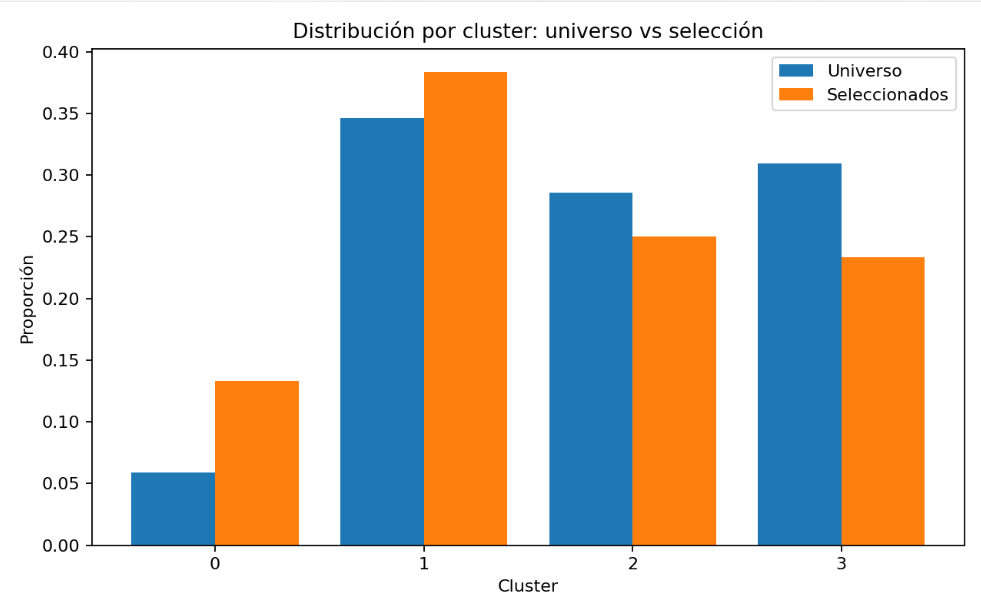

Esta gráfica compara la distribución de productos por clúster en el universo completo frente a la selección final. El objetivo es comprobar si la muestra reduce el sesgo que aparecía en la primera iteración y si mantiene una representación razonablemente equilibrada de los distintos grupos de comportamiento. El resultado muestra que la selección ya no está dominada por un único clúster y que, aunque sigue existiendo cierta diferencia respecto al universo original, la representación final es mucho más utilizable para el análisis. Esto supone una mejora importante, ya que permite incorporar comparativas por clúster en el dashboard sin que la lectura quede totalmente sesgada hacia el grupo mayoritario.

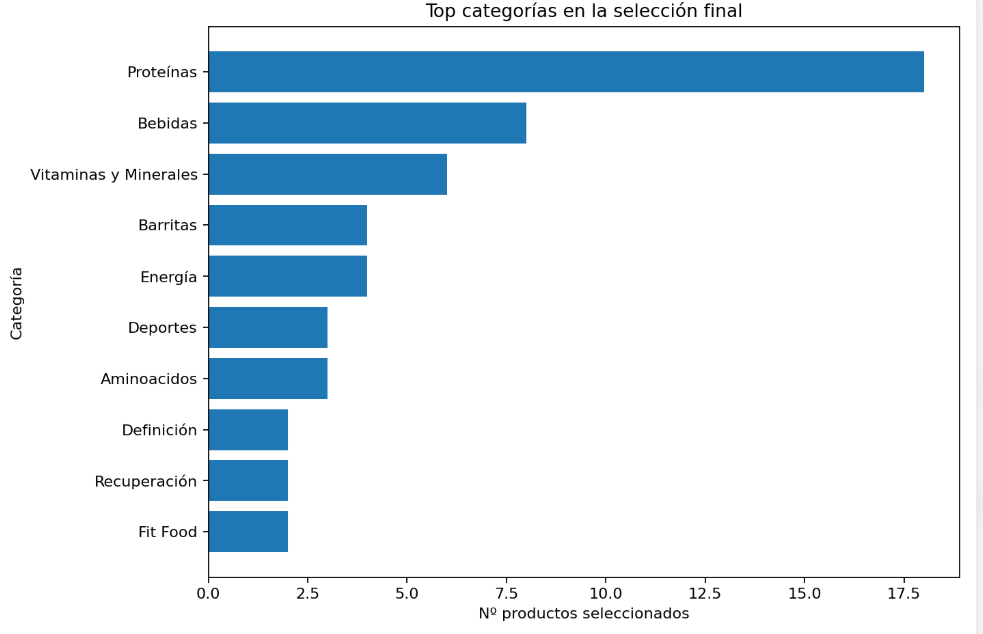

Esta gráfica muestra el número de productos seleccionados en las categorías con mayor presencia dentro de la muestra final. Sirve para validar si la selección conserva variedad suficiente sin volver a caer en una fragmentación excesiva. El resultado indica que la muestra sigue concentrando más peso en algunas categorías clave, como Proteínas, Bebidas o Vitaminas y Minerales, pero lo hace de forma mucho más controlada que en la primera iteración. Esto supone que el dashboard podrá incluir análisis por categoría con mayor profundidad, aunque también anticipa que convendrá vigilar que las categorías dominantes no monopolicen el relato visual.

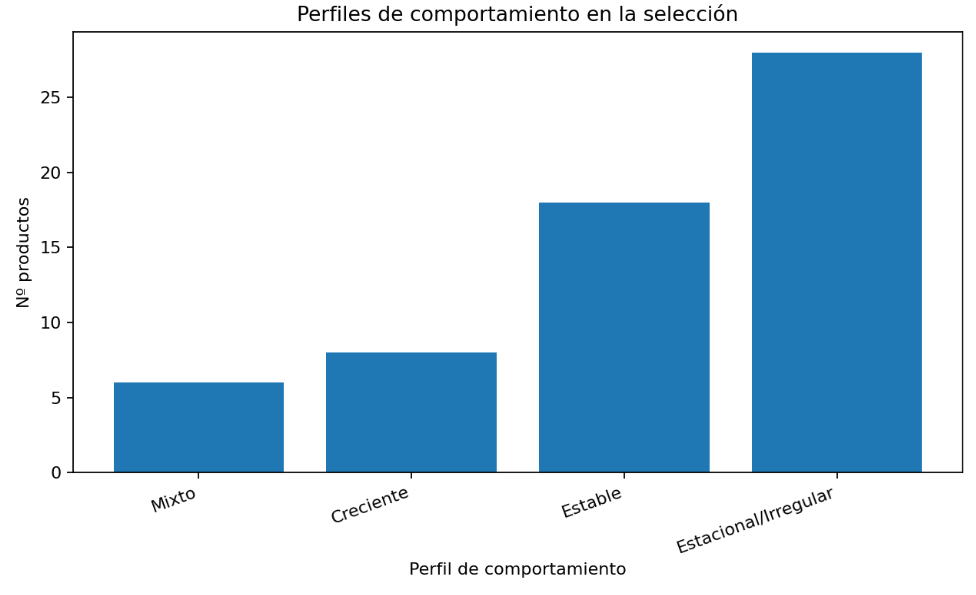

Esta gráfica resume la composición de la selección según el perfil de comportamiento asignado a cada producto: estable, creciente, estacional/irregular o mixto. Su función es comprobar si la muestra final contiene suficiente diversidad analítica para sostener distintos tipos de visuales y decisiones de negocio. El resultado confirma que la selección no se ha limitado a productos líderes o similares entre sí, sino que incorpora referencias con patrones temporales distintos. Esto es especialmente útil para el dashboard, porque permitirá mostrar tanto productos seguros o maduros como productos más volátiles, sensibles a campañas o con potencial de crecimiento.

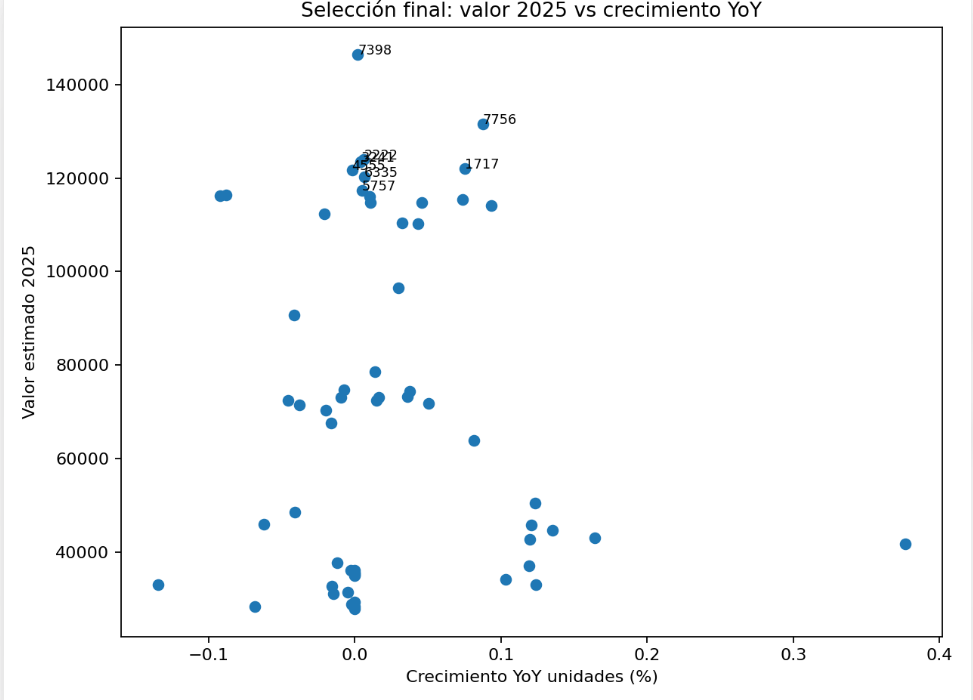

Esta gráfica representa cada producto seleccionado en función de dos ejes clave para el análisis de inversión: su valor estimado en 2025 y su crecimiento interanual en unidades. El objetivo es comprobar si la muestra contiene productos distribuidos en distintas zonas estratégicas y no únicamente concentrados en un mismo perfil. El resultado muestra una nube relativamente equilibrada, con productos de alto valor y crecimiento moderado, productos más maduros con evolución estable y algunos casos con mayor potencial de crecimiento. Esto supone que la muestra ya es válida para construir visuales orientados a decisiones como invertir, mantener o vigilar, aunque todavía queda margen para reforzar la presencia de productos claramente candidatos a revisión.

➡️ **Justificación de una tercera iteración de ajuste**

Aunque la segunda iteración ha mejorado claramente la calidad de la selección, todavía se identifican algunos aspectos susceptibles de mejora. 

En particular, **la muestra sigue estando muy orientada hacia productos con buen comportamiento relativo**, mientras que la representación de productos susceptibles de revisión o despriorización sigue siendo algo débil. Además, aunque la concentración por categoría ya se ha corregido respecto a la primera versión, **algunas categorías siguen teniendo un peso especialmente dominante**, lo que puede condicionar la lectura de ciertos visuales del dashboard.

Por este motivo se plantea una tercera iteración, no como un rediseño completo de la estrategia, sino como un **ajuste fino sobre una base que ya es válida**. 

🎯 **Objetivo**

El objetivo de esta tercera vuelta no es volver a rehacer toda la selección, sino mejorar dos puntos muy concretos:

-  En primer lugar, se pretende **introducir un pequeño bloque de productos con señales menos favorables** —por ejemplo, crecimiento nulo o negativo, menor atractivo de forecast o comportamiento más maduro— para reforzar la lógica de negocio del dashboard en la parte de “productos a revisar”. 
- En segundo lugar, se plantea aplicar un **límite más suave a la sobrerrepresentación de la categoría dominante**, con el fin de evitar que esta acabe condicionando en exceso los análisis por categoría.


🧩 **Importancia de esta tercera iteración.**

Esta tercera iteración tiene sentido porque el cuadro de mando no quiere responder solo a la pregunta de en qué productos conviene invertir, sino también a qué productos conviene mantener, vigilar o revisar. Para que ese enfoque sea realmente creíble, la muestra final debe recoger no solo casos de éxito o de oportunidad, sino también referencias que permitan ilustrar decisiones menos favorables dentro del catálogo. Del mismo modo, controlar ligeramente el peso de la categoría más dominante puede ayudar a construir un dashboard visualmente más equilibrado sin comprometer la coherencia general del negocio.

> La tercera iteración se plantea como una mejora incremental y estratégica: no busca maximizar la perfección estadística de la muestra, sino reforzar su utilidad práctica para el análisis final. Esto permitirá llegar a una selección más completa, mejor preparada para el storytelling del dashboard y más alineada con el enfoque de inversión en catálogo que se ha definido desde el inicio.


🪛 **Cambios técnicos introducidos**. 

La tercera iteración no supone un rediseño completo de la selección, sino un **ajuste fino** sobre la segunda versión, que ya había dado resultados válidos. El objetivo es reforzar dos aspectos concretos para mejorar la utilidad del dashboard.

1. **Inclusión de un pequeño bloque de productos "a revisar".**

Se añadirá un grupo reducido de productos con señales menos favorables, por ejemplo:
- crecimiento interanual negativo, 
- forecast menos atractivos, 
- comportamiento más maduro o estancado. 

El objetivo es incorporar al dashboard productos que no solo sirvan para identificar oportunidades de inversión, sino también casos donde convenga mantener, vigilar o revisar.

2. **Límite suave a la categoría dominante**.

Se aplicará una restricción ligera para evitar que la categoría con mayor presencia concentre demasiados productos dentro de la muestra final.

Con ello se pretende reducir el riesgo de que una sola categoría condicione en exceso los visuales y mejorar el equilibrio general del análisis por categoría. 

3. **Mantenimiento de la lógica principal de la segunda iteración**

No se modificarán los elementos estructurales que ya han mejorado la selección, como:

- el equilibrio por clúster, 
- la presencia de crecimiento, forecast, estabilidad y estacionalidad
- y la reducción de la dispersión excesiva por categoría. 

De este modo, se intenta conservar la base ya válidad de la segunda iteración y mejorar únicamente los puntos que seguían siendo mejorables. 



**Resultado esperado:**

Se espera obtener una selección final más completa desde el punto de vista de negocio, capaz de reflejar no solo productos fuertes o prometedores, sino también productos que ayuden a construir una lectura más realista del catálogo.

En consecuencia, la muestra final debería quedar mejor preparada para responder a tres tipos de decisión:

- productos en los que invertir,
- productos que conviene mantener o vigilar,
- y productos que merece la pena revisar o despriorizar.


In [ ]:
"""
===============================================================================
SCRIPT: 02_seleccionar_productos_dashboard.py
===============================================================================
DESCRIPCIÓN
-----------
Selecciona el subconjunto final de productos que se utilizará en el dashboard.

Esta versión aplica una estrategia de selección controlada para evitar:
- dispersión excesiva por categoría,
- sobrerrepresentación del clúster dominante,
- y falta de productos que apoyen la narrativa de inversión / mantenimiento /
  revisión del catálogo.

La selección combina:
1. Núcleo fuerte por valor 2025.
2. Productos con crecimiento YoY.
3. Productos con oportunidad forecast 2026.
4. Productos estables.
5. Productos estacionales / irregulares.
6. Productos a revisar.
7. Cobertura controlada de categorías top y proveedores top.
8. Cuotas mínimas y máximas por clúster.

Además, separa:
- motivo_principal: criterio por el que el producto entra por primera vez.
- criterios_cumplidos: conjunto de reglas que el producto satisface.

FLUJO DEL PIPELINE
------------------
1. Cargar ventas preparadas 2024-2025.
2. Cargar forecast preparado 2026.
3. Cargar catálogo enriquecido.
4. Construir métricas agregadas por producto.
5. Calcular cuotas objetivo por clúster.
6. Seleccionar productos por bloques con control de cuotas.
7. Completar hasta el tamaño objetivo.
8. Exportar productos seleccionados, métricas y trazabilidad.

INPUT ESPERADO
--------------
- data/interim/ventas_2024_2025_preparadas.parquet
- data/interim/forecast_2026_preparado.parquet
- data/raw/catalog_items_enriquecido.csv

OUTPUT ESPERADO
---------------
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv
- data/processed/trazabilidad_seleccion_productos.csv
- data/processed/resumen_seleccion_productos.csv

DEPENDENCIAS
------------
- pandas
- numpy
- pyarrow

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy pyarrow
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SALES_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
CATALOG_FILE = RAW_DIR / "catalog_items_enriquecido.csv"

OUT_SELECTED_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
OUT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"
OUT_TRACE_FILE = PROCESSED_DIR / "trazabilidad_seleccion_productos.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_seleccion_productos.csv"

# -------------------------------------------------------------------------
# PARÁMETROS DE SELECCIÓN
# -------------------------------------------------------------------------
TARGET_N_PRODUCTS = 60

CORE_PRODUCTS = 16
GROWTH_PRODUCTS = 8
FORECAST_PRODUCTS = 8
STABLE_PRODUCTS = 6
SEASONAL_PRODUCTS = 6
REVIEW_PRODUCTS = 6

TOP_CATEGORIES_ELIGIBLE = 15
TOP_CATEGORIES_COVERAGE = 12
TOP_PROVIDERS_COVERAGE = 6

MIN_PRODUCTS_PER_CLUSTER = 6
MAX_CLUSTER_SHARE = 0.50  # ningún clúster puede superar el 50% del total final

MIN_ACTIVE_WEEKS_STABLE = 40
MIN_ACTIVE_WEEKS_SEASONAL = 10

# Tope suave para la categoría dominante
DOMINANT_CATEGORY_CAP = 15

EPSILON = 1e-9


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import math
import sys
from typing import Dict, Optional, Set

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [SALES_FILE, FORECAST_FILE, CATALOG_FILE]
    missing = [str(path) for path in required_files if not path.exists()]

    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    """División segura evitando divisiones por cero."""
    den_adj = den.replace(0, np.nan)
    return num / den_adj


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def mode_non_null(series: pd.Series):
    """Devuelve la moda no nula de una serie, si existe."""
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    mode_values = s.mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]


# =============================================================================
# 3. CARGA Y PREPARACIÓN DE DATOS
# =============================================================================

def load_sales() -> pd.DataFrame:
    """Carga ventas preparadas 2024-2025."""
    logger.info("Cargando ventas preparadas...")
    df = pd.read_parquet(SALES_FILE)

    required_cols = {"product_id", "date", "sales_quantity", "precio_medio", "cluster_id"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en ventas: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_forecast() -> pd.DataFrame:
    """Carga forecast preparado 2026."""
    logger.info("Cargando forecast preparado...")
    df = pd.read_parquet(FORECAST_FILE)

    required_cols = {
        "product_id",
        "date",
        "forecast_base",
        "forecast_optimista",
        "forecast_pesimista",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en forecast: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    return df


def load_catalog() -> pd.DataFrame:
    """Carga catálogo enriquecido y renombra columnas relevantes."""
    logger.info("Cargando catálogo enriquecido...")
    df = pd.read_csv(CATALOG_FILE)

    rename_map = {
        "Product_ID": "product_id",
        "EAN13": "ean13",
        "Marca": "marca",
        "Proveedor": "proveedor",
        "Nombre": "nombre",
        "Categoria": "categoria",
        "Cluster": "cluster_catalogo",
        "precio_medio": "precio_medio_catalogo",
        "is_outlier": "is_outlier_catalogo",
    }

    available_rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=available_rename_map)

    if "product_id" not in df.columns:
        raise KeyError("El catálogo no contiene la columna Product_ID/product_id.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).copy()
    df = df.drop_duplicates(subset=["product_id"]).copy()

    return df


# =============================================================================
# 4. MÉTRICAS POR PRODUCTO
# =============================================================================

def build_product_metrics(
    sales: pd.DataFrame,
    forecast: pd.DataFrame,
    catalog: pd.DataFrame,
) -> pd.DataFrame:
    """Construye métricas agregadas por producto para la selección."""
    logger.info("Construyendo métricas agregadas por producto...")

    # ---------------------------------------------------------------------
    # 4.1. MÉTRICAS ANUALES DE VENTAS
    # ---------------------------------------------------------------------
    sales_yearly = (
        sales.groupby(["product_id", "year"], as_index=False)
        .agg(
            sales_units=("sales_quantity", "sum"),
            avg_price=("precio_medio", "mean"),
            cluster_mode=("cluster_id", mode_non_null),
        )
    )

    sales_pivot = (
        sales_yearly.pivot(index="product_id", columns="year", values="sales_units")
        .rename(columns={2024: "sales_units_2024", 2025: "sales_units_2025"})
        .reset_index()
    )

    price_2025 = (
        sales_yearly.loc[sales_yearly["year"] == 2025, ["product_id", "avg_price"]]
        .rename(columns={"avg_price": "avg_price_2025"})
    )

    cluster_sales = (
        sales_yearly.groupby("product_id", as_index=False)
        .agg(cluster_sales=("cluster_mode", mode_non_null))
    )

    product_metrics = sales_pivot.merge(price_2025, on="product_id", how="left")
    product_metrics = product_metrics.merge(cluster_sales, on="product_id", how="left")

    product_metrics["sales_units_2024"] = product_metrics["sales_units_2024"].fillna(0)
    product_metrics["sales_units_2025"] = product_metrics["sales_units_2025"].fillna(0)

    product_metrics["sales_value_2024_est"] = (
        product_metrics["sales_units_2024"] * product_metrics["avg_price_2025"]
    )
    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_2025"]
    )

    product_metrics["yoy_units_abs"] = (
        product_metrics["sales_units_2025"] - product_metrics["sales_units_2024"]
    )
    product_metrics["yoy_units_pct"] = safe_divide(
        product_metrics["yoy_units_abs"],
        product_metrics["sales_units_2024"],
    )

    product_metrics["yoy_value_abs_est"] = (
        product_metrics["sales_value_2025_est"] - product_metrics["sales_value_2024_est"]
    )
    product_metrics["yoy_value_pct_est"] = safe_divide(
        product_metrics["yoy_value_abs_est"],
        product_metrics["sales_value_2024_est"],
    )

    # ---------------------------------------------------------------------
    # 4.2. MÉTRICAS SEMANALES 2025: ESTABILIDAD / IRREGULARIDAD
    # ---------------------------------------------------------------------
    sales_2025 = sales.loc[sales["year"] == 2025].copy()
    sales_2025["week_start"] = sales_2025["date"].dt.to_period("W-MON").dt.start_time

    weekly_2025 = (
        sales_2025.groupby(["product_id", "week_start"], as_index=False)
        .agg(weekly_units=("sales_quantity", "sum"))
    )

    weekly_stats = (
        weekly_2025.groupby("product_id", as_index=False)
        .agg(
            weekly_mean_2025=("weekly_units", "mean"),
            weekly_std_2025=("weekly_units", "std"),
            weekly_max_2025=("weekly_units", "max"),
            active_weeks_2025=("weekly_units", lambda s: (s > 0).sum()),
        )
    )

    weekly_stats["weekly_std_2025"] = weekly_stats["weekly_std_2025"].fillna(0)
    weekly_stats["cv_2025"] = safe_divide(
        weekly_stats["weekly_std_2025"],
        weekly_stats["weekly_mean_2025"],
    )
    weekly_stats["peak_week_share_2025"] = safe_divide(
        weekly_stats["weekly_max_2025"],
        weekly_stats["weekly_mean_2025"] * weekly_stats["active_weeks_2025"],
    )

    product_metrics = product_metrics.merge(weekly_stats, on="product_id", how="left")

    # ---------------------------------------------------------------------
    # 4.3. MÉTRICAS DE FORECAST 2026
    # ---------------------------------------------------------------------
    forecast_2026 = (
        forecast.groupby("product_id", as_index=False)
        .agg(
            forecast_base_2026=("forecast_base", "sum"),
            forecast_optimista_2026=("forecast_optimista", "sum"),
            forecast_pesimista_2026=("forecast_pesimista", "sum"),
        )
    )

    product_metrics = product_metrics.merge(forecast_2026, on="product_id", how="left")

    product_metrics["forecast_base_vs_2025_abs"] = (
        product_metrics["forecast_base_2026"] - product_metrics["sales_units_2025"]
    )
    product_metrics["forecast_base_vs_2025_pct"] = safe_divide(
        product_metrics["forecast_base_vs_2025_abs"],
        product_metrics["sales_units_2025"],
    )

    # ---------------------------------------------------------------------
    # 4.4. ATRIBUTOS DE CATÁLOGO
    # ---------------------------------------------------------------------
    product_metrics = product_metrics.merge(catalog, on="product_id", how="left")

    if "cluster_catalogo" not in product_metrics.columns:
        product_metrics["cluster_catalogo"] = np.nan

    product_metrics["cluster_final"] = product_metrics["cluster_catalogo"].fillna(
        product_metrics["cluster_sales"]
    )
    product_metrics["cluster_final"] = product_metrics["cluster_final"].astype("string").fillna("Sin cluster")

    for col in ["categoria", "proveedor", "marca", "nombre"]:
        if col not in product_metrics.columns:
            product_metrics[col] = "Desconocido"
        product_metrics[col] = product_metrics[col].fillna("Desconocido")

    if "precio_medio_catalogo" in product_metrics.columns:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"].fillna(
            product_metrics["precio_medio_catalogo"]
        )
    else:
        product_metrics["avg_price_final"] = product_metrics["avg_price_2025"]

    product_metrics["sales_value_2025_est"] = (
        product_metrics["sales_units_2025"] * product_metrics["avg_price_final"]
    )

    # ---------------------------------------------------------------------
    # 4.5. FLAGS Y PERFILES
    # ---------------------------------------------------------------------
    product_metrics["has_sales_2025"] = product_metrics["sales_units_2025"] > 0
    product_metrics["has_sales_2024"] = product_metrics["sales_units_2024"] > 0
    product_metrics["has_forecast_2026"] = product_metrics["forecast_base_2026"].fillna(0) > 0

    product_metrics["perfil_comportamiento"] = "Mixto"

    stable_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (product_metrics["cv_2025"] <= product_metrics["cv_2025"].quantile(0.25))
    )

    seasonal_mask = (
        (product_metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (
            (product_metrics["peak_week_share_2025"] >= product_metrics["peak_week_share_2025"].quantile(0.75))
            | (product_metrics["cv_2025"] >= product_metrics["cv_2025"].quantile(0.75))
        )
    )

    growth_mask = product_metrics["yoy_units_pct"].fillna(-np.inf) > 0

    product_metrics.loc[stable_mask, "perfil_comportamiento"] = "Estable"
    product_metrics.loc[seasonal_mask, "perfil_comportamiento"] = "Estacional/Irregular"
    product_metrics.loc[growth_mask & ~stable_mask & ~seasonal_mask, "perfil_comportamiento"] = "Creciente"

    product_metrics = product_metrics.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    return product_metrics


# =============================================================================
# 5. CONTEXTO DE SELECCIÓN
# =============================================================================

def compute_top_categories(metrics: pd.DataFrame) -> list[str]:
    """Devuelve las categorías top por valor 2025."""
    cat_rank = (
        metrics.groupby("categoria", as_index=False)
        .agg(category_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("category_value_2025", ascending=False)
    )
    return cat_rank["categoria"].head(TOP_CATEGORIES_ELIGIBLE).tolist()


def compute_top_categories_for_coverage(metrics: pd.DataFrame) -> list[str]:
    """Devuelve las categorías top a cubrir explícitamente."""
    cat_rank = (
        metrics.groupby("categoria", as_index=False)
        .agg(category_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("category_value_2025", ascending=False)
    )
    return cat_rank["categoria"].head(TOP_CATEGORIES_COVERAGE).tolist()


def compute_top_providers_for_coverage(metrics: pd.DataFrame) -> list[str]:
    """Devuelve los proveedores top a cubrir explícitamente."""
    prov_rank = (
        metrics.groupby("proveedor", as_index=False)
        .agg(provider_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("provider_value_2025", ascending=False)
    )
    return prov_rank["proveedor"].head(TOP_PROVIDERS_COVERAGE).tolist()


def compute_category_caps(metrics: pd.DataFrame) -> dict[str, int]:
    """
    Define un límite suave para la categoría dominante por valor 2025.
    El resto de categorías no tendrá límite explícito.
    """
    category_rank = (
        metrics.groupby("categoria", as_index=False)
        .agg(category_value_2025=("sales_value_2025_est", "sum"))
        .sort_values("category_value_2025", ascending=False)
        .reset_index(drop=True)
    )

    dominant_category = category_rank.loc[0, "categoria"]
    caps = {dominant_category: DOMINANT_CATEGORY_CAP}

    logger.info(
        "Categoría dominante detectada: %s | límite suave aplicado: %s",
        dominant_category,
        DOMINANT_CATEGORY_CAP,
    )

    return caps


def compute_cluster_quotas(metrics: pd.DataFrame, target_n: int) -> dict[str, int]:
    """
    Calcula cuotas objetivo por clúster:
    - mínimo por clúster,
    - reparto adicional por peso económico,
    - máximo porcentaje del total por clúster.
    """
    cluster_stats = (
        metrics.groupby("cluster_final", as_index=False)
        .agg(
            cluster_value_2025=("sales_value_2025_est", "sum"),
            n_products=("product_id", "nunique"),
        )
        .sort_values("cluster_value_2025", ascending=False)
        .reset_index(drop=True)
    )

    clusters = cluster_stats["cluster_final"].tolist()
    max_cap = math.floor(target_n * MAX_CLUSTER_SHARE)

    quotas: Dict[str, int] = {}
    for _, row in cluster_stats.iterrows():
        cluster = row["cluster_final"]
        available = int(row["n_products"])
        quotas[cluster] = min(MIN_PRODUCTS_PER_CLUSTER, available)

    assigned = sum(quotas.values())
    remaining = max(0, target_n - assigned)

    cluster_stats["value_share"] = (
        cluster_stats["cluster_value_2025"] / max(cluster_stats["cluster_value_2025"].sum(), EPSILON)
    )

    capacities: Dict[str, int] = {}
    raw_extras: Dict[str, float] = {}

    for _, row in cluster_stats.iterrows():
        cluster = row["cluster_final"]
        available = int(row["n_products"])
        capacity = max(0, min(max_cap, available) - quotas[cluster])
        capacities[cluster] = capacity
        raw_extras[cluster] = row["value_share"] * remaining

    extra_alloc = {
        cluster: min(int(math.floor(raw_extras[cluster])), capacities[cluster])
        for cluster in clusters
    }

    assigned_extra = sum(extra_alloc.values())
    remaining_extra = remaining - assigned_extra

    fractions = sorted(
        [
            (cluster, raw_extras[cluster] - math.floor(raw_extras[cluster]))
            for cluster in clusters
        ],
        key=lambda x: x[1],
        reverse=True,
    )

    for cluster, _ in fractions:
        if remaining_extra <= 0:
            break
        if extra_alloc[cluster] < capacities[cluster]:
            extra_alloc[cluster] += 1
            remaining_extra -= 1

    if remaining_extra > 0:
        cluster_order = cluster_stats.sort_values(
            "cluster_value_2025",
            ascending=False
        )["cluster_final"].tolist()

        for cluster in cluster_order:
            while remaining_extra > 0 and extra_alloc[cluster] < capacities[cluster]:
                extra_alloc[cluster] += 1
                remaining_extra -= 1
            if remaining_extra <= 0:
                break

    for cluster in clusters:
        quotas[cluster] += extra_alloc[cluster]

    total_quotas = sum(quotas.values())
    if total_quotas > target_n:
        overflow = total_quotas - target_n
        cluster_order_desc = cluster_stats.sort_values(
            "cluster_value_2025",
            ascending=False
        )["cluster_final"].tolist()

        for cluster in cluster_order_desc:
            removable = max(0, quotas[cluster] - MIN_PRODUCTS_PER_CLUSTER)
            to_remove = min(removable, overflow)
            quotas[cluster] -= to_remove
            overflow -= to_remove
            if overflow <= 0:
                break

    logger.info("Cuotas objetivo por clúster: %s", quotas)
    return quotas


# =============================================================================
# 6. LÓGICA DE SELECCIÓN
# =============================================================================

def add_candidates(
    candidate_df: pd.DataFrame,
    selected_ids: Set[str],
    primary_reason_map: Dict[str, str],
    criteria_map: Dict[str, Set[str]],
    cluster_counts: Dict[str, int],
    cluster_quotas: Dict[str, int],
    category_counts: Dict[str, int],
    category_caps: Dict[str, int],
    reason: str,
    max_new: Optional[int] = None,
    allowed_categories: Optional[Set[str]] = None,
) -> int:
    """
    Añade candidatos preservando:
    - orden del DataFrame
    - no duplicidad
    - cuotas por clúster
    - tope suave por categoría dominante

    Además separa:
    - motivo_principal = regla por la que el producto entra por primera vez
    - criterios_cumplidos = conjunto de reglas que el producto satisface
    """
    added = 0

    for _, row in candidate_df.iterrows():
        product_id = row["product_id"]
        cluster = row["cluster_final"]
        category = row["categoria"]

        if allowed_categories is not None and category not in allowed_categories:
            continue

        criteria_map.setdefault(product_id, set()).add(reason)

        if product_id in selected_ids:
            continue

        current_cluster_count = cluster_counts.get(cluster, 0)
        cluster_quota = cluster_quotas.get(cluster, TARGET_N_PRODUCTS)
        if current_cluster_count >= cluster_quota:
            continue

        current_category_count = category_counts.get(category, 0)
        category_cap = category_caps.get(category, TARGET_N_PRODUCTS)
        if current_category_count >= category_cap:
            continue

        selected_ids.add(product_id)
        primary_reason_map[product_id] = reason

        cluster_counts[cluster] = current_cluster_count + 1
        category_counts[category] = current_category_count + 1
        added += 1

        if max_new is not None and added >= max_new:
            break

    return added


def select_products(product_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selección híbrida de productos para el dashboard.
    v3: incorpora bloque de productos a revisar y control suave de categoría dominante.
    """
    logger.info("Iniciando selección híbrida de productos (v3)...")

    metrics = product_metrics.copy()

    top_categories_eligible = set(compute_top_categories(metrics))
    top_categories_coverage = compute_top_categories_for_coverage(metrics)
    top_providers_coverage = compute_top_providers_for_coverage(metrics)
    cluster_quotas = compute_cluster_quotas(metrics, TARGET_N_PRODUCTS)
    category_caps = compute_category_caps(metrics)

    value_q30 = metrics["sales_value_2025_est"].quantile(0.30)
    value_q40 = metrics["sales_value_2025_est"].quantile(0.40)
    value_q50 = metrics["sales_value_2025_est"].quantile(0.50)
    value_q90 = metrics["sales_value_2025_est"].quantile(0.90)

    selected_ids: Set[str] = set()
    primary_reason_map: Dict[str, str] = {}
    criteria_map: Dict[str, Set[str]] = {}
    cluster_counts: Dict[str, int] = {cluster: 0 for cluster in cluster_quotas.keys()}
    category_counts: Dict[str, int] = {}

    # ---------------------------------------------------------------------
    # 6.1. CORE POR VALOR 2025
    # ---------------------------------------------------------------------
    core_candidates = metrics.loc[metrics["sales_value_2025_est"] > 0].copy()
    core_candidates = core_candidates.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    )

    add_candidates(
        core_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Core valor 2025",
        max_new=CORE_PRODUCTS,
        allowed_categories=None,
    )

    # ---------------------------------------------------------------------
    # 6.2. CRECIMIENTO YoY
    # ---------------------------------------------------------------------
    growth_candidates = metrics.loc[
        (metrics["sales_units_2024"] > 0)
        & (metrics["sales_units_2025"] > 0)
        & (metrics["yoy_units_pct"].fillna(-np.inf) > 0.10)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (metrics["sales_value_2025_est"] <= value_q90)
    ].copy()

    growth_candidates = growth_candidates.sort_values(
        ["yoy_units_pct", "sales_value_2025_est"],
        ascending=[False, False],
    )

    add_candidates(
        growth_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Crecimiento YoY",
        max_new=GROWTH_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.3. OPORTUNIDAD FORECAST 2026
    # ---------------------------------------------------------------------
    forecast_candidates = metrics.loc[
        (metrics["sales_units_2025"] > 0)
        & (metrics["forecast_base_2026"] > 0)
        & (metrics["forecast_base_vs_2025_pct"].fillna(-np.inf) > 0.05)
        & (metrics["sales_value_2025_est"] >= value_q30)
    ].copy()

    forecast_candidates = forecast_candidates.sort_values(
        ["forecast_base_vs_2025_pct", "forecast_base_2026", "sales_value_2025_est"],
        ascending=[False, False, False],
    )

    add_candidates(
        forecast_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Oportunidad forecast 2026",
        max_new=FORECAST_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.4. ESTABILIDAD
    # ---------------------------------------------------------------------
    stable_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_STABLE)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (metrics["cv_2025"].notna())
    ].copy()

    stable_candidates = stable_candidates.sort_values(
        ["cv_2025", "sales_value_2025_est"],
        ascending=[True, False],
    )

    add_candidates(
        stable_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Producto estable",
        max_new=STABLE_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.5. ESTACIONAL / IRREGULAR
    # ---------------------------------------------------------------------
    seasonal_candidates = metrics.loc[
        (metrics["active_weeks_2025"] >= MIN_ACTIVE_WEEKS_SEASONAL)
        & (metrics["sales_value_2025_est"] >= value_q30)
        & (
            (metrics["peak_week_share_2025"] >= metrics["peak_week_share_2025"].quantile(0.75))
            | (metrics["cv_2025"] >= metrics["cv_2025"].quantile(0.75))
        )
    ].copy()

    seasonal_candidates = seasonal_candidates.sort_values(
        ["peak_week_share_2025", "cv_2025", "sales_value_2025_est"],
        ascending=[False, False, False],
    )

    add_candidates(
        seasonal_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Producto estacional/irregular",
        max_new=SEASONAL_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.6. PRODUCTOS A REVISAR
    # ---------------------------------------------------------------------
    review_candidates = metrics.loc[
        (metrics["sales_units_2025"] > 0)
        & (metrics["sales_value_2025_est"] >= value_q40)
        & (
            (metrics["yoy_units_pct"].fillna(np.inf) <= 0)
            | (metrics["forecast_base_vs_2025_pct"].fillna(np.inf) <= 0.02)
        )
    ].copy()

    review_candidates = review_candidates.sort_values(
        ["sales_value_2025_est", "yoy_units_pct", "forecast_base_vs_2025_pct"],
        ascending=[False, True, True],
    )

    add_candidates(
        review_candidates,
        selected_ids,
        primary_reason_map,
        criteria_map,
        cluster_counts,
        cluster_quotas,
        category_counts,
        category_caps,
        reason="Producto a revisar",
        max_new=REVIEW_PRODUCTS,
        allowed_categories=top_categories_eligible,
    )

    # ---------------------------------------------------------------------
    # 6.7. COBERTURA DE CATEGORÍAS TOP
    # ---------------------------------------------------------------------
    selected_categories = set(
        metrics.loc[metrics["product_id"].isin(selected_ids), "categoria"].dropna().unique().tolist()
    )

    for category in top_categories_coverage:
        if category in selected_categories:
            continue

        category_candidates = metrics.loc[metrics["categoria"] == category].copy()
        category_candidates = category_candidates.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        added = add_candidates(
            category_candidates,
            selected_ids,
            primary_reason_map,
            criteria_map,
            cluster_counts,
            cluster_quotas,
            category_counts,
            category_caps,
            reason="Cobertura categoría top",
            max_new=1,
            allowed_categories=None,
        )

        if added > 0:
            selected_categories.add(category)

    # ---------------------------------------------------------------------
    # 6.8. COBERTURA DE PROVEEDORES TOP
    # ---------------------------------------------------------------------
    selected_providers = set(
        metrics.loc[metrics["product_id"].isin(selected_ids), "proveedor"].dropna().unique().tolist()
    )

    for provider in top_providers_coverage:
        if provider in selected_providers:
            continue

        provider_candidates = metrics.loc[metrics["proveedor"] == provider].copy()
        provider_candidates = provider_candidates.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        added = add_candidates(
            provider_candidates,
            selected_ids,
            primary_reason_map,
            criteria_map,
            cluster_counts,
            cluster_quotas,
            category_counts,
            category_caps,
            reason="Cobertura proveedor top",
            max_new=1,
            allowed_categories=top_categories_eligible,
        )

        if added > 0:
            selected_providers.add(provider)

    # ---------------------------------------------------------------------
    # 6.9. RELLENO PRINCIPAL
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        filler_candidates = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        add_candidates(
            filler_candidates,
            selected_ids,
            primary_reason_map,
            criteria_map,
            cluster_counts,
            cluster_quotas,
            category_counts,
            category_caps,
            reason="Relleno por valor controlado",
            max_new=TARGET_N_PRODUCTS - len(selected_ids),
            allowed_categories=top_categories_eligible,
        )

    # ---------------------------------------------------------------------
    # 6.10. RELLENO SECUNDARIO
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        filler_all = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        add_candidates(
            filler_all,
            selected_ids,
            primary_reason_map,
            criteria_map,
            cluster_counts,
            cluster_quotas,
            category_counts,
            category_caps,
            reason="Relleno por valor ampliado",
            max_new=TARGET_N_PRODUCTS - len(selected_ids),
            allowed_categories=None,
        )

    # ---------------------------------------------------------------------
    # 6.11. RELLENO FINAL RELAJADO
    # ---------------------------------------------------------------------
    if len(selected_ids) < TARGET_N_PRODUCTS:
        logger.warning(
            "No se alcanzó el objetivo con restricciones estrictas. "
            "Se aplica relleno final relajado."
        )

        filler_relaxed = metrics.sort_values(
            ["sales_value_2025_est", "sales_units_2025"],
            ascending=[False, False],
        )

        for _, row in filler_relaxed.iterrows():
            product_id = row["product_id"]
            cluster = row["cluster_final"]
            category = row["categoria"]

            criteria_map.setdefault(product_id, set()).add("Relleno final relajado")

            if product_id in selected_ids:
                continue

            selected_ids.add(product_id)
            primary_reason_map[product_id] = "Relleno final relajado"

            cluster_counts[cluster] = cluster_counts.get(cluster, 0) + 1
            category_counts[category] = category_counts.get(category, 0) + 1

            if len(selected_ids) >= TARGET_N_PRODUCTS:
                break

    # ---------------------------------------------------------------------
    # 6.12. DATAFRAMES FINALES
    # ---------------------------------------------------------------------
    selected_df = metrics.loc[metrics["product_id"].isin(selected_ids)].copy()

    selected_df["motivo_principal"] = selected_df["product_id"].map(
        lambda pid: primary_reason_map.get(pid, "No informado")
    )

    selected_df["criterios_cumplidos"] = selected_df["product_id"].map(
        lambda pid: "; ".join(sorted(criteria_map.get(pid, set())))
    )

    selected_df = selected_df.sort_values(
        ["sales_value_2025_est", "sales_units_2025"],
        ascending=[False, False],
    ).reset_index(drop=True)

    if len(selected_df) > TARGET_N_PRODUCTS:
        selected_df = selected_df.head(TARGET_N_PRODUCTS).copy()

    trace_df = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2024",
            "sales_units_2025",
            "sales_value_2025_est",
            "yoy_units_pct",
            "forecast_base_2026",
            "forecast_base_vs_2025_pct",
            "cv_2025",
            "peak_week_share_2025",
            "perfil_comportamiento",
            "motivo_principal",
            "criterios_cumplidos",
        ]
    ].copy()

    return selected_df, trace_df


# =============================================================================
# 7. VALIDACIONES DE SALIDA
# =============================================================================

def validate_selection(selected_df: pd.DataFrame, metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Valida la selección final y genera un resumen ejecutivo."""
    logger.info("Validando selección final...")

    if selected_df["product_id"].duplicated().any():
        raise ValueError("La selección final contiene Product_ID duplicados.")

    if len(selected_df) > TARGET_N_PRODUCTS:
        raise ValueError(
            f"La selección final supera el objetivo: {len(selected_df)} > {TARGET_N_PRODUCTS}"
        )

    cluster_dist = (
        selected_df.groupby("cluster_final", as_index=False)
        .agg(n_productos=("product_id", "nunique"))
        .sort_values("n_productos", ascending=False)
    )

    category_dist = (
        selected_df.groupby("categoria", as_index=False)
        .agg(n_productos=("product_id", "nunique"))
        .sort_values("n_productos", ascending=False)
    )

    cluster_dist_str = "; ".join(
        [f"{row['cluster_final']}={row['n_productos']}" for _, row in cluster_dist.iterrows()]
    )

    category_dist_str = "; ".join(
        [f"{row['categoria']}={row['n_productos']}" for _, row in category_dist.head(5).iterrows()]
    )

    summary = {
        "n_productos_seleccionados": int(len(selected_df)),
        "n_productos_objetivo": int(TARGET_N_PRODUCTS),
        "n_categorias_seleccionadas": int(selected_df["categoria"].nunique(dropna=True)),
        "n_clusters_seleccionados": int(selected_df["cluster_final"].nunique(dropna=True)),
        "n_proveedores_seleccionados": int(selected_df["proveedor"].nunique(dropna=True)),
        "ventas_2025_unidades_total_seleccion": float(selected_df["sales_units_2025"].sum()),
        "ventas_2025_valor_total_est_seleccion": float(selected_df["sales_value_2025_est"].sum()),
        "forecast_2026_base_total_seleccion": float(selected_df["forecast_base_2026"].sum()),
        "peso_valor_2025_seleccion_sobre_universo": float(
            selected_df["sales_value_2025_est"].sum()
            / max(metrics_df["sales_value_2025_est"].sum(), EPSILON)
        ),
        "distribucion_clusters": cluster_dist_str,
        "top_categorias_seleccion": category_dist_str,
    }

    return pd.DataFrame([summary])


# =============================================================================
# 8. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(
    selected_df: pd.DataFrame,
    metrics_df: pd.DataFrame,
    trace_df: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> None:
    """Exporta los resultados del script."""
    logger.info("Exportando resultados de selección...")

    selected_export = selected_df[
        [
            "product_id",
            "nombre",
            "marca",
            "proveedor",
            "categoria",
            "cluster_final",
            "sales_units_2025",
            "sales_value_2025_est",
            "forecast_base_2026",
            "motivo_principal",
            "criterios_cumplidos",
        ]
    ].copy()

    export_dataframe(selected_export, OUT_SELECTED_FILE)
    export_dataframe(metrics_df, OUT_METRICS_FILE)
    export_dataframe(trace_df, OUT_TRACE_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_SELECTED_FILE.name)
    logger.info("Archivo exportado: %s", OUT_METRICS_FILE.name)
    logger.info("Archivo exportado: %s", OUT_TRACE_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 9. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de selección de productos."""
    logger.info("==== INICIO | Selección de productos para dashboard (v3) ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    sales = load_sales()
    forecast = load_forecast()
    catalog = load_catalog()

    metrics_df = build_product_metrics(
        sales=sales,
        forecast=forecast,
        catalog=catalog,
    )

    selected_df, trace_df = select_products(metrics_df)
    summary_df = validate_selection(selected_df, metrics_df)

    export_outputs(
        selected_df=selected_df,
        metrics_df=metrics_df,
        trace_df=trace_df,
        summary_df=summary_df,
    )

    logger.info(
        "Selección final completada | productos=%s | categorías=%s | clústeres=%s | proveedores=%s",
        len(selected_df),
        selected_df["categoria"].nunique(dropna=True),
        selected_df["cluster_final"].nunique(dropna=True),
        selected_df["proveedor"].nunique(dropna=True),
    )

    logger.info("==== FIN | Selección de productos completada ====")


if __name__ == "__main__":
    main()

🔎 **Resultados obtenidos tras la tercera iteración**

La tercera iteración no ha supuesto un cambio estructural del proceso de selección, sino un ajuste fino sobre la segunda versión, que ya ofrecía una base válida. El objetivo principal de esta tercera vuelta era mejorar la trazabilidad de la selección y reforzar ligeramente el equilibrio analítico del conjunto final, sin alterar la lógica general que ya había dado buenos resultados.

El cambio más importante ha sido la separación entre motivo principal de entrada y criterios cumplidos. Esto permite identificar con claridad por qué entra cada producto por primera vez en la muestra, evitando la confusión que generaba la versión anterior, en la que la columna de motivos mezclaba la causa de entrada con el resto de condiciones que también satisfacía el producto. Gracias a este ajuste, la selección final es ahora mucho más interpretable y defendible metodológicamente.

A nivel de composición, la muestra final sigue manteniendo los 60 productos objetivo, con una estructura equilibrada por clúster y una distribución por categorías bastante más controlada que en la primera versión. Además, la incorporación de un pequeño bloque de productos a revisar refuerza el enfoque de negocio del dashboard, ya que permite representar no solo productos en los que conviene invertir o mantener, sino también referencias cuya evolución justifica una revisión estratégica dentro del catálogo.

En conjunto, la tercera iteración puede considerarse la versión definitiva de la selección, ya que conserva lo mejor de la segunda vuelta —equilibrio, variedad y utilidad analítica— y mejora la trazabilidad de los criterios aplicados.

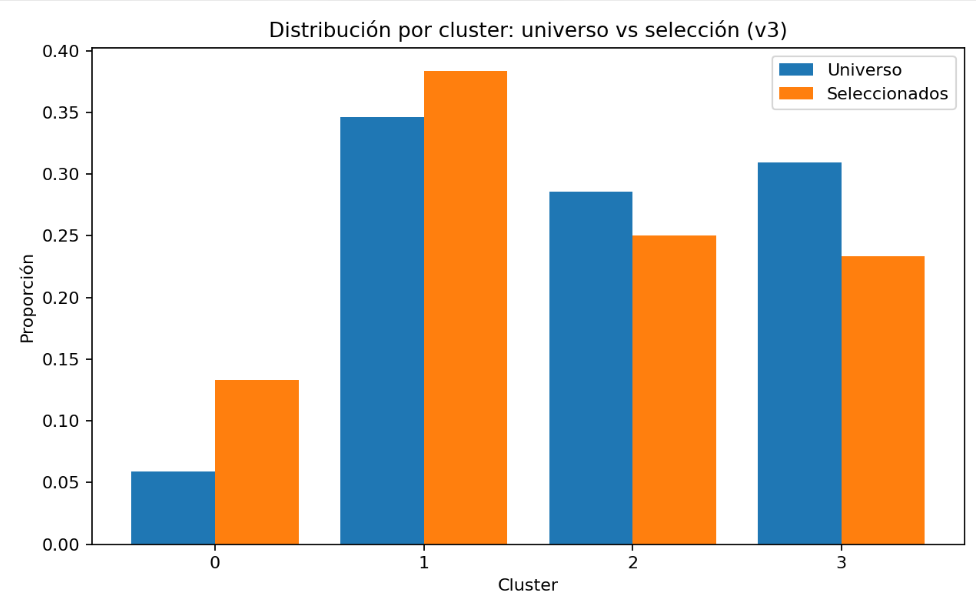



La gráfica compara el peso relativo de cada clúster en el universo completo frente a la muestra final seleccionada. El resultado confirma que la selección mantiene una representación razonablemente equilibrada de los cuatro clústeres, evitando la sobrerrepresentación extrema que aparecía en la primera versión. Esto supone que el análisis por clúster será utilizable en el dashboard sin quedar condicionado por un único grupo dominante.

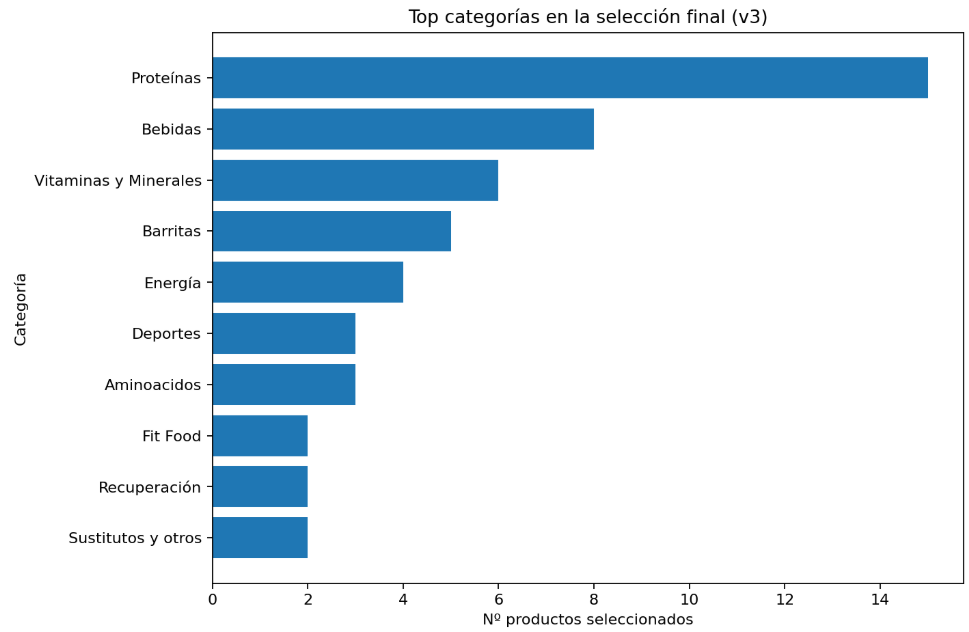

Esta gráfica muestra qué categorías concentran mayor número de productos dentro de la muestra final. Se observa que algunas categorías siguen teniendo más peso —especialmente Proteínas—, pero dentro de un rango más controlado que en versiones anteriores. Esto implica que el dashboard podrá analizar categorías relevantes con mayor profundidad, aunque convendrá cuidar el diseño visual para que la categoría dominante no monopolice el relato.

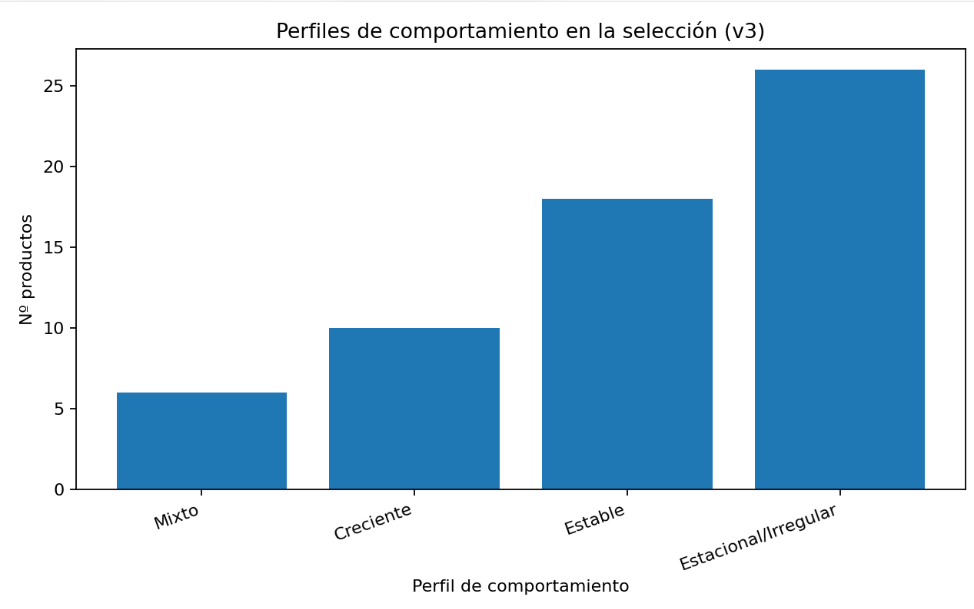

La gráfica resume el número de productos clasificados como estables, crecientes, estacionales/irregulares o mixtos. El resultado confirma que la selección final contiene variedad suficiente de comportamientos, lo que refuerza el valor analítico del dashboard. Esto permitirá comparar productos maduros, productos de crecimiento y productos más sensibles a campañas o picos de demanda.

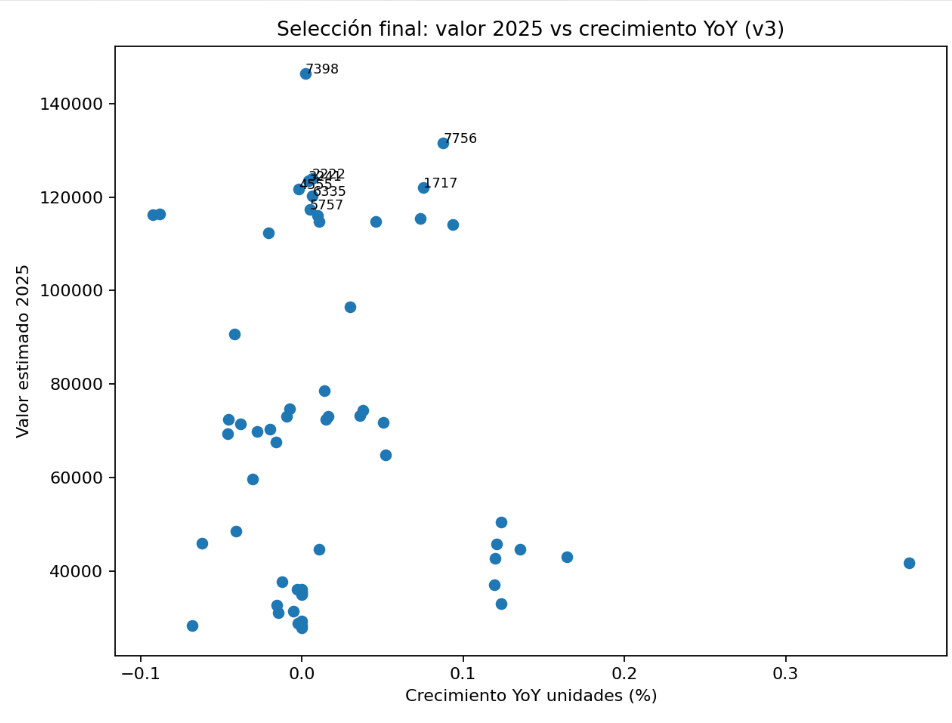

Esta gráfica sitúa cada producto según su valor estimado en 2025 y su crecimiento interanual. La nube resultante muestra una combinación razonable de productos con peso económico, productos con crecimiento positivo y productos más maduros o planos. Esto supone que la muestra ya es apta para construir visuales orientados a decisiones de inversión, mantenimiento o revisión dentro del catálogo.

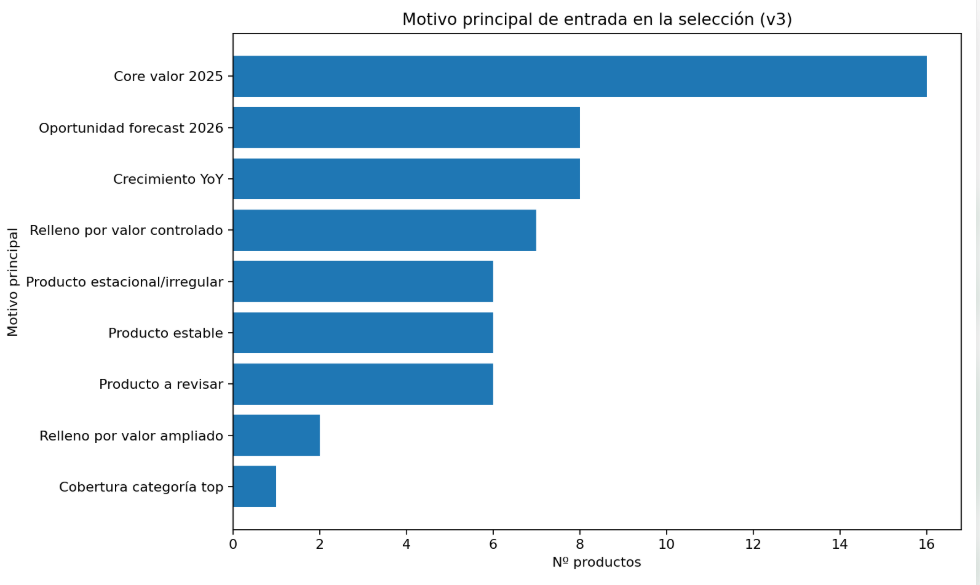

Esta gráfica muestra el criterio principal por el que cada producto entra por primera vez en la muestra final. Su utilidad es metodológica: permite comprobar que la selección no ha quedado dominada por un único bloque, sino que responde a una lógica híbrida donde conviven productos elegidos por valor, crecimiento, forecast, estabilidad, estacionalidad o revisión. Esto refuerza la trazabilidad del proceso y mejora la calidad explicativa del notebook.

⏭️ **Siguiente paso: fact table final.**

Una vez obtenido el subconjunto definitivo de productos, el siguiente paso consistirá en:

- construir la fact table final usando únicamente esas referencias,
- agregar la información a la granularidad semanal definida,
- incorporar los escenarios de previsión,
- y filtrar la dimensión producto para que quede alineada con el universo seleccionado.

De este modo, el modelo estrella se construirá ya sobre una base reducida, coherente y preparada para el desarrollo del cuadro de mando.

 ## 📅 **3. Fact base semanal.**

En este paso se ha construido la fact base semanal a partir de las fuentes ya preparadas y del subconjunto final de 60 productos seleccionados. El objetivo no era todavía cerrar el modelo estrella completo, sino generar una tabla de hechos base con una estructura ya compatible con BI: una fila por producto y semana, y únicamente con claves temporales, identificador de producto y métricas numéricas.

🎯 **Objetivo**

La finalidad de esta tabla es servir como base del análisis temporal del dashboard, permitiendo combinar:

- ventas reales de 2024 y 2025,
- previsión de 2026,
- precio unitario de referencia,
- métricas derivadas de valor estimado.

Todo ello bajo una granularidad semanal, que fue la elegida previamente por ser el mejor equilibrio entre detalle temporal, volumen de datos y utilidad analítica.

🛠️ **Transformaciones aplicadas**

1. **Filtrado al subconjunto final de productos.**

En primer lugar, tanto el histórico de ventas como la previsión se filtraron para conservar únicamente los 60 productos seleccionados en la fase anterior. Esto garantiza que la fact base y las futuras dimensiones trabajen exactamente sobre el mismo universo.


2. **Agregación semanal.**

Las observaciones diarias se agregaron a nivel de semana para construir una tabla con el siguiente grano:

1 fila = 1 producto + 1 semana

Esta agregación se aplicó tanto a las ventas reales como al forecast.


3. **Uso de semanas de negocio**

Inicialmente, al agregar por semanas naturales, apareció un problema en las semanas frontera entre años. Por ejemplo:

- una semana que comenzaba en diciembre de 2024 podía contener días de enero de 2025
- una semana que comenzaba en diciembre de 2025 podía contener días de enero de 2026

Esto generaba inconsistencias temporales: algunas filas quedaban ancladas visualmente a un año, pero contenían información que pertenecía analíticamente al siguiente.

Para resolverlo, se redefinieron las semanas como semanas de negocio recortadas al año natural, de modo que:

- la primera semana del año puede ser parcial,
- la última semana del año también puede ser parcial,
- y ninguna semana mezcla días de años distintos.

Esta decisión hace que el modelo sea mucho más limpio para comparativas anuales y para el cálculo posterior de KPIs como YoY o YTD.

4. **Incorporación del precio de referencia**

A la fact se añadió un precio unitario de referencia por producto, recuperado desde la tabla de métricas agregadas por producto. Este precio no se incorpora como atributo descriptivo, sino como métrica auxiliar para estimar:

- valor de ventas,
- valor de forecast base,
- valor de forecast optimista,
- valor de forecast pesimista.

5. **Cálculo de métricas derivadas**

A partir de las unidades y del precio de referencia, se generaron métricas adicionales como:

- sales_value_estimated
- forecast_base_value_estimated
- forecast_optimista_value_estimated
- forecast_pesimista_value_estimated

Esto deja preparada la fact para análisis económicos sin necesidad de esperar todavía a una modelización completa de costes o margen.

🔍 **Validaciones aplicadas**

En esta fase se han realizado sobre todo validaciones estructurales y de consistencia temporal, que eran imprescindibles antes de construir las dimensiones. 

Las validaciones realizadas son:

- se comprobó que la fact solo contuviera los 60 productos seleccionados,
- se validó que no existieran duplicados para la clave: product_id + year_label + week_start_date
- se comprobó que las semanas no mezclaran años distintos
- se verificó que:
    - en 2024 y 2025 solo hubiera ventas reales
    - en 2026 solo hubiera forecast
- se revisó que el precio de referencia no presentara nulos ni ceros problemáticos
- se validó que el número de semanas resultante fuera coherente con la lógica de semanas de negocio recortadas

📋 **Resultados obtenidos**

La fact base final presenta los siguientes resultados:

- 9.540 filas
- 60 productos
- 159 semanas únicas
- 0 duplicados
- 0 inconsistencias entre year_label y el año de week_start_date

Además, la cobertura temporal queda ya bien separada:

- 2024 → ventas reales
- 2025 → ventas reales
- 2026 → forecast

Y las métricas económicas derivadas han quedado ya calculadas sobre la propia fact.

**Interpretación del número de semanas**

El hecho de que aparezcan 53 semanas por año no se considera un error, sino una consecuencia natural de la lógica adoptada. Al recortar las semanas en los límites del año, es posible que:

- la primera semana del año no tenga 7 días completos,
- la última semana tampoco,
- aun así ambas cuenten como semanas distintas dentro del año.

Esto es coherente con la estrategia elegida y, de hecho, evita problemas mucho más graves de mezcla temporal entre ejercicios.

✅ **Valoración de la validez de esta fase**

La fact base construida puede considerarse válida a nivel técnico y estructural. En este punto ya tenemos una tabla semanal coherente, sin duplicados, con separación temporal correcta entre años y con métricas suficientemente limpias como para avanzar hacia el modelo estrella.

En otras palabras, esta fase puede darse por cerrada desde el punto de vista de construcción de la tabla de hechos base.

In [ ]:
"""
===============================================================================
SCRIPT: 03_construir_fact_base_semanal.py
===============================================================================
DESCRIPCIÓN
-----------
Construye la fact base semanal del dashboard a partir del subconjunto final de
productos seleccionado.

La tabla resultante tendrá como granularidad:

    1 fila = 1 producto + 1 semana de negocio

En esta fase se construye una fact base orientada al modelo estrella, dejando
únicamente:
- claves de dimensión (producto + semana)
- métricas de ventas y forecast
- precio de referencia y valores estimados derivados

IMPORTANTE
----------
Para evitar que una misma semana mezcle datos de años distintos, las semanas se
recortan en los límites anuales:
- la primera semana del año puede ser parcial
- la última semana del año puede ser parcial

Así se evita que:
- ventas de 2025 aparezcan en semanas ancladas a 2024
- forecast 2026 aparezca visualmente en 2025

FLUJO DEL PIPELINE
------------------
1. Cargar ventas preparadas 2024-2025.
2. Cargar forecast preparado 2026.
3. Cargar productos seleccionados.
4. Cargar métricas por producto para recuperar el precio de referencia.
5. Filtrar solo el subconjunto final de productos.
6. Construir semanas de negocio dentro de cada año.
7. Agregar ventas reales a semana.
8. Agregar forecast a semana.
9. Unir ambas capas en una sola fact base.
10. Calcular métricas derivadas de valor estimado.
11. Exportar la fact semanal y un resumen de validación.

INPUT ESPERADO
--------------
- data/interim/ventas_2024_2025_preparadas.parquet
- data/interim/forecast_2026_preparado.parquet
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv

OUTPUT ESPERADO
---------------
- data/processed/fact_base_semanal.csv
- data/processed/resumen_fact_base_semanal.csv

DEPENDENCIAS
------------
- pandas
- numpy
- pyarrow

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy pyarrow

NOTAS
-----
- Esta tabla es una fact base intermedia ya con forma adecuada para BI.
- Las dimensiones descriptivas (producto, proveedor, categoría, etc.) NO se
  incluyen aquí como atributos de negocio; se construirán aparte.
- El precio se conserva como métrica de referencia para poder estimar valor
  de ventas y forecast.
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SALES_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
SELECTED_PRODUCTS_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
PRODUCT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"

OUT_FACT_FILE = PROCESSED_DIR / "fact_base_semanal.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_fact_base_semanal.csv"

EPSILON = 1e-9


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [
        SALES_FILE,
        FORECAST_FILE,
        SELECTED_PRODUCTS_FILE,
        PRODUCT_METRICS_FILE,
    ]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def get_week_start_monday(date_series: pd.Series) -> pd.Series:
    """Devuelve el lunes de la semana natural."""
    date_series = pd.to_datetime(date_series)
    return date_series - pd.to_timedelta(date_series.dt.weekday, unit="D")


def get_week_end_sunday(date_series: pd.Series) -> pd.Series:
    """Devuelve el domingo de la semana natural."""
    return get_week_start_monday(date_series) + pd.Timedelta(days=6)


def build_business_week_fields(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """
    Construye campos de semana de negocio recortados al año natural.

    Ejemplo:
    - Si una semana empieza el 2024-12-30 y contiene días de 2025,
      las fechas de 2024 quedarán en una semana 2024-12-30 a 2024-12-31
      y las de 2025 quedarán en una semana 2025-01-01 a 2025-01-05.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    natural_week_start = get_week_start_monday(out[date_col])
    natural_week_end = get_week_end_sunday(out[date_col])

    year_label = out[date_col].dt.year
    year_start = pd.to_datetime(year_label.astype(str) + "-01-01")
    year_end = pd.to_datetime(year_label.astype(str) + "-12-31")

    business_week_start = natural_week_start.where(natural_week_start >= year_start, year_start)
    business_week_end = natural_week_end.where(natural_week_end <= year_end, year_end)

    out["year_label"] = year_label
    out["week_start_date"] = business_week_start
    out["week_end_date"] = business_week_end

    return out


def add_business_week_number(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade número de semana de negocio dentro de cada año.
    """
    out = df.copy()

    week_index = (
        out[["year_label", "week_start_date"]]
        .drop_duplicates()
        .sort_values(["year_label", "week_start_date"])
        .copy()
    )

    week_index["week_number_business"] = (
        week_index.groupby("year_label").cumcount() + 1
    )

    out = out.merge(
        week_index,
        on=["year_label", "week_start_date"],
        how="left",
        validate="many_to_one",
    )

    out["year_week_key"] = (
        out["year_label"].astype(int).astype(str)
        + "_W"
        + out["week_number_business"].astype(int).astype(str).str.zfill(2)
    )

    out["week_label"] = (
        out["week_start_date"].dt.strftime("%d/%m/%Y")
        + " - "
        + out["week_end_date"].dt.strftime("%d/%m/%Y")
    )

    return out


# =============================================================================
# 3. CARGA DE DATOS
# =============================================================================

def load_selected_products() -> pd.DataFrame:
    """Carga el subconjunto final de productos seleccionados."""
    logger.info("Cargando productos seleccionados...")
    df = pd.read_csv(SELECTED_PRODUCTS_FILE)

    if "product_id" not in df.columns:
        raise KeyError("El archivo de productos seleccionados no contiene 'product_id'.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).drop_duplicates(subset=["product_id"]).copy()

    return df


def load_product_metrics() -> pd.DataFrame:
    """
    Carga las métricas por producto para recuperar el precio de referencia final.
    """
    logger.info("Cargando métricas de producto...")
    df = pd.read_csv(PRODUCT_METRICS_FILE)

    required_cols = {"product_id", "avg_price_final"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en métricas de producto: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["avg_price_final"] = pd.to_numeric(df["avg_price_final"], errors="coerce")

    df = df[["product_id", "avg_price_final"]].drop_duplicates(subset=["product_id"]).copy()
    return df


def load_sales() -> pd.DataFrame:
    """Carga ventas preparadas 2024-2025."""
    logger.info("Cargando ventas preparadas...")
    df = pd.read_parquet(SALES_FILE)

    required_cols = {"product_id", "date", "sales_quantity"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en ventas: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["sales_quantity"] = pd.to_numeric(df["sales_quantity"], errors="coerce").fillna(0)

    return df


def load_forecast() -> pd.DataFrame:
    """Carga forecast preparado 2026."""
    logger.info("Cargando forecast preparado...")
    df = pd.read_parquet(FORECAST_FILE)

    required_cols = {
        "product_id",
        "date",
        "forecast_base",
        "forecast_optimista",
        "forecast_pesimista",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en forecast: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])

    for col in ["forecast_base", "forecast_optimista", "forecast_pesimista"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    return df


# =============================================================================
# 4. LÓGICA PRINCIPAL
# =============================================================================

def build_sales_weekly(sales: pd.DataFrame, selected_ids: set[str]) -> pd.DataFrame:
    """
    Agrega las ventas reales a nivel semanal de negocio.
    """
    logger.info("Agregando ventas reales a semana de negocio...")

    df = sales.loc[sales["product_id"].isin(selected_ids)].copy()
    df = build_business_week_fields(df, date_col="date")

    weekly = (
        df.groupby(
            ["product_id", "year_label", "week_start_date", "week_end_date"],
            as_index=False,
        )
        .agg(
            sales_units=("sales_quantity", "sum"),
        )
    )

    weekly = add_business_week_number(weekly)
    return weekly


def build_forecast_weekly(forecast: pd.DataFrame, selected_ids: set[str]) -> pd.DataFrame:
    """
    Agrega el forecast 2026 a nivel semanal de negocio.
    """
    logger.info("Agregando forecast a semana de negocio...")

    df = forecast.loc[forecast["product_id"].isin(selected_ids)].copy()
    df = build_business_week_fields(df, date_col="date")

    weekly = (
        df.groupby(
            ["product_id", "year_label", "week_start_date", "week_end_date"],
            as_index=False,
        )
        .agg(
            forecast_base_units=("forecast_base", "sum"),
            forecast_optimista_units=("forecast_optimista", "sum"),
            forecast_pesimista_units=("forecast_pesimista", "sum"),
        )
    )

    weekly = add_business_week_number(weekly)
    return weekly


def build_fact_base(
    sales_weekly: pd.DataFrame,
    forecast_weekly: pd.DataFrame,
    product_metrics: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye la fact base semanal uniendo ventas, forecast y precio de referencia.
    """
    logger.info("Construyendo fact base semanal...")

    merge_keys = [
        "product_id",
        "year_label",
        "week_start_date",
        "week_end_date",
        "week_number_business",
        "year_week_key",
        "week_label",
    ]

    fact = sales_weekly.merge(
        forecast_weekly,
        on=merge_keys,
        how="outer",
        validate="one_to_one",
    )

    metric_cols = [
        "sales_units",
        "forecast_base_units",
        "forecast_optimista_units",
        "forecast_pesimista_units",
    ]
    for col in metric_cols:
        if col not in fact.columns:
            fact[col] = 0
        fact[col] = pd.to_numeric(fact[col], errors="coerce").fillna(0)

    fact = fact.merge(
        product_metrics,
        on="product_id",
        how="left",
        validate="many_to_one",
    )

    fact = fact.rename(columns={"avg_price_final": "price_unit_reference"})
    fact["price_unit_reference"] = pd.to_numeric(
        fact["price_unit_reference"], errors="coerce"
    ).fillna(0)

    fact["sales_value_estimated"] = fact["sales_units"] * fact["price_unit_reference"]
    fact["forecast_base_value_estimated"] = (
        fact["forecast_base_units"] * fact["price_unit_reference"]
    )
    fact["forecast_optimista_value_estimated"] = (
        fact["forecast_optimista_units"] * fact["price_unit_reference"]
    )
    fact["forecast_pesimista_value_estimated"] = (
        fact["forecast_pesimista_units"] * fact["price_unit_reference"]
    )

    fact["week_start_date"] = pd.to_datetime(fact["week_start_date"])
    fact["week_end_date"] = pd.to_datetime(fact["week_end_date"])

    fact["week_key"] = (
        fact["year_label"].astype(int).astype(str)
        + fact["week_number_business"].astype(int).astype(str).str.zfill(2)
    )

    fact = fact.sort_values(["product_id", "year_label", "week_start_date"]).reset_index(drop=True)

    dup_count = fact.duplicated(
        subset=["product_id", "year_label", "week_start_date"]
    ).sum()
    if dup_count > 0:
        raise ValueError(
            f"Se han detectado {dup_count} duplicados en la fact para la clave "
            f"['product_id', 'year_label', 'week_start_date']."
        )

    return fact


def build_summary(fact: pd.DataFrame) -> pd.DataFrame:
    """Construye un resumen simple de validación de la fact base."""
    cross_year_issue = int((fact["week_start_date"].dt.year != fact["year_label"]).sum())

    summary = {
        "n_filas_fact": int(len(fact)),
        "n_productos_fact": int(fact["product_id"].nunique(dropna=True)),
        "fecha_min_fact": fact["week_start_date"].min(),
        "fecha_max_fact": fact["week_end_date"].max(),
        "sales_units_total": float(fact["sales_units"].sum()),
        "forecast_base_units_total": float(fact["forecast_base_units"].sum()),
        "forecast_optimista_units_total": float(fact["forecast_optimista_units"].sum()),
        "forecast_pesimista_units_total": float(fact["forecast_pesimista_units"].sum()),
        "sales_value_estimated_total": float(fact["sales_value_estimated"].sum()),
        "forecast_base_value_estimated_total": float(fact["forecast_base_value_estimated"].sum()),
        "n_semanas_unicas": int(fact[["year_label", "week_start_date"]].drop_duplicates().shape[0]),
        "filas_con_year_label_distinto_de_week_start_year": cross_year_issue,
    }

    return pd.DataFrame([summary])


# =============================================================================
# 5. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(fact: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Exporta la fact base y su resumen."""
    logger.info("Exportando fact base semanal...")

    export_dataframe(fact, OUT_FACT_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_FACT_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 6. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de construcción de la fact base semanal."""
    logger.info("==== INICIO | Construcción de fact base semanal ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    selected_products = load_selected_products()
    product_metrics = load_product_metrics()
    sales = load_sales()
    forecast = load_forecast()

    selected_ids = set(selected_products["product_id"].dropna().unique())

    sales_weekly = build_sales_weekly(sales, selected_ids)
    forecast_weekly = build_forecast_weekly(forecast, selected_ids)

    fact = build_fact_base(
        sales_weekly=sales_weekly,
        forecast_weekly=forecast_weekly,
        product_metrics=product_metrics,
    )

    summary_df = build_summary(fact)
    export_outputs(fact, summary_df)

    logger.info(
        "Fact base construida | filas=%s | productos=%s | semanas=%s",
        len(fact),
        fact["product_id"].nunique(),
        fact[["year_label", "week_start_date"]].drop_duplicates().shape[0],
    )

    logger.info("==== FIN | Construcción de fact base semanal ====")


if __name__ == "__main__":
    main()

La representación semanal de 2024 y 2025 se generó con el objetivo de validar visualmente la fact base una vez agregada a semana. No se trataba solo de comprobar que la tabla estuviera bien construida técnicamente, sino de verificar que los datos seguían produciendo una serie temporal coherente, útil para el análisis de estacionalidad, picos de demanda y comparación entre ejercicios. Esta gráfica permitió además detectar el efecto de las semanas parciales al inicio y final del año, lo que llevó a plantear una corrección metodológica para evitar distorsiones en la lectura visual.

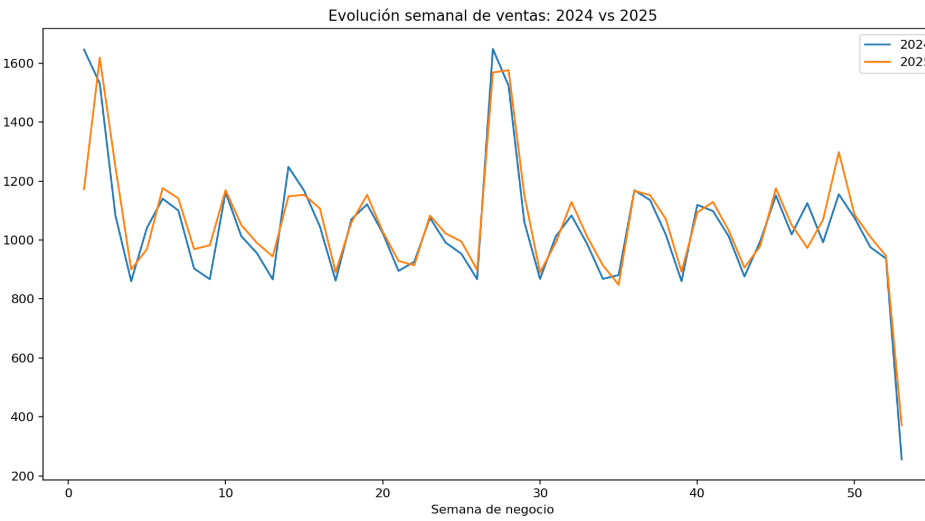

📊 **Interpretación del gráfico semanal 2024–2025**

Al representar la evolución semanal agregada de las ventas de 2024 y 2025, se observa una caída muy pronunciada en la última semana de cada año. A primera vista, esta bajada podría interpretarse como una pérdida brusca de ventas, pero en realidad no responde a un cambio real del negocio, sino a un efecto metodológico derivado de la construcción de la fact semanal.

La causa es que, para evitar mezclar días de ejercicios distintos en una misma semana, se decidió trabajar con semanas de negocio recortadas al año natural. Esto implica que la primera y la última semana de cada año pueden quedar incompletas, es decir, con menos de 7 días. En consecuencia, cuando se comparan directamente las ventas semanales brutas, esas semanas parciales aparecen artificialmente más bajas, no porque se haya vendido menos en términos comparables, sino porque contienen menos días.

Por tanto, el gráfico sí es útil para comprobar que la serie tiene una forma general coherente y que existen patrones estacionales y picos semanales, pero también pone de manifiesto que las semanas parciales distorsionan la comparación visual en los extremos del año.

🧾 **Solución**

Para corregir este efecto sin perder la representatividad real del dato, se ha optado por mantener las métricas semanales brutas y, además, crear una versión ajustada únicamente para las semanas parciales.

La lógica será la siguiente:

- las semanas completas se conservarán sin cambios;
- las semanas parciales se reescalarán proporcionalmente al equivalente de una semana completa;
- se añadirá información auxiliar para identificar cuántos días tiene cada semana y si se trata o no de una semana parcial.

De este modo, la fact seguirá teniendo una granularidad: 

1 fila = 1 producto + 1 semana

pero incorporará también métricas comparables para los gráficos donde las semanas parciales puedan introducir ruido visual.

**Consecuencias de esta decisión**

Esta solución implica que a partir de ahora coexistirán **dos lecturas distintas del dato semanal**:

**1. Métrica semanal real**

Representa el volumen realmente observado o previsto en cada semana tal como ha quedado definida en la fact.

Uso recomendado:

- KPIs de volumen
- acumulados
- tablas de detalle
- análisis operativo real

**2. Métrica semanal ajustada**

Reescala únicamente las semanas parciales para que puedan compararse visualmente con semanas completas.

Uso recomendado:

- comparativas entre 2024 y 2025 
- análisis de estacionalidad
- gráficos de líneas semanales
- visuales donde se quiera comparar forma temporal sin sesgo por número de días

Esto no cambia la granularidad de la fact, ni modifica el dato real almacenado como métrica principal. Simplemente añade una capa de ajuste para aquellos casos en los que la comparación visual pueda quedar distorsionada.

📐 **Por qué esta solución es correcta**

La solución adoptada se considera la más adecuada por varios motivos.

1. **Mantiene la fidelidad del dato real.**

No se eliminan semanas ni se sustituyen las ventas reales por versiones transformadas. La métrica bruta sigue existiendo y puede seguir utilizándose cuando interese reflejar exactamente lo ocurrido.

2. **Corrige solo donde realmente hay un problema.**

La distorsión no afecta a todas las semanas del año, sino únicamente a las semanas parciales de frontera. Por ello, ajustar solo esos casos es más riguroso que normalizar todas las semanas o eliminar información.

3. **Mejora la comparabilidad visual**.

Al corregir únicamente las semanas incompletas, los gráficos temporales dejan de mostrar caídas artificiales al principio o al final del año y permiten comparar mejor la forma real de la serie.

4. **Es metodológicamente defendible.**

Desde el punto de vista del modelado, esta opción equilibra bien:
- rigor técnico, 
- utilidad analítica, 
- y claridad visual. 

No rompe la lógica semanal elegida para la fact y, al mismo tiempo, evita que una decisión correcta de modelado genere interpretaciones erróneas en los visuales.

> La caída observada en el gráfico semanal no se interpreta como una anomalía del negocio, sino como un efecto esperado de las semanas parciales de cierre de año. Para evitar que este fenómeno distorsione la lectura del dashboard, se mantendrán las métricas semanales reales y se incorporará una versión ajustada únicamente para las semanas incompletas. Esta solución permite conservar la fidelidad del dato y, al mismo tiempo, mejorar la comparabilidad temporal en los gráficos de evolución y estacionalidad.

In [ ]:
"""
===============================================================================
SCRIPT: 03_construir_fact_base_semanal.py
===============================================================================
DESCRIPCIÓN
-----------
Construye la fact base semanal del dashboard a partir del subconjunto final de
productos seleccionado.

Granularidad:
    1 fila = 1 producto + 1 semana de negocio

La tabla resultante incluye:
- claves de dimensión (producto + semana)
- métricas reales de ventas y forecast
- precio de referencia
- métricas derivadas de valor estimado
- métricas ajustadas para semanas parciales, pensadas para comparativas visuales

IMPORTANTE
----------
Para evitar que una misma semana mezcle datos de años distintos, las semanas se
recortan en los límites anuales:
- la primera semana del año puede ser parcial
- la última semana del año puede ser parcial

Además:
- se conserva la métrica real semanal
- y se crea una métrica ajustada únicamente para comparaciones visuales entre
  semanas parciales y completas

INPUT ESPERADO
--------------
- data/interim/ventas_2024_2025_preparadas.parquet
- data/interim/forecast_2026_preparado.parquet
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv

OUTPUT ESPERADO
---------------
- data/processed/fact_base_semanal.csv
- data/processed/resumen_fact_base_semanal.csv

DEPENDENCIAS
------------
- pandas
- numpy
- pyarrow

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy pyarrow
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SALES_FILE = INTERIM_DIR / "ventas_2024_2025_preparadas.parquet"
FORECAST_FILE = INTERIM_DIR / "forecast_2026_preparado.parquet"
SELECTED_PRODUCTS_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
PRODUCT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"

OUT_FACT_FILE = PROCESSED_DIR / "fact_base_semanal.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_fact_base_semanal.csv"

EPSILON = 1e-9


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [
        SALES_FILE,
        FORECAST_FILE,
        SELECTED_PRODUCTS_FILE,
        PRODUCT_METRICS_FILE,
    ]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def get_week_start_monday(date_series: pd.Series) -> pd.Series:
    """Devuelve el lunes de la semana natural."""
    date_series = pd.to_datetime(date_series)
    return date_series - pd.to_timedelta(date_series.dt.weekday, unit="D")


def get_week_end_sunday(date_series: pd.Series) -> pd.Series:
    """Devuelve el domingo de la semana natural."""
    return get_week_start_monday(date_series) + pd.Timedelta(days=6)


def build_business_week_fields(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """
    Construye campos de semana de negocio recortados al año natural.
    """
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    natural_week_start = get_week_start_monday(out[date_col])
    natural_week_end = get_week_end_sunday(out[date_col])

    year_label = out[date_col].dt.year
    year_start = pd.to_datetime(year_label.astype(str) + "-01-01")
    year_end = pd.to_datetime(year_label.astype(str) + "-12-31")

    business_week_start = natural_week_start.where(natural_week_start >= year_start, year_start)
    business_week_end = natural_week_end.where(natural_week_end <= year_end, year_end)

    out["year_label"] = year_label
    out["week_start_date"] = business_week_start
    out["week_end_date"] = business_week_end

    return out


def add_business_week_number(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade número de semana de negocio dentro de cada año.
    """
    out = df.copy()

    week_index = (
        out[["year_label", "week_start_date"]]
        .drop_duplicates()
        .sort_values(["year_label", "week_start_date"])
        .copy()
    )

    week_index["week_number_business"] = (
        week_index.groupby("year_label").cumcount() + 1
    )

    out = out.merge(
        week_index,
        on=["year_label", "week_start_date"],
        how="left",
        validate="many_to_one",
    )

    out["year_week_key"] = (
        out["year_label"].astype(int).astype(str)
        + "_W"
        + out["week_number_business"].astype(int).astype(str).str.zfill(2)
    )

    out["week_label"] = (
        out["week_start_date"].dt.strftime("%d/%m/%Y")
        + " - "
        + out["week_end_date"].dt.strftime("%d/%m/%Y")
    )

    return out


def add_partial_week_fields(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade:
    - n_days_week
    - is_partial_week

    La semana parcial se define como una semana con menos de 7 días.
    """
    out = df.copy()
    out["n_days_week"] = (
        (pd.to_datetime(out["week_end_date"]) - pd.to_datetime(out["week_start_date"])).dt.days + 1
    )
    out["is_partial_week"] = out["n_days_week"] < 7
    return out


def add_adjusted_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea métricas ajustadas para comparar semanas parciales con semanas completas.

    Regla:
    - si la semana tiene 7 días, el valor ajustado coincide con el real
    - si la semana tiene menos de 7 días, se reescala a equivalente semanal
    """
    out = df.copy()

    out["sales_units_adjusted"] = out["sales_units"] * 7 / out["n_days_week"]
    out["forecast_base_units_adjusted"] = out["forecast_base_units"] * 7 / out["n_days_week"]
    out["forecast_optimista_units_adjusted"] = out["forecast_optimista_units"] * 7 / out["n_days_week"]
    out["forecast_pesimista_units_adjusted"] = out["forecast_pesimista_units"] * 7 / out["n_days_week"]

    out["sales_value_estimated_adjusted"] = (
        out["sales_units_adjusted"] * out["price_unit_reference"]
    )
    out["forecast_base_value_estimated_adjusted"] = (
        out["forecast_base_units_adjusted"] * out["price_unit_reference"]
    )
    out["forecast_optimista_value_estimated_adjusted"] = (
        out["forecast_optimista_units_adjusted"] * out["price_unit_reference"]
    )
    out["forecast_pesimista_value_estimated_adjusted"] = (
        out["forecast_pesimista_units_adjusted"] * out["price_unit_reference"]
    )

    return out


# =============================================================================
# 3. CARGA DE DATOS
# =============================================================================

def load_selected_products() -> pd.DataFrame:
    """Carga el subconjunto final de productos seleccionados."""
    logger.info("Cargando productos seleccionados...")
    df = pd.read_csv(SELECTED_PRODUCTS_FILE)

    if "product_id" not in df.columns:
        raise KeyError("El archivo de productos seleccionados no contiene 'product_id'.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).drop_duplicates(subset=["product_id"]).copy()

    return df


def load_product_metrics() -> pd.DataFrame:
    """
    Carga las métricas por producto para recuperar el precio de referencia final.
    """
    logger.info("Cargando métricas de producto...")
    df = pd.read_csv(PRODUCT_METRICS_FILE)

    required_cols = {"product_id", "avg_price_final"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en métricas de producto: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["avg_price_final"] = pd.to_numeric(df["avg_price_final"], errors="coerce")

    df = df[["product_id", "avg_price_final"]].drop_duplicates(subset=["product_id"]).copy()
    return df


def load_sales() -> pd.DataFrame:
    """Carga ventas preparadas 2024-2025."""
    logger.info("Cargando ventas preparadas...")
    df = pd.read_parquet(SALES_FILE)

    required_cols = {"product_id", "date", "sales_quantity"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en ventas: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])
    df["sales_quantity"] = pd.to_numeric(df["sales_quantity"], errors="coerce").fillna(0)

    return df


def load_forecast() -> pd.DataFrame:
    """Carga forecast preparado 2026."""
    logger.info("Cargando forecast preparado...")
    df = pd.read_parquet(FORECAST_FILE)

    required_cols = {
        "product_id",
        "date",
        "forecast_base",
        "forecast_optimista",
        "forecast_pesimista",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas en forecast: {missing}")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df["date"] = pd.to_datetime(df["date"])

    for col in ["forecast_base", "forecast_optimista", "forecast_pesimista"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    return df


# =============================================================================
# 4. LÓGICA PRINCIPAL
# =============================================================================

def build_sales_weekly(sales: pd.DataFrame, selected_ids: set[str]) -> pd.DataFrame:
    """
    Agrega las ventas reales a nivel semanal de negocio.
    """
    logger.info("Agregando ventas reales a semana de negocio...")

    df = sales.loc[sales["product_id"].isin(selected_ids)].copy()
    df = build_business_week_fields(df, date_col="date")

    weekly = (
        df.groupby(
            ["product_id", "year_label", "week_start_date", "week_end_date"],
            as_index=False,
        )
        .agg(
            sales_units=("sales_quantity", "sum"),
        )
    )

    weekly = add_business_week_number(weekly)
    weekly = add_partial_week_fields(weekly)
    return weekly


def build_forecast_weekly(forecast: pd.DataFrame, selected_ids: set[str]) -> pd.DataFrame:
    """
    Agrega el forecast 2026 a nivel semanal de negocio.
    """
    logger.info("Agregando forecast a semana de negocio...")

    df = forecast.loc[forecast["product_id"].isin(selected_ids)].copy()
    df = build_business_week_fields(df, date_col="date")

    weekly = (
        df.groupby(
            ["product_id", "year_label", "week_start_date", "week_end_date"],
            as_index=False,
        )
        .agg(
            forecast_base_units=("forecast_base", "sum"),
            forecast_optimista_units=("forecast_optimista", "sum"),
            forecast_pesimista_units=("forecast_pesimista", "sum"),
        )
    )

    weekly = add_business_week_number(weekly)
    weekly = add_partial_week_fields(weekly)
    return weekly


def build_fact_base(
    sales_weekly: pd.DataFrame,
    forecast_weekly: pd.DataFrame,
    product_metrics: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye la fact base semanal uniendo ventas, forecast y precio de referencia.
    """
    logger.info("Construyendo fact base semanal...")

    merge_keys = [
        "product_id",
        "year_label",
        "week_start_date",
        "week_end_date",
        "week_number_business",
        "year_week_key",
        "week_label",
        "n_days_week",
        "is_partial_week",
    ]

    fact = sales_weekly.merge(
        forecast_weekly,
        on=merge_keys,
        how="outer",
        validate="one_to_one",
    )

    metric_cols = [
        "sales_units",
        "forecast_base_units",
        "forecast_optimista_units",
        "forecast_pesimista_units",
    ]
    for col in metric_cols:
        if col not in fact.columns:
            fact[col] = 0
        fact[col] = pd.to_numeric(fact[col], errors="coerce").fillna(0)

    fact = fact.merge(
        product_metrics,
        on="product_id",
        how="left",
        validate="many_to_one",
    )

    fact = fact.rename(columns={"avg_price_final": "price_unit_reference"})
    fact["price_unit_reference"] = pd.to_numeric(
        fact["price_unit_reference"], errors="coerce"
    ).fillna(0)

    # Métricas brutas
    fact["sales_value_estimated"] = fact["sales_units"] * fact["price_unit_reference"]
    fact["forecast_base_value_estimated"] = (
        fact["forecast_base_units"] * fact["price_unit_reference"]
    )
    fact["forecast_optimista_value_estimated"] = (
        fact["forecast_optimista_units"] * fact["price_unit_reference"]
    )
    fact["forecast_pesimista_value_estimated"] = (
        fact["forecast_pesimista_units"] * fact["price_unit_reference"]
    )

    # Métricas ajustadas para semanas parciales
    fact = add_adjusted_metrics(fact)

    fact["week_start_date"] = pd.to_datetime(fact["week_start_date"])
    fact["week_end_date"] = pd.to_datetime(fact["week_end_date"])

    fact["week_key"] = (
        fact["year_label"].astype(int).astype(str)
        + fact["week_number_business"].astype(int).astype(str).str.zfill(2)
    )

    fact = fact.sort_values(["product_id", "year_label", "week_start_date"]).reset_index(drop=True)

    dup_count = fact.duplicated(
        subset=["product_id", "year_label", "week_start_date"]
    ).sum()
    if dup_count > 0:
        raise ValueError(
            f"Se han detectado {dup_count} duplicados en la fact para la clave "
            f"['product_id', 'year_label', 'week_start_date']."
        )

    return fact


def build_summary(fact: pd.DataFrame) -> pd.DataFrame:
    """Construye un resumen simple de validación de la fact base."""
    cross_year_issue = int((fact["week_start_date"].dt.year != fact["year_label"]).sum())
    partial_weeks = int(fact["is_partial_week"].sum())

    summary = {
        "n_filas_fact": int(len(fact)),
        "n_productos_fact": int(fact["product_id"].nunique(dropna=True)),
        "fecha_min_fact": fact["week_start_date"].min(),
        "fecha_max_fact": fact["week_end_date"].max(),
        "sales_units_total": float(fact["sales_units"].sum()),
        "forecast_base_units_total": float(fact["forecast_base_units"].sum()),
        "forecast_optimista_units_total": float(fact["forecast_optimista_units"].sum()),
        "forecast_pesimista_units_total": float(fact["forecast_pesimista_units"].sum()),
        "sales_value_estimated_total": float(fact["sales_value_estimated"].sum()),
        "forecast_base_value_estimated_total": float(fact["forecast_base_value_estimated"].sum()),
        "n_semanas_unicas": int(fact[["year_label", "week_start_date"]].drop_duplicates().shape[0]),
        "filas_con_year_label_distinto_de_week_start_year": cross_year_issue,
        "filas_semanas_parciales": partial_weeks,
    }

    return pd.DataFrame([summary])


# =============================================================================
# 5. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(fact: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Exporta la fact base y su resumen."""
    logger.info("Exportando fact base semanal...")

    export_dataframe(fact, OUT_FACT_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_FACT_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 6. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el flujo completo de construcción de la fact base semanal."""
    logger.info("==== INICIO | Construcción de fact base semanal ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    selected_products = load_selected_products()
    product_metrics = load_product_metrics()
    sales = load_sales()
    forecast = load_forecast()

    selected_ids = set(selected_products["product_id"].dropna().unique())

    sales_weekly = build_sales_weekly(sales, selected_ids)
    forecast_weekly = build_forecast_weekly(forecast, selected_ids)

    fact = build_fact_base(
        sales_weekly=sales_weekly,
        forecast_weekly=forecast_weekly,
        product_metrics=product_metrics,
    )

    summary_df = build_summary(fact)
    export_outputs(fact, summary_df)

    logger.info(
        "Fact base construida | filas=%s | productos=%s | semanas=%s | semanas parciales=%s",
        len(fact),
        fact["product_id"].nunique(),
        fact[["year_label", "week_start_date"]].drop_duplicates().shape[0],
        int(fact["is_partial_week"].sum()),
    )

    logger.info("==== FIN | Construcción de fact base semanal ====")


if __name__ == "__main__":
    main()

📋 **Resultados obtenidos tras el nuevo ajuste**

La fact base semanal final quedó compuesta por 9.540 filas, correspondientes a 60 productos y 159 semanas únicas, sin duplicados en la clave product_id + year_label + week_start_date. La cobertura temporal quedó correctamente separada entre ventas reales de 2024 y 2025 y forecast de 2026, sin mezcla de métricas entre ejercicios. Además, la corrección aplicada sobre las semanas frontera eliminó las inconsistencias detectadas inicialmente entre el año analítico y la fecha de inicio de semana.



🔍 **Validación de las semanas parciales**

Se identificaron 5 semanas parciales reales en los límites de los ejercicios, lo que equivale a 300 filas al considerar los 60 productos seleccionados. Estas semanas quedaron correctamente marcadas mediante las variables n_days_week e is_partial_week. A partir de ellas se generaron métricas ajustadas únicamente para comparativas visuales, manteniendo intactas las métricas reales para el análisis de negocio. Esto permite conservar la representatividad del dato semanal y, al mismo tiempo, evitar caídas artificiales en los gráficos comparativos.

✅ **Valoración de la fase**

La fact base puede considerarse validada a nivel estructural, temporal y analítico. En este punto ya se dispone de una tabla de hechos coherente, con granularidad semanal correcta, separación limpia entre años y métricas suficientes para construir el modelo estrella del dashboard. La validación de negocio global continuará en las siguientes fases, al integrar las dimensiones y revisar el comportamiento del modelo en los visuales finales.


## 📅 **4. Construcción de la dimensión calendario semanal.**

🎯 **Objetivo**

Una vez validada la fact base semanal, el siguiente paso consiste en construir la dimensión calendario definitiva del dashboard, adaptada a la granularidad semanal de la tabla de hechos.

En una primera aproximación se valoró generar una dimensión calendario diaria, una dimensión semanal y una tabla puente entre semana y fecha. Esta opción era técnicamente válida, pero se descartó para el modelo final porque añadía una complejidad innecesaria respecto al uso real del dashboard.

Dado que la fact final trabaja con el grano:

**1 fila = 1 producto + 1 semana de negocio**

se decidió construir una única DIM_CALENDARIO a nivel semanal, relacionada directamente con FACT_VENTAS mediante year_week_key.

Esta dimensión concentra los atributos temporales necesarios para el análisis:
- año,
- número de semana de negocio,
- fecha de inicio y fin de semana,
- etiqueta semanal,
- número de días de la semana,
- indicador de semana parcial,
- trimestre,
- mes de inicio y fin,
- e indicadores de campaña.

> Esta simplificación permite mantener un modelo más claro, evita relaciones innecesarias y conserva toda la información temporal necesaria para los KPIs, filtros y visualizaciones del dashboard.

In [ ]:

"""
===============================================================================
SCRIPT: 04_construir_dim_calendario.py
===============================================================================
DESCRIPCIÓN
-----------
Construye la dimensión calendario definitiva del dashboard a partir de la fact
base semanal ya validada.

La dimensión resultante trabaja a nivel semanal y se relaciona directamente con
FACT_VENTAS mediante year_week_key.

Esta versión sustituye la aproximación inicial basada en:
- una dimensión calendario diaria,
- una dimensión semanal,
- y una tabla puente semana-fecha.

Dado que el dashboard final se consume a nivel semanal, trimestral y anual, se
decidió simplificar el modelo y concentrar la lógica temporal necesaria en una
única DIM_CALENDARIO semanal.

FLUJO DEL PIPELINE
------------------
1. Cargar la fact base semanal.
2. Extraer las semanas únicas presentes en la fact.
3. Construir los atributos temporales semanales.
4. Identificar semanas parciales.
5. Incorporar atributos trimestrales.
6. Incorporar indicadores de campaña.
7. Exportar DIM_CALENDARIO y resumen de validación.

INPUT ESPERADO
--------------
- data/processed/fact_base_semanal.csv

OUTPUT ESPERADO
---------------
- data/processed/dim_calendario.csv
- data/processed/resumen_dim_calendario.csv

DEPENDENCIAS
------------
- pandas
- numpy

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy

NOTAS
-----
- DIM_CALENDARIO tiene una fila por year_week_key.
- No se mantiene tabla puente semana-fecha en el modelo final.
- Los indicadores de campaña se incorporan directamente en la dimensión calendario.
===============================================================================
"""



# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

FACT_FILE = PROCESSED_DIR / "fact_base_semanal.csv"

OUT_CALENDAR_FILE = PROCESSED_DIR / "dim_calendario.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_dim_calendario.csv"


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys

import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

MONTH_NAME_ES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

MONTH_SHORT_ES = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic",
}


def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que exista la fact base."""
    if not FACT_FILE.exists():
        raise FileNotFoundError(f"No se encuentra el archivo de entrada: {FACT_FILE}")


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def get_black_friday_date(year: int) -> pd.Timestamp:
    """Último viernes de noviembre."""
    november_dates = pd.date_range(f"{year}-11-01", f"{year}-11-30", freq="D")
    fridays = november_dates[november_dates.weekday == 4]
    return fridays.max()


def get_cyber_monday_date(year: int) -> pd.Timestamp:
    """Lunes posterior a Black Friday."""
    return get_black_friday_date(year) + pd.Timedelta(days=3)


def overlap_period(
    start_series: pd.Series,
    end_series: pd.Series,
    period_start: pd.Series,
    period_end: pd.Series,
) -> pd.Series:
    """Devuelve True si [start, end] solapa con [period_start, period_end]."""
    return (pd.to_datetime(start_series) <= pd.to_datetime(period_end)) & (
        pd.to_datetime(end_series) >= pd.to_datetime(period_start)
    )


# =============================================================================
# 3. CARGA DE DATOS
# =============================================================================

def load_fact() -> pd.DataFrame:
    """Carga la fact base semanal."""
    logger.info("Cargando fact base semanal...")
    df = pd.read_csv(
        FACT_FILE,
        parse_dates=["week_start_date", "week_end_date"],
    )

    required_cols = {
        "year_week_key",
        "year_label",
        "week_number_business",
        "week_start_date",
        "week_end_date",
        "week_label",
        "n_days_week",
        "is_partial_week",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en la fact: {missing}")

    return df


# =============================================================================
# 4. CONSTRUCCIÓN DE DIM_CALENDARIO SEMANAL
# =============================================================================

def build_dim_calendario(fact: pd.DataFrame) -> pd.DataFrame:
    """Construye la dimensión temporal final con grano semanal."""
    logger.info("Construyendo dim_calendario semanal...")

    dim = (
        fact[
            [
                "year_week_key",
                "year_label",
                "week_number_business",
                "week_start_date",
                "week_end_date",
                "week_label",
                "n_days_week",
                "is_partial_week",
            ]
        ]
        .drop_duplicates()
        .sort_values(["year_label", "week_start_date"])
        .reset_index(drop=True)
    )

    # -------------------------------------------------------------------------
    # CLAVES Y ATRIBUTOS TEMPORALES
    # -------------------------------------------------------------------------
    dim["week_start_key"] = dim["week_start_date"].dt.strftime("%Y%m%d")
    dim["week_end_key"] = dim["week_end_date"].dt.strftime("%Y%m%d")

    dim["quarter_start_num"] = dim["week_start_date"].dt.quarter
    dim["quarter_start_label"] = "Q" + dim["quarter_start_num"].astype(str)
    dim["quarter_end_num"] = dim["week_end_date"].dt.quarter
    dim["quarter_end_label"] = "Q" + dim["quarter_end_num"].astype(str)

    dim["month_start_num"] = dim["week_start_date"].dt.month
    dim["month_start_name"] = dim["month_start_num"].map(MONTH_NAME_ES)
    dim["month_start_short_name"] = dim["month_start_num"].map(MONTH_SHORT_ES)

    dim["month_end_num"] = dim["week_end_date"].dt.month
    dim["month_end_name"] = dim["month_end_num"].map(MONTH_NAME_ES)
    dim["month_end_short_name"] = dim["month_end_num"].map(MONTH_SHORT_ES)

    dim["crosses_month"] = dim["month_start_num"] != dim["month_end_num"]
    dim["crosses_quarter"] = dim["quarter_start_num"] != dim["quarter_end_num"]

    # YearMonth inicio
    dim["year_month_key_start"] = dim["week_start_date"].dt.strftime("%Y%m")
    dim["year_month_label_start"] = (
        dim["week_start_date"].dt.year.astype(str)
        + "-"
        + dim["month_start_short_name"]
    )
    dim["yearmonth_start"] = dim["week_start_date"].dt.strftime("%Y%m")
    dim["yearmonth_start_num"] = dim["yearmonth_start"].astype(int)
    dim["yearmonth_start_text"] = dim["year_month_label_start"]

    # YearMonth fin
    dim["year_month_key_end"] = dim["week_end_date"].dt.strftime("%Y%m")
    dim["year_month_label_end"] = (
        dim["week_end_date"].dt.year.astype(str)
        + "-"
        + dim["month_end_short_name"]
    )
    dim["yearmonth_end"] = dim["week_end_date"].dt.strftime("%Y%m")
    dim["yearmonth_end_num"] = dim["yearmonth_end"].astype(int)
    dim["yearmonth_end_text"] = dim["year_month_label_end"]

    min_week_by_year = dim.groupby("year_label")["week_number_business"].transform("min")
    max_week_by_year = dim.groupby("year_label")["week_number_business"].transform("max")

    dim["is_first_week_of_year"] = dim["week_number_business"] == min_week_by_year
    dim["is_last_week_of_year"] = dim["week_number_business"] == max_week_by_year

    # -------------------------------------------------------------------------
    # FLAGS DE CAMPAÑA
    # -------------------------------------------------------------------------
    year_str = dim["year_label"].astype(int).astype(str)

    bf_dates = {
        int(year): get_black_friday_date(int(year))
        for year in sorted(dim["year_label"].dropna().unique())
    }
    cm_dates = {
        int(year): get_cyber_monday_date(int(year))
        for year in sorted(dim["year_label"].dropna().unique())
    }

    dim["black_friday_date"] = dim["year_label"].astype(int).map(bf_dates)
    dim["cyber_monday_date"] = dim["year_label"].astype(int).map(cm_dates)

    dim["is_black_friday_week"] = (
        (dim["week_start_date"] <= dim["black_friday_date"])
        & (dim["week_end_date"] >= dim["black_friday_date"])
    )

    dim["is_cyber_monday_week"] = (
        (dim["week_start_date"] <= dim["cyber_monday_date"])
        & (dim["week_end_date"] >= dim["cyber_monday_date"])
    )

    navidad_start = pd.to_datetime(year_str + "-12-15")
    navidad_end = pd.to_datetime(year_str + "-12-31")
    dim["is_navidad_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], navidad_start, navidad_end
    )

    rebajas_inv_start = pd.to_datetime(year_str + "-01-01")
    rebajas_inv_end = pd.to_datetime(year_str + "-01-15")
    dim["is_rebajas_invierno_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], rebajas_inv_start, rebajas_inv_end
    )

    rebajas_ver_start = pd.to_datetime(year_str + "-07-01")
    rebajas_ver_end = pd.to_datetime(year_str + "-07-15")
    dim["is_rebajas_verano_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], rebajas_ver_start, rebajas_ver_end
    )

    san_valentin_start = pd.to_datetime(year_str + "-02-10")
    san_valentin_end = pd.to_datetime(year_str + "-02-14")
    dim["is_san_valentin_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], san_valentin_start, san_valentin_end
    )

    vuelta_cole_start = pd.to_datetime(year_str + "-09-01")
    vuelta_cole_end = pd.to_datetime(year_str + "-09-15")
    dim["is_vuelta_al_cole_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], vuelta_cole_start, vuelta_cole_end
    )

    agosto_start = pd.to_datetime(year_str + "-08-01")
    agosto_end = pd.to_datetime(year_str + "-08-31")
    dim["is_agosto_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], agosto_start, agosto_end
    )

    prime_day_start = pd.to_datetime(year_str + "-07-08")
    prime_day_end = pd.to_datetime(year_str + "-07-14")
    dim["is_prime_day_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], prime_day_start, prime_day_end
    )

    easter_start_map = {
        2024: pd.Timestamp("2024-03-24"),
        2025: pd.Timestamp("2025-04-13"),
        2026: pd.Timestamp("2026-03-29"),
    }
    easter_end_map = {
        2024: pd.Timestamp("2024-03-31"),
        2025: pd.Timestamp("2025-04-20"),
        2026: pd.Timestamp("2026-04-05"),
    }

    dim["semana_santa_start"] = dim["year_label"].astype(int).map(easter_start_map)
    dim["semana_santa_end"] = dim["year_label"].astype(int).map(easter_end_map)

    dim["is_semana_santa_week"] = overlap_period(
        dim["week_start_date"], dim["week_end_date"], dim["semana_santa_start"], dim["semana_santa_end"]
    )

    campaign_flags = [
        "is_black_friday_week",
        "is_cyber_monday_week",
        "is_navidad_week",
        "is_rebajas_invierno_week",
        "is_rebajas_verano_week",
        "is_san_valentin_week",
        "is_vuelta_al_cole_week",
        "is_agosto_week",
        "is_prime_day_week",
        "is_semana_santa_week",
    ]
    dim["is_campaign_week"] = dim[campaign_flags].any(axis=1)

    # -------------------------------------------------------------------------
    # CAMPAÑA PRINCIPAL POR PRIORIDAD
    # -------------------------------------------------------------------------
    dim["campaign_name_primary"] = "No campaña"
    dim["campaign_group_primary"] = "No campaña"
    dim["campaign_priority"] = 999

    campaign_priority_rules = [
        ("is_black_friday_week", "Black Friday", "Promoción comercial", 1),
        ("is_cyber_monday_week", "Cyber Monday", "Promoción comercial", 2),
        ("is_navidad_week", "Navidad", "Campaña estacional", 3),
        ("is_rebajas_invierno_week", "Rebajas Invierno", "Promoción comercial", 4),
        ("is_rebajas_verano_week", "Rebajas Verano", "Promoción comercial", 5),
        ("is_prime_day_week", "Prime Day", "Promoción comercial", 6),
        ("is_semana_santa_week", "Semana Santa", "Campaña estacional", 7),
        ("is_vuelta_al_cole_week", "Vuelta al cole", "Campaña estacional", 8),
        ("is_san_valentin_week", "San Valentín", "Campaña estacional", 9),
        ("is_agosto_week", "Agosto", "Estacionalidad", 10),
    ]

    for flag_col, campaign_name, campaign_group, priority in campaign_priority_rules:
        mask = dim[flag_col] & (dim["campaign_priority"] > priority)
        dim.loc[mask, "campaign_name_primary"] = campaign_name
        dim.loc[mask, "campaign_group_primary"] = campaign_group
        dim.loc[mask, "campaign_priority"] = priority

    # Limpieza final
    dim = dim.drop(
        columns=[
            "black_friday_date",
            "cyber_monday_date",
            "semana_santa_start",
            "semana_santa_end",
        ]
    )

    dim = dim.sort_values(["year_label", "week_start_date"]).reset_index(drop=True)
    return dim


def build_summary(dim_calendario: pd.DataFrame) -> pd.DataFrame:
    """Construye un resumen simple de validación."""
    summary = {
        "n_filas_dim_calendario": int(len(dim_calendario)),
        "n_anios": int(dim_calendario["year_label"].nunique(dropna=True)),
        "n_semanas_parciales": int(dim_calendario["is_partial_week"].sum()),
        "duplicados_year_week_key": int(dim_calendario["year_week_key"].duplicated().sum()),
        "campaign_weeks_total": int(dim_calendario["is_campaign_week"].sum()),
        "black_friday_weeks": int(dim_calendario["is_black_friday_week"].sum()),
        "cyber_monday_weeks": int(dim_calendario["is_cyber_monday_week"].sum()),
        "navidad_weeks": int(dim_calendario["is_navidad_week"].sum()),
        "rebajas_invierno_weeks": int(dim_calendario["is_rebajas_invierno_week"].sum()),
        "rebajas_verano_weeks": int(dim_calendario["is_rebajas_verano_week"].sum()),
        "san_valentin_weeks": int(dim_calendario["is_san_valentin_week"].sum()),
        "vuelta_al_cole_weeks": int(dim_calendario["is_vuelta_al_cole_week"].sum()),
        "agosto_weeks": int(dim_calendario["is_agosto_week"].sum()),
        "prime_day_weeks": int(dim_calendario["is_prime_day_week"].sum()),
        "semana_santa_weeks": int(dim_calendario["is_semana_santa_week"].sum()),
        "campaign_names_primary_unicas": int(dim_calendario["campaign_name_primary"].nunique(dropna=True)),
    }

    return pd.DataFrame([summary])


# =============================================================================
# 5. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(dim_calendario: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Exporta la dimensión calendario final y su resumen."""
    logger.info("Exportando dimensión calendario final...")

    export_dataframe(dim_calendario, OUT_CALENDAR_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_CALENDAR_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 6. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta la construcción de la dimensión calendario final."""
    logger.info("==== INICIO | Construcción de dim_calendario semanal ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    fact = load_fact()
    dim_calendario = build_dim_calendario(fact)
    summary_df = build_summary(dim_calendario)

    export_outputs(dim_calendario, summary_df)

    logger.info(
        "Dimensión calendario construida | filas=%s | años=%s | semanas parciales=%s",
        len(dim_calendario),
        dim_calendario["year_label"].nunique(dropna=True),
        int(dim_calendario["is_partial_week"].sum()),
    )
    logger.info("==== FIN | Construcción de dim_calendario semanal ====")


if __name__ == "__main__":
    main()

⚙️ **Qué hace el script**

⚙️ Qué hace el script

El script construye la dimensión calendario semanal a partir de la fact base ya validada.

La dimensión resultante contiene una fila por cada semana de negocio presente en la tabla de hechos. Esta estructura permite que la relación con la fact sea directa, limpia y coherente con la granularidad definida para el dashboard.

La dimensión incluye, entre otros, los siguientes campos:

- year_week_key,
- year_label,
- week_number_business,
- week_start_date,
- week_end_date,
- week_label,
- n_days_week,
- is_partial_week,
- week_start_key,
- week_end_key,
- quarter_start_num,
- quarter_start_label,
- quarter_end_num,
- quarter_end_label,
- indicadores de campaña.

Además, se incorporan indicadores temporales útiles para el análisis, como semanas parciales y periodos comerciales relevantes.

El objetivo es que DIM_CALENDARIO permita analizar evolución temporal, comparativas interanuales, campañas y forecast sin necesidad de mantener una tabla diaria ni una tabla puente adicional.

🧠 **Lógica seguida y justificación del modelo**

La decisión final fue simplificar el modelo temporal y construir una única dimensión calendario semanal.

Esta decisión se apoya en **tres motivos principales**:

1. **Coherencia con la granularidad de la fact**.

La tabla de hechos trabaja a nivel semanal por producto, por lo que la dimensión temporal principal debe compartir ese mismo grano. Relacionar directamente la fact con una dimensión semanal evita ambigüedades y mantiene una relación clara mediante year_week_key.

2. **Eliminación de complejidad innecesaria**.

Aunque se valoró crear una dimensión calendario diaria, una dimensión semanal y una tabla puente, esa estructura añadía complejidad que el dashboard final no necesitaba. El análisis se plantea a nivel semanal, trimestral y anual, no a nivel diario.

3. **Incorporación directa de campañas en calendario**.

Los indicadores de campaña y periodos comerciales relevantes se incorporan directamente en DIM_CALENDARIO. De este modo, el dashboard puede filtrar o analizar campañas sin necesidad de una tabla puente entre fechas diarias y semanas.

Por tanto, la dimensión calendario final actúa como una dimensión temporal semanal enriquecida, suficiente para soportar los análisis previstos y más sencilla de mantener e interpretar.

🔍**Validación de resultados**

Una vez construidas las tres tablas, se realizaron varias validaciones estructurales para comprobar que el modelo temporal fuera consistente.

**Resultados obtenidos**

Una vez construida la dimensión calendario semanal, se aplicaron varias validaciones estructurales para comprobar que la tabla era coherente con la fact final.

La dimensión calendario final quedó compuesta por:

- 159 semanas únicas,
- cobertura completa del periodo 2024–2026,
- una clave year_week_key única por semana,
- identificación de semanas parciales,
- atributos trimestrales y semanales completos,
- indicadores de campaña disponibles para el análisis.

Se validó que:

- no existieran duplicados en year_week_key,
- todas las semanas presentes en FACT_VENTAS existieran en DIM_CALENDARIO,
- los años 2024, 2025 y 2026 estuvieran correctamente representados,
- las semanas parciales estuvieran identificadas,
- los indicadores de campaña quedaran integrados en la dimensión temporal.


✅ **Valoración de la fase**

La dimensión calendario queda validada como dimensión temporal semanal del modelo. Su estructura es suficiente para soportar el análisis de evolución, comparativas temporales, campañas y forecast, sin necesidad de mantener una dimensión diaria ni una tabla puente adicional.

Esta estructura es coherente con el diseño general del dashboard y ofrece una base sólida para continuar con la construcción del resto de dimensiones.

> **Conclusión**
La construcción de la dimensión calendario semanal permitió adaptar la estructura temporal del modelo a la granularidad real del dashboard.
Al trabajar la tabla de hechos a nivel producto-semana, se descartó la necesidad de mantener una dimensión diaria y una tabla puente semana-fecha. Esta simplificación redujo la complejidad del modelo, evitó relaciones innecesarias y mantuvo toda la información temporal relevante para el análisis: año, trimestre, semana, semanas parciales e indicadores de campaña.
El resultado es una dimensión temporal más ligera, coherente con la fact y suficiente para soportar la evolución de ventas, las comparativas interanuales, el análisis de campañas y el forecast.

## 🧮 **5. Construcción de la dimensión base de producto.**

🎯 **Objetivo**

Una vez construida y validada la fact base semanal, el siguiente paso consistió en generar las dimensiones relacionadas con el producto para completar la estructura del modelo analítico. En esta fase se decidió no concentrar toda la información descriptiva en una única tabla de producto, sino separar parte de ella en dimensiones auxiliares, de forma que el modelo quedara más limpio y más cercano a una estructura dimensional correcta.

En concreto, se construyeron tres dimensiones base:

- Dim_Producto
- Dim_Categoria
- Dim_Proveedor

La idea principal fue dejar en Dim_Producto únicamente los atributos propios del producto y añadir en ella las claves necesarias para relacionarse con las otras dos dimensiones. 

Posteriormente, Dim_Categoria y Dim_Proveedor se enriquecen en scripts específicos para añadir atributos analíticos y operativos útiles para el dashboard.

⚙️ **Qué hace el script**

El script parte del subconjunto final de productos seleccionado en fases anteriores y combina información procedente de distintas fuentes ya construidas durante el pipeline. Su función no es recalcular métricas ni volver a seleccionar productos, **sino consolidar los atributos descriptivos y analíticos necesarios para el modelo estrella.**

**1. Carga de las fuentes.**

El script utiliza tres entradas principales:

- el listado de productos seleccionados,
- la tabla de métricas agregadas por producto,
- y el catálogo enriquecido original.

Estas tres fuentes permiten recuperar tanto los identificadores del subconjunto final como los atributos descriptivos que se van a conservar en la dimensión.

**2. Construcción de una base consolidada de producto**.

Antes de generar las dimensiones finales, el script crea una tabla intermedia donde se consolida la información de cada producto.

En esta fase se priorizan los atributos ya integrados en la tabla de métricas y, si alguno no está disponible allí, se recupera desde el catálogo enriquecido. De este modo, se evita depender de una única fuente y se refuerza la consistencia del resultado final.

Además, se normalizan varios campos de texto para evitar problemas típicos de modelado, como:

- espacios en blanco,
- nulos codificados de formas distintas,
- o valores vacíos.

**3. Construcción de Dim_Categoria.**

A partir de la columna de categoría del subconjunto final, el script genera una dimensión independiente de categoría. Para ello:

- identifica los valores únicos de categoría,
- les asigna un identificador secuencial (category_id),
- y crea una tabla con una fila por categoría.

Esta decisión permite que la categoría deje de ser un atributo repetido dentro de la tabla de producto y pase a ocupar su propia dimensión.

**4. Construcción de Dim_Proveedor.**

Se aplica la misma lógica para los proveedores:

- se obtienen los valores únicos de proveedor,
- se genera un identificador secuencial (provider_id),
- y se construye una tabla con una fila por proveedor.

De este modo, proveedor deja también de almacenarse como texto repetido en cada producto y pasa a estar representado mediante una clave.

**5. Construcción de Dim_Producto**.

Finalmente, el script construye Dim_Producto relacionando la base de producto con las dimensiones auxiliares de categoría y proveedor.

La tabla resultante conserva:

- product_id
- category_id
- provider_id
- nombre
- marca
- ean13
- pack_size
- uom
- cluster_final
- perfil_comportamiento

Por tanto, Dim_Producto queda definida como una tabla de producto limpia, centrada en atributos propios del artículo y con claves que la conectan con las dimensiones auxiliares.


> Estas dimensiones de categoría y proveedor actúan como versión base del modelo. En fases posteriores se enriquecen con atributos adicionales, pero conservando la misma lógica de relación mediante category_id y provider_id.

🧠 **Lógica seguida y justificación del modelo**

- **Separación de categoría y proveedor**.

Se decidió separar categoría y proveedor en dimensiones propias porque ambos atributos tienen entidad suficiente como para ser analizados de forma independiente en el dashboard. Además, separarlos mejora la limpieza del modelo y reduce la repetición de texto dentro de Dim_Producto.

- **Mantenimiento de marca dentro de producto**.

En cambio, la marca se mantuvo dentro de Dim_Producto. La razón es que, aunque es un atributo importante, en esta fase no resultaba necesario crear una dimensión independiente para ella. Además, marca y categoría no forman una jerarquía natural estricta, ya que una misma marca puede aparecer en distintas categorías y una categoría puede contener varias marcas.

- **Exclusión de ciertos atributos**. 

Se decidió no incluir en Dim_Producto algunos campos que no aportaban valor suficiente al modelo en esta fase, en particular:

- is_outlier_catalogo
- estado_producto

La exclusión de estos atributos responde a una intención de mantener la dimensión enfocada y evitar sobrecargarla con campos poco relevantes para el dashboard final.

🔍**Validación de resultados**

La ejecución del script dio lugar a las siguientes tablas:

- **Dim_Producto**
    - 60 filas
    - 60 productos únicos
    - 0 duplicados en product_id
    - Dim_Categoria
    - 19 filas
    - 0 duplicados en category_id

- **Dim_Proveedor**
    - 20 filas
    - 0 duplicados en provider_id

Además, en Dim_Producto se validó que:

- no hubiera nulos en category_id
- no hubiera nulos en provider_id

Esto confirma que todos los productos del subconjunto seleccionado han podido relacionarse correctamente con su categoría y su proveedor.

✅ **Validación y razonamiento de la validez**.

- **Validez estructural**

La fase puede considerarse válida desde el punto de vista estructural porque se cumplen las condiciones básicas esperables en un modelo dimensional:

- una fila por entidad en cada dimensión,
- claves únicas sin duplicados,
- y relaciones completas entre producto, categoría y proveedor.

Esto significa que las tres tablas pueden incorporarse al modelo sin riesgo de generar inconsistencias por duplicidad o por ausencia de claves.

- **Validez lógica**

Desde el punto de vista lógico, la separación elegida es coherente con el uso previsto en el dashboard:

- Dim_Producto queda centrada en el producto,
- Dim_Categoria permite analizar agrupaciones por tipo de producto,
- Dim_Proveedor permite segmentar el análisis por proveedor.

Esta estructura facilita la navegación analítica y deja abierta la posibilidad de enriquecer posteriormente las dimensiones auxiliares sin necesidad de rehacer la tabla de producto.

- **Tratamiento de valores ausentes**

La única incidencia detectada corresponde a algunos valores ausentes en pack_size. Sin embargo, este atributo no interviene en las relaciones del modelo ni actúa como clave, por lo que su ausencia no compromete la validez de la dimensión. Se trata de un atributo opcional que podrá mantenerse como está o enriquecerse posteriormente si se considera necesario.

> **Conclusión**
En esta fase se construyeron correctamente Dim_Producto y las dimensiones base Dim_Categoria y Dim_Proveedor, partiendo del subconjunto final de productos seleccionado y consolidando los atributos descriptivos necesarios desde distintas fuentes.
El resultado es un bloque dimensional limpio y consistente, preparado para integrarse con la fact base semanal y para ser enriquecido posteriormente con atributos adicionales de categoría y proveedor. Las validaciones realizadas confirman que las tablas son correctas desde el punto de vista estructural y suficientemente sólidas para continuar con el modelado del dashboard.

In [ ]:
"""
===============================================================================
SCRIPT: 05_construir_dim_producto.py
===============================================================================
DESCRIPCIÓN
-----------
Construye la dimensión producto del dashboard y, en paralelo, las dimensiones
auxiliares de categoría y proveedor.

La lógica parte del subconjunto final de productos seleccionado y recupera los
atributos descriptivos y analíticos necesarios para el modelo estrella.

SALIDAS
-------
1. dim_producto.csv
2. dim_producto.xlsx
3. dim_categoria.csv
4. dim_proveedor.csv
5. resumen_dim_producto.csv

OBJETIVO
--------
- Dejar Dim_Producto limpia y lista para relacionarse con la fact base.
- Separar categoría y proveedor en dimensiones propias.
- Mantener en producto únicamente atributos propios del producto y claves
  hacia las dimensiones auxiliares.

ATRIBUTOS INCLUIDOS EN DIM_PRODUCTO
-----------------------------------
- product_id
- category_id
- provider_id
- nombre
- marca
- ean13
- pack_size
- uom
- cluster_final
- perfil_comportamiento

ATRIBUTOS EXCLUIDOS
-------------------
- is_outlier_catalogo
- estado_producto

INPUT ESPERADO
--------------
- data/processed/productos_seleccionados_dashboard.csv
- data/processed/metricas_producto_dashboard.csv
- data/raw/catalog_items_enriquecido.csv

OUTPUT ESPERADO
---------------
- data/processed/dim_producto.csv
- data/processed/dim_producto.xlsx
- data/processed/dim_categoria.csv
- data/processed/dim_proveedor.csv
- data/processed/resumen_dim_producto.csv

DEPENDENCIAS
------------
- pandas
- numpy
- openpyxl

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy openpyxl
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

SELECTED_PRODUCTS_FILE = PROCESSED_DIR / "productos_seleccionados_dashboard.csv"
PRODUCT_METRICS_FILE = PROCESSED_DIR / "metricas_producto_dashboard.csv"
CATALOG_FILE = RAW_DIR / "catalog_items_enriquecido.csv"

OUT_PRODUCT_FILE = PROCESSED_DIR / "dim_producto.csv"
OUT_PRODUCT_XLSX_FILE = PROCESSED_DIR / "dim_producto.xlsx"
OUT_CATEGORY_FILE = PROCESSED_DIR / "dim_categoria.csv"
OUT_PROVIDER_FILE = PROCESSED_DIR / "dim_proveedor.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_dim_producto.csv"


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import csv
import logging
import sys

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que existan los archivos de entrada."""
    required_files = [
        SELECTED_PRODUCTS_FILE,
        PRODUCT_METRICS_FILE,
        CATALOG_FILE,
    ]
    missing = [str(path) for path in required_files if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Faltan archivos de entrada:\n- " + "\n- ".join(missing)
        )


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".csv":
        df.to_csv(
            path,
            index=False,
            encoding="utf-8-sig",
            quoting=csv.QUOTE_ALL,
        )
    elif path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def normalizar_product_id(series: pd.Series) -> pd.Series:
    """Normaliza el identificador de producto a string homogéneo."""
    s = series.copy()

    numeric = pd.to_numeric(s, errors="coerce")
    result = pd.Series(pd.NA, index=s.index, dtype="string")

    mask_num = numeric.notna()
    if mask_num.any():
        result.loc[mask_num] = numeric.loc[mask_num].astype("Int64").astype("string")

    mask_non_num = ~mask_num
    if mask_non_num.any():
        temp = s.loc[mask_non_num].astype("string").str.strip()
        temp = temp.replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "None": pd.NA,
                "NaN": pd.NA,
                "<NA>": pd.NA,
            }
        )
        temp = temp.str.replace(r"\.0$", "", regex=True)
        result.loc[mask_non_num] = temp

    return result


def normalize_text_column(series: pd.Series, fallback: str = "Desconocido") -> pd.Series:
    """Normaliza columnas de texto y rellena vacíos."""
    s = series.astype("string").str.strip()
    s = s.replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "None": pd.NA,
            "NaN": pd.NA,
            "<NA>": pd.NA,
        }
    )
    return s.fillna(fallback)


def build_sequential_id(prefix: str, values: pd.Series) -> pd.DataFrame:
    """
    Construye IDs secuenciales estables a partir de un conjunto de valores únicos.
    """
    unique_values = (
        pd.Series(values.dropna().astype("string").unique())
        .sort_values()
        .reset_index(drop=True)
    )

    df = pd.DataFrame({"value": unique_values})
    df[f"{prefix.lower()}_id"] = [
        f"{prefix}_{str(i).zfill(3)}" for i in range(1, len(df) + 1)
    ]
    return df


# =============================================================================
# 3. CARGA DE DATOS
# =============================================================================

def load_selected_products() -> pd.DataFrame:
    """Carga el subconjunto final de productos seleccionados."""
    logger.info("Cargando productos seleccionados...")
    df = pd.read_csv(SELECTED_PRODUCTS_FILE)

    if "product_id" not in df.columns:
        raise KeyError("El archivo de productos seleccionados no contiene 'product_id'.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).drop_duplicates(subset=["product_id"]).copy()

    return df[["product_id"]]


def load_product_metrics() -> pd.DataFrame:
    """
    Carga métricas agregadas por producto, que ya contienen gran parte de los
    atributos descriptivos y analíticos necesarios.
    """
    logger.info("Cargando métricas de producto...")
    df = pd.read_csv(PRODUCT_METRICS_FILE)

    if "product_id" not in df.columns:
        raise KeyError("El archivo de métricas no contiene 'product_id'.")

    df["product_id"] = normalizar_product_id(df["product_id"])

    expected_cols = [
        "product_id",
        "nombre",
        "marca",
        "ean13",
        "categoria",
        "proveedor",
        "cluster_final",
        "perfil_comportamiento",
    ]

    available_cols = [col for col in expected_cols if col in df.columns]
    extra_cols = [c for c in ["pack_size", "uom"] if c in df.columns]

    df = df[available_cols + extra_cols].copy()
    df = df.drop_duplicates(subset=["product_id"]).copy()

    return df


def load_catalog() -> pd.DataFrame:
    """
    Carga catálogo enriquecido para rescatar atributos que puedan no estar en
    métricas, como pack_size o uom.
    """
    logger.info("Cargando catálogo enriquecido...")
    df = pd.read_csv(CATALOG_FILE)

    rename_map = {
        "Product_ID": "product_id",
        "EAN13": "ean13",
        "Marca": "marca",
        "Proveedor": "proveedor",
        "Nombre": "nombre",
        "Categoria": "categoria",
    }

    available_rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=available_rename_map)

    if "product_id" not in df.columns:
        raise KeyError("El catálogo no contiene 'Product_ID' / 'product_id'.")

    df["product_id"] = normalizar_product_id(df["product_id"])
    df = df.dropna(subset=["product_id"]).copy()

    keep_cols = ["product_id", "nombre", "marca", "ean13", "proveedor", "categoria"]
    keep_cols += [c for c in ["pack_size", "uom"] if c in df.columns]
    keep_cols = [c for c in keep_cols if c in df.columns]

    df = df[keep_cols].drop_duplicates(subset=["product_id"]).copy()

    return df


# =============================================================================
# 4. CONSTRUCCIÓN DE DIMENSIONES
# =============================================================================

def build_base_product_table(
    selected_products: pd.DataFrame,
    product_metrics: pd.DataFrame,
    catalog: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye una base de producto consolidada a partir de métricas y catálogo.
    """
    logger.info("Construyendo base consolidada de producto...")

    base = selected_products.merge(
        product_metrics,
        on="product_id",
        how="left",
        validate="one_to_one",
    )

    catalog_suffix_cols = [c for c in catalog.columns if c != "product_id"]
    catalog_renamed = catalog.rename(
        columns={col: f"{col}_catalog" for col in catalog_suffix_cols}
    )

    base = base.merge(
        catalog_renamed,
        on="product_id",
        how="left",
        validate="one_to_one",
    )

    # Resolver atributos descriptivos priorizando métricas y luego catálogo
    for col in ["nombre", "marca", "ean13", "categoria", "proveedor", "pack_size", "uom"]:
        col_catalog = f"{col}_catalog"
        if col not in base.columns and col_catalog in base.columns:
            base[col] = base[col_catalog]
        elif col in base.columns and col_catalog in base.columns:
            base[col] = base[col].fillna(base[col_catalog])

    # Normalización final
    for col in ["nombre", "marca", "categoria", "proveedor", "cluster_final", "perfil_comportamiento", "uom"]:
        if col in base.columns:
            base[col] = normalize_text_column(base[col])

    if "ean13" in base.columns:
        base["ean13"] = base["ean13"].astype("string").str.strip()

    if "pack_size" in base.columns:
        base["pack_size"] = pd.to_numeric(base["pack_size"], errors="coerce")

    # Si no existen, se crean vacías
    for col in ["pack_size", "uom", "ean13", "cluster_final", "perfil_comportamiento"]:
        if col not in base.columns:
            base[col] = pd.NA

    return base


def build_dim_categoria(base_product: pd.DataFrame) -> pd.DataFrame:
    """Construye Dim_Categoria."""
    logger.info("Construyendo dim_categoria...")

    cat_map = build_sequential_id("CAT", base_product["categoria"])
    cat_map = cat_map.rename(columns={"value": "categoria"})

    dim_categoria = cat_map[["cat_id", "categoria"]].copy()
    dim_categoria = dim_categoria.rename(columns={"cat_id": "category_id"})

    return dim_categoria


def build_dim_proveedor(base_product: pd.DataFrame) -> pd.DataFrame:
    """Construye Dim_Proveedor."""
    logger.info("Construyendo dim_proveedor...")

    prov_map = build_sequential_id("PRV", base_product["proveedor"])
    prov_map = prov_map.rename(columns={"value": "proveedor"})

    dim_proveedor = prov_map[["prv_id", "proveedor"]].copy()
    dim_proveedor = dim_proveedor.rename(columns={"prv_id": "provider_id"})

    return dim_proveedor


def build_dim_producto(
    base_product: pd.DataFrame,
    dim_categoria: pd.DataFrame,
    dim_proveedor: pd.DataFrame,
) -> pd.DataFrame:
    """Construye Dim_Producto."""
    logger.info("Construyendo dim_producto...")

    dim_producto = base_product.merge(
        dim_categoria,
        on="categoria",
        how="left",
        validate="many_to_one",
    )

    dim_producto = dim_producto.merge(
        dim_proveedor,
        on="proveedor",
        how="left",
        validate="many_to_one",
    )

    dim_producto = dim_producto[
        [
            "product_id",
            "category_id",
            "provider_id",
            "nombre",
            "marca",
            "ean13",
            "pack_size",
            "uom",
            "cluster_final",
            "perfil_comportamiento",
        ]
    ].copy()

    # Orden y limpieza final
    dim_producto = dim_producto.drop_duplicates(subset=["product_id"]).copy()
    dim_producto = dim_producto.sort_values("product_id").reset_index(drop=True)

    return dim_producto


def validate_dim_producto(dim_producto: pd.DataFrame) -> None:
    """Valida estructura básica de dim_producto antes de exportar."""
    expected_cols = [
        "product_id",
        "category_id",
        "provider_id",
        "nombre",
        "marca",
        "ean13",
        "pack_size",
        "uom",
        "cluster_final",
        "perfil_comportamiento",
    ]

    missing = [c for c in expected_cols if c not in dim_producto.columns]
    if missing:
        raise ValueError(f"Faltan columnas en dim_producto: {missing}")

    if dim_producto["product_id"].duplicated().any():
        raise ValueError("dim_producto contiene product_id duplicados.")


def build_summary(
    dim_producto: pd.DataFrame,
    dim_categoria: pd.DataFrame,
    dim_proveedor: pd.DataFrame,
) -> pd.DataFrame:
    """Construye un resumen simple de validación."""
    summary = {
        "n_filas_dim_producto": int(len(dim_producto)),
        "n_productos_unicos": int(dim_producto["product_id"].nunique(dropna=True)),
        "duplicados_product_id": int(dim_producto["product_id"].duplicated().sum()),
        "n_filas_dim_categoria": int(len(dim_categoria)),
        "duplicados_category_id": int(dim_categoria["category_id"].duplicated().sum()),
        "n_filas_dim_proveedor": int(len(dim_proveedor)),
        "duplicados_provider_id": int(dim_proveedor["provider_id"].duplicated().sum()),
        "nulos_category_id_en_producto": int(dim_producto["category_id"].isna().sum()),
        "nulos_provider_id_en_producto": int(dim_producto["provider_id"].isna().sum()),
    }

    return pd.DataFrame([summary])


# =============================================================================
# 5. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(
    dim_producto: pd.DataFrame,
    dim_categoria: pd.DataFrame,
    dim_proveedor: pd.DataFrame,
    summary_df: pd.DataFrame,
) -> None:
    """Exporta las dimensiones y su resumen."""
    logger.info("Exportando dimensiones de producto...")

    export_dataframe(dim_producto, OUT_PRODUCT_FILE)
    export_dataframe(dim_producto, OUT_PRODUCT_XLSX_FILE)
    export_dataframe(dim_categoria, OUT_CATEGORY_FILE)
    export_dataframe(dim_proveedor, OUT_PROVIDER_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_PRODUCT_FILE.name)
    logger.info("Archivo exportado: %s", OUT_PRODUCT_XLSX_FILE.name)
    logger.info("Archivo exportado: %s", OUT_CATEGORY_FILE.name)
    logger.info("Archivo exportado: %s", OUT_PROVIDER_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 6. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta la construcción de la dimensión producto y auxiliares."""
    logger.info("==== INICIO | Construcción de dimensiones de producto ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    selected_products = load_selected_products()
    product_metrics = load_product_metrics()
    catalog = load_catalog()

    base_product = build_base_product_table(
        selected_products=selected_products,
        product_metrics=product_metrics,
        catalog=catalog,
    )

    dim_categoria = build_dim_categoria(base_product)
    dim_proveedor = build_dim_proveedor(base_product)
    dim_producto = build_dim_producto(
        base_product=base_product,
        dim_categoria=dim_categoria,
        dim_proveedor=dim_proveedor,
    )

    validate_dim_producto(dim_producto)

    summary_df = build_summary(
        dim_producto=dim_producto,
        dim_categoria=dim_categoria,
        dim_proveedor=dim_proveedor,
    )

    export_outputs(
        dim_producto=dim_producto,
        dim_categoria=dim_categoria,
        dim_proveedor=dim_proveedor,
        summary_df=summary_df,
    )

    logger.info(
        "Dimensiones construidas | producto=%s | categoría=%s | proveedor=%s",
        len(dim_producto),
        len(dim_categoria),
        len(dim_proveedor),
    )
    logger.info("==== FIN | Construcción de dimensiones de producto ====")


if __name__ == "__main__":
    main()

### 🧮 **5.1.  Enriquecimiento de la dimensión proveedor.**

🎯 **Objetivo**

Una vez construida la estructura básica de Dim_Proveedor, se decidió enriquecerla para que aportara más valor analítico al dashboard. La versión inicial, compuesta únicamente por provider_id y proveedor, era válida a nivel estructural, pero demasiado limitada desde el punto de vista de negocio. Para un cuadro de mando orientado no solo a ventas, sino también a lectura de catálogo y apoyo a decisiones de compras, resultaba más útil disponer de una dimensión proveedor con atributos adicionales de identificación, localización y contexto operativo.

Por este motivo, se optó por ampliar Dim_Proveedor incorporando dos tipos de información:

- **atributos públicos reales**, obtenidos a partir de fuentes accesibles públicamente;
- **atributos operativos simulados**, añadidos como valores de referencia para enriquecer el análisis.

🧠 **Lógica seguida**

La lógica de enriquecimiento se planteó como un enfoque híbrido.

1. **Datos públicos reales**.

Se consideró razonable incorporar aquellos campos que, en muchos casos, sí pueden localizarse en páginas legales o corporativas de los proveedores reales, como cif, pais, ccaa, provincia, ciudad y tipo_proveedor cuando la actividad pública de la empresa lo permitía

Este planteamiento es defendible porque varios de los proveedores del catálogo publican efectivamente este tipo de datos en sus avisos legales o páginas corporativas. Por ejemplo, 226ERS publica el CIF B54511670 y su domicilio en Alcoy, Alicante, España; Drasanvi publica el CIF B24279093 y su domicilio en Villadangos del Páramo, León, España; NutriSport publica el CIF A08894750 y su domicilio en Argentona, Barcelona, España; y Mares identifica como operador legal a Head Watersports S.p.A., con sede en Rapallo, Italia y registro 03112680107.

2. **Datos operativos simulados**.

En cambio, otros atributos potencialmente útiles para el dashboard no suelen ser públicos, homogéneos ni fácilmente verificables, por lo que no tendría sentido presentarlos como datos reales. Es el caso de variables como:

- lead_time_dias
- pedido_minimo

Dado que estos campos sí pueden aportar valor en la lectura analítica del proveedor, se decidió simularlos como atributos operativos de referencia, manteniendo siempre explícito que no proceden de fuentes públicas, sino de una asignación coherente dentro del contexto del proyecto.

🤔❓ **Por qué esta decisión es válida**

La decisión de enriquecer Dim_Proveedor mediante un enfoque híbrido se considera metodológicamente correcta por varios motivos.

1. **Distingue entre lo verificable y lo simulado**

No se presenta como real información que no puede verificarse. Los datos identificativos y geográficos se apoyan en fuentes públicas cuando están disponibles, mientras que los atributos logísticos se introducen explícitamente como simulados.

2. **Aumenta el valor analítico del modelo**

La dimensión deja de ser una simple tabla identificativa y pasa a aportar segmentaciones útiles para el dashboard, tanto desde un punto de vista geográfico como operativo.

3. **Mantiene la coherencia del proyecto**

El proyecto ya combina datos reales, datos preparados y datos simulados dentro de un marco analítico controlado. En ese contexto, enriquecer Dim_Proveedor con atributos operativos simulados es coherente con la lógica general del trabajo, siempre que quede bien documentado.

> El enriquecimiento de Dim_Proveedor se plantea como una mejora orientada a aumentar la utilidad analítica del dashboard. Para ello, se combinarán datos públicos reales de identificación y localización con atributos logísticos simulados de referencia. Esta estrategia permite construir una dimensión más rica y útil, sin comprometer la honestidad metodológica del proyecto, ya que diferencia claramente entre la información verificable y la información simulada.

In [ ]:
"""
===============================================================================
SCRIPT: 06_enriquecer_dim_proveedor.py
===============================================================================
DESCRIPCIÓN
-----------
Enriquece la dimensión proveedor base incorporando:

1. Datos públicos de identificación y localización, cuando han podido
   verificarse para proveedores reales.
2. Atributos operativos simulados de referencia:
   - lead_time_dias_sim
   - pedido_minimo_sim

El objetivo es transformar una dimensión proveedor mínima en una dimensión más
útil para el dashboard, sin presentar como reales atributos logísticos que
habitualmente no son públicos.

SALIDAS
-------
1. dim_proveedor_enriquecida.csv
2. resumen_dim_proveedor_enriquecida.csv

INPUT ESPERADO
--------------
- data/processed/dim_proveedor.csv

OUTPUT ESPERADO
---------------
- data/processed/dim_proveedor_enriquecida.csv
- data/processed/resumen_dim_proveedor_enriquecida.csv

DEPENDENCIAS
------------
- pandas
- numpy

INSTALACIÓN RÁPIDA
------------------
pip install pandas numpy

NOTAS
-----
- Los campos públicos (CIF y localización) se rellenan cuando existe
  información verificable.
- Los campos logísticos son simulados, pero de forma determinista y coherente.
- Para los proveedores no cubiertos por el mapa público, se aplican valores
  de respaldo conservadores.
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

INPUT_PROVIDER_FILE = PROCESSED_DIR / "dim_proveedor.csv"

OUT_PROVIDER_FILE = PROCESSED_DIR / "dim_proveedor_enriquecida.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_dim_proveedor_enriquecida.csv"


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import re
import sys

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que exista la dimensión proveedor base."""
    if not INPUT_PROVIDER_FILE.exists():
        raise FileNotFoundError(f"No se encuentra el archivo de entrada: {INPUT_PROVIDER_FILE}")


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def normalize_text(series: pd.Series, fallback: str | None = None) -> pd.Series:
    """Normaliza texto, espacios y nulos."""
    s = series.astype("string").str.strip()
    s = s.replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA,
        }
    )
    if fallback is not None:
        s = s.fillna(fallback)
    return s


def normalize_provider_name(name: str) -> str:
    """
    Normaliza el nombre del proveedor para hacer matching robusto.
    """
    if pd.isna(name):
        return ""
    name = str(name).upper().strip()
    name = name.replace(",", " ")
    name = re.sub(r"\s+", " ", name)
    return name


def stable_hash(value: str) -> int:
    """
    Hash determinista sencillo para asignaciones reproducibles.
    """
    return sum(ord(ch) for ch in str(value))


def pick_from_options(key: str, options: list):
    """Elige una opción de forma determinista."""
    idx = stable_hash(key) % len(options)
    return options[idx]


# =============================================================================
# 3. DATOS PÚBLICOS Y REGLAS DE SIMULACIÓN
# =============================================================================

# -------------------------------------------------------------------------
# MAPA PÚBLICO VERIFICADO / SEMIVERIFICADO
# -------------------------------------------------------------------------
# La clave debe coincidir con el nombre normalizado del proveedor base.
# Los campos no disponibles se dejan como None y se completan con reglas.
# -------------------------------------------------------------------------

PUBLIC_PROVIDER_MAP = {
    "226ERS SPORTS THINGS SL": {
        "cif": "B54511670",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Alcoy",
        "tipo_proveedor": "Fabricante nacional",
    },
    "AMIX LEVANTE S.L.": {
        "cif": "B54442686",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Almoradí",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "BASTOS MEDICAL": {
        "cif": "B61566006",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Barcelona",
        "ciudad": "Sant Fruitós de Bages",
        "tipo_proveedor": "Especializado / medical",
    },
    "BIG MAN NUTRITION SL": {
        "cif": "B54177696",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Rafal",
        "tipo_proveedor": "Fabricante nacional",
    },
    "BIG MAN NUTRITION, SL": {
        "cif": "B54177696",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Rafal",
        "tipo_proveedor": "Fabricante nacional",
    },
    "BIOTECH USA SL": {
        "cif": "B86832359",
        "pais": "España",
        "ccaa": "Comunidad de Madrid",
        "provincia": "Madrid",
        "ciudad": "Madrid",
        "tipo_proveedor": "Fabricante nacional",
    },
    "BIOTECH USA, SL": {
        "cif": "B86832359",
        "pais": "España",
        "ccaa": "Comunidad de Madrid",
        "provincia": "Madrid",
        "ciudad": "Madrid",
        "tipo_proveedor": "Fabricante nacional",
    },
    "CROWN NUTRITION": {
        "cif": "B26278028",
        "pais": "España",
        "ccaa": "La Rioja",
        "provincia": "La Rioja",
        "ciudad": "Arnedo",
        "tipo_proveedor": "Fabricante nacional",
    },
    "DRASANVI SL": {
        "cif": "B24279093",
        "pais": "España",
        "ccaa": "Castilla y León",
        "provincia": "León",
        "ciudad": "Villadangos del Páramo",
        "tipo_proveedor": "Fabricante nacional",
    },
    "DRASANVI, SL": {
        "cif": "B24279093",
        "pais": "España",
        "ccaa": "Castilla y León",
        "provincia": "León",
        "ciudad": "Villadangos del Páramo",
        "tipo_proveedor": "Fabricante nacional",
    },
    "GLANBIA NUTRITIONALS": {
        "cif": None,
        "pais": "Irlanda",
        "ccaa": "No aplica",
        "provincia": "Kilkenny",
        "ciudad": "Kilkenny",
        "tipo_proveedor": "Fabricante internacional",
    },
    "GOLDNUTRITION SL": {
        "cif": "B87182051",
        "pais": "España",
        "ccaa": "Comunidad de Madrid",
        "provincia": "Madrid",
        "ciudad": "Madrid",
        "tipo_proveedor": "Fabricante nacional",
    },
    "GOLDNUTRITION, SL": {
        "cif": "B87182051",
        "pais": "España",
        "ccaa": "Comunidad de Madrid",
        "provincia": "Madrid",
        "ciudad": "Madrid",
        "tipo_proveedor": "Fabricante nacional",
    },
    "HEALTHY VITAFOOD SL": {
        "cif": "B93488179",
        "pais": "España",
        "ccaa": "Andalucía",
        "provincia": "Málaga",
        "ciudad": "Málaga",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "HEALTHY VITAFOOD, SL": {
        "cif": "B93488179",
        "pais": "España",
        "ccaa": "Andalucía",
        "provincia": "Málaga",
        "ciudad": "Málaga",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "INDIEX (LIFE PRO)": {
        "cif": "B87111001",
        "pais": "España",
        "ccaa": "Comunidad de Madrid",
        "provincia": "Madrid",
        "ciudad": "Mejorada del Campo",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "JAUSUN IMPORT EXPORT SL": {
        "cif": "B25342312",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Lleida",
        "ciudad": "Alcoletge",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "JAUSUN IMPORT EXPORT, SL": {
        "cif": "B25342312",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Lleida",
        "ciudad": "Alcoletge",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "MARES S.P.A.": {
        "cif": "IT00204770994",
        "pais": "Italia",
        "ccaa": "No aplica",
        "provincia": "Genova",
        "ciudad": "Rapallo",
        "tipo_proveedor": "Fabricante internacional",
    },
    "NANONEN SL": {
        "cif": "B98669690",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Valencia",
        "ciudad": "Paterna",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "NANONEN, SL": {
        "cif": "B98669690",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Valencia",
        "ciudad": "Paterna",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "NASKORSPORTS": {
        "cif": None,
        "pais": "Países Bajos",
        "ccaa": "No aplica",
        "provincia": "Limburgo",
        "ciudad": "Tegelen",
        "tipo_proveedor": "Distribuidor internacional",
    },
    "NATURBEST SLU": {
        "cif": "B54487202",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Elda",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "NATURBEST, SLU": {
        "cif": "B54487202",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Alicante",
        "ciudad": "Elda",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "NUTRINOVEX SPORT INNOVATIONS SL": {
        "cif": "B12841474",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Castellón",
        "ciudad": "Castellón de la Plana",
        "tipo_proveedor": "Fabricante nacional",
    },
    "NUTRINOVEX SPORT INNOVATIONS, SL": {
        "cif": "B12841474",
        "pais": "España",
        "ccaa": "Comunidad Valenciana",
        "provincia": "Castellón",
        "ciudad": "Castellón de la Plana",
        "tipo_proveedor": "Fabricante nacional",
    },
    "NUTRISPORT S.A.U.": {
        "cif": "A08894750",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Barcelona",
        "ciudad": "Argentona",
        "tipo_proveedor": "Fabricante nacional",
    },
    "OLIMP LABORATORIES ES": {
        "cif": "B87462438",
        "pais": "España",
        "ccaa": "Andalucía",
        "provincia": "Granada",
        "ciudad": "Granada",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "PROFITNESS CENTURY SL": {
        "cif": "B86446242",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Barcelona",
        "ciudad": "Barcelona",
        "tipo_proveedor": "Distribuidor nacional",
    },
    "PROFITNESS CENTURY, SL": {
        "cif": "B86446242",
        "pais": "España",
        "ccaa": "Cataluña",
        "provincia": "Barcelona",
        "ciudad": "Barcelona",
        "tipo_proveedor": "Distribuidor nacional",
    },
}

# -------------------------------------------------------------------------
# REGLAS DE SIMULACIÓN
# -------------------------------------------------------------------------

LEAD_TIME_RULES = {
    "Fabricante nacional": (3, 5),
    "Distribuidor nacional": (4, 6),
    "Especializado / medical": (5, 7),
    "Fabricante internacional": (7, 10),
    "Distribuidor internacional": (9, 14),
}

MIN_ORDER_RULES = {
    "Fabricante nacional": [150, 250, 350],
    "Distribuidor nacional": [200, 300, 500],
    "Especializado / medical": [120, 240, 360],
    "Fabricante internacional": [400, 600, 800],
    "Distribuidor internacional": [500, 750, 1000],
}


# =============================================================================
# 4. CARGA DE DATOS
# =============================================================================

def load_dim_proveedor() -> pd.DataFrame:
    """Carga la dimensión proveedor base."""
    logger.info("Cargando dim_proveedor base...")
    df = pd.read_csv(INPUT_PROVIDER_FILE)

    required_cols = {"provider_id", "proveedor"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en dim_proveedor: {missing}")

    df["provider_id"] = normalize_text(df["provider_id"])
    df["proveedor"] = normalize_text(df["proveedor"], fallback="Desconocido")
    df = df.drop_duplicates(subset=["provider_id"]).copy()

    return df


# =============================================================================
# 5. LÓGICA PRINCIPAL
# =============================================================================

def apply_public_enrichment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica el mapa público de identificación y localización.
    """
    logger.info("Aplicando enriquecimiento público...")

    out = df.copy()
    out["provider_name_norm"] = out["proveedor"].map(normalize_provider_name)

    public_df = pd.DataFrame.from_dict(PUBLIC_PROVIDER_MAP, orient="index").reset_index()
    public_df = public_df.rename(columns={"index": "provider_name_norm"})

    out = out.merge(
        public_df,
        on="provider_name_norm",
        how="left",
        validate="one_to_one",
    )

    return out


def fill_public_fallbacks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rellena valores de respaldo cuando no se ha encontrado dato público.
    """
    logger.info("Aplicando reglas de respaldo para datos públicos...")

    out = df.copy()

    # País por defecto
    out["pais"] = normalize_text(out["pais"], fallback="España")

    # CCAA / provincia / ciudad
    for col in ["ccaa", "provincia", "ciudad"]:
        if col not in out.columns:
            out[col] = pd.NA

    # Si es internacional y faltan campos geográficos
    intl_mask = out["pais"].ne("España")

    out.loc[intl_mask & out["ccaa"].isna(), "ccaa"] = "No aplica"
    out.loc[intl_mask & out["provincia"].isna(), "provincia"] = "No disponible"
    out.loc[intl_mask & out["ciudad"].isna(), "ciudad"] = "No disponible"

    # Si es España y faltan datos geográficos
    out.loc[~intl_mask & out["ccaa"].isna(), "ccaa"] = "No disponible"
    out.loc[~intl_mask & out["provincia"].isna(), "provincia"] = "No disponible"
    out.loc[~intl_mask & out["ciudad"].isna(), "ciudad"] = "No disponible"

    # Tipo de proveedor de respaldo
    out["tipo_proveedor"] = normalize_text(out["tipo_proveedor"])

    mask_tipo_missing = out["tipo_proveedor"].isna()

    out.loc[mask_tipo_missing & out["pais"].eq("España"), "tipo_proveedor"] = "Distribuidor nacional"
    out.loc[mask_tipo_missing & out["pais"].ne("España"), "tipo_proveedor"] = "Distribuidor internacional"

    # Ajustes heurísticos simples
    medical_mask = out["proveedor"].str.upper().str.contains("MEDICAL", na=False)
    out.loc[medical_mask, "tipo_proveedor"] = "Especializado / medical"

    return out


def simulate_operational_fields(df: pd.DataFrame) -> pd.DataFrame:
    """
    Simula lead time y pedido mínimo de forma determinista y coherente con el tipo.
    """
    logger.info("Simulando atributos operativos...")

    out = df.copy()

    lead_times = []
    min_orders = []

    for _, row in out.iterrows():
        provider_key = str(row["provider_id"])
        provider_type = str(row["tipo_proveedor"])

        lead_min, lead_max = LEAD_TIME_RULES.get(provider_type, (4, 7))
        lead_span = lead_max - lead_min + 1
        lead_value = lead_min + (stable_hash(provider_key) % lead_span)

        order_options = MIN_ORDER_RULES.get(provider_type, [200, 300, 500])
        min_order_value = pick_from_options(provider_key, order_options)

        lead_times.append(int(lead_value))
        min_orders.append(int(min_order_value))

    out["lead_time_dias_sim"] = lead_times
    out["pedido_minimo_sim"] = min_orders

    return out


def finalize_dim_proveedor(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ordena y deja la dimensión final.
    """
    logger.info("Construyendo dim_proveedor enriquecida final...")

    out = df.copy()

    # Normalización final de textos
    for col in ["cif", "pais", "ccaa", "provincia", "ciudad", "tipo_proveedor"]:
        if col in out.columns:
            out[col] = normalize_text(out[col])

    final_cols = [
        "provider_id",
        "proveedor",
        "cif",
        "pais",
        "ccaa",
        "provincia",
        "ciudad",
        "tipo_proveedor",
        "lead_time_dias_sim",
        "pedido_minimo_sim",
    ]

    out = out[final_cols].drop_duplicates(subset=["provider_id"]).copy()
    out = out.sort_values("provider_id").reset_index(drop=True)

    return out


def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye resumen de validación de la dimensión enriquecida.
    """
    summary = {
        "n_filas_dim_proveedor_enriquecida": int(len(df)),
        "duplicados_provider_id": int(df["provider_id"].duplicated().sum()),
        "cif_informados": int(df["cif"].notna().sum()),
        "pais_informados": int(df["pais"].notna().sum()),
        "ccaa_informadas": int(df["ccaa"].notna().sum()),
        "provincia_informada": int(df["provincia"].notna().sum()),
        "ciudad_informada": int(df["ciudad"].notna().sum()),
        "tipo_proveedor_informado": int(df["tipo_proveedor"].notna().sum()),
        "lead_time_sim_informado": int(df["lead_time_dias_sim"].notna().sum()),
        "pedido_minimo_sim_informado": int(df["pedido_minimo_sim"].notna().sum()),
        "n_paises_unicos": int(df["pais"].nunique(dropna=True)),
        "n_tipos_proveedor_unicos": int(df["tipo_proveedor"].nunique(dropna=True)),
    }

    return pd.DataFrame([summary])


# =============================================================================
# 6. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(df: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Exporta la dimensión enriquecida y su resumen."""
    logger.info("Exportando resultados...")

    export_dataframe(df, OUT_PROVIDER_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_PROVIDER_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 7. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el enriquecimiento de la dimensión proveedor."""
    logger.info("==== INICIO | Enriquecimiento de dim_proveedor ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    dim_proveedor = load_dim_proveedor()
    enriched = apply_public_enrichment(dim_proveedor)
    enriched = fill_public_fallbacks(enriched)
    enriched = simulate_operational_fields(enriched)
    enriched = finalize_dim_proveedor(enriched)

    summary_df = build_summary(enriched)
    export_outputs(enriched, summary_df)

    logger.info(
        "Dimensión enriquecida construida | filas=%s | países=%s | tipos=%s",
        len(enriched),
        enriched["pais"].nunique(dropna=True),
        enriched["tipo_proveedor"].nunique(dropna=True),
    )
    logger.info("==== FIN | Enriquecimiento de dim_proveedor ====")


if __name__ == "__main__":
    main()

El enriquecimiento de Dim_Proveedor dio como resultado una dimensión de 20 filas, sin duplicados en provider_id y con cobertura completa en los campos de localización, tipología y atributos operativos simulados. En concreto, se informaron todos los valores de pais, ccaa, provincia, ciudad, tipo_proveedor, lead_time_dias_sim y pedido_minimo_sim, mientras que el campo cif quedó completo en 18 de los 20 proveedores, lo cual resulta coherente al tratarse de dos proveedores extranjeros. En conjunto, la dimensión enriquecida aporta una segmentación mucho más rica y útil para el dashboard sin comprometer la consistencia del modelo.

### 🧪 **5.2.  Enriquecimiento de la dimensión categoría.**

Una vez construida la Dim_Categoria base, se decidió plantear un pequeño enriquecimiento orientado a mejorar su utilidad analítica dentro del dashboard. No obstante, este enriquecimiento se abordará de forma contenida y prudente, evitando incorporar atributos demasiado interpretativos o difíciles de justificar con los datos disponibles.

La idea no es convertir Dim_Categoria en una dimensión excesivamente compleja, sino añadir únicamente aquellos campos que aporten orden y capacidad de segmentación sin romper la coherencia con los productos asociados a cada categoría.

**Enriquecimiento propuesto**

Se plantea ampliar la dimensión con los siguientes atributos:

- **familia_categoria**

Permitirá agrupar categorías individuales en bloques más amplios y útiles para el análisis, por ejemplo:

suplementación deportiva
rendimiento deportivo
alimentación funcional
salud y bienestar
accesorios / deporte

Este campo no pretende reflejar una jerarquía oficial externa, sino aportar una clasificación semántica sencilla y útil para el dashboard.

- **orden_categoria**

Se incorporará para controlar el orden de aparición de las categorías en tablas y gráficos, evitando depender del orden alfabético. Esto permitirá organizar mejor la narrativa visual del cuadro de mando.

- **formato_categoria**
Se añadirá únicamente cuando el formato predominante de la categoría sea razonablemente claro. En aquellos casos en los que la categoría agrupe productos heterogéneos o no exista un formato dominante evidente, se utilizará un valor neutro como:

Mixto / No dominante

Con ello se evita forzar asignaciones artificiales que no encajen bien con los productos reales.

**Criterio metodológico**

El enriquecimiento de Dim_Categoria se realizará con un enfoque conservador. Esto significa que solo se incorporarán atributos que puedan sostenerse de forma razonable a partir de la información disponible y de la semántica de la propia categoría. No se incluirán, por tanto, campos como sensibilidad estacional, rol comercial o momento de consumo, ya que actualmente no se dispone de una base suficientemente sólida para justificarlos sin introducir demasiada interpretación.


El objetivo de este enriquecimiento es que Dim_Categoria deje de ser una tabla puramente identificativa y pase a aportar algo más de valor analítico al dashboard, sin perder consistencia ni alejarse del catálogo real.


In [ ]:
"""
===============================================================================
SCRIPT: 07_enriquecer_dim_categoria.py
===============================================================================
DESCRIPCIÓN
-----------
Enriquece la dimensión categoría base incorporando atributos analíticos
ligeros y defendibles para el dashboard.

La lógica de enriquecimiento añade:
- familia_categoria
- orden_categoria
- formato_categoria

El objetivo es mejorar la capacidad de segmentación y el orden visual de la
dimensión, sin introducir atributos demasiado interpretativos o difíciles de
justificar con la información disponible.

SALIDAS
-------
1. dim_categoria_enriquecida.csv
2. resumen_dim_categoria_enriquecida.csv

INPUT ESPERADO
--------------
- data/processed/dim_categoria.csv

OUTPUT ESPERADO
---------------
- data/processed/dim_categoria_enriquecida.csv
- data/processed/resumen_dim_categoria_enriquecida.csv

DEPENDENCIAS
------------
- pandas

INSTALACIÓN RÁPIDA
------------------
pip install pandas
===============================================================================
"""

# =============================================================================
# 0. CONFIG
# =============================================================================

from pathlib import Path

ROOT_DIR = Path(
    r"C:\Users\crisr\Desktop\Máster Data Science & IA\CLASES\Cursos Cívica\Proyecto_final\Proyecto"
)

DATA_DIR = ROOT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"

INPUT_CATEGORY_FILE = PROCESSED_DIR / "dim_categoria.csv"

OUT_CATEGORY_FILE = PROCESSED_DIR / "dim_categoria_enriquecida.csv"
OUT_SUMMARY_FILE = PROCESSED_DIR / "resumen_dim_categoria_enriquecida.csv"


# =============================================================================
# 1. IMPORTS + LOGGING
# =============================================================================

import logging
import sys

import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)


# =============================================================================
# 2. UTILIDADES
# =============================================================================

def ensure_directories() -> None:
    """Crea carpetas de salida si no existen."""
    for path in [PROCESSED_DIR, OUTPUTS_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def check_input_files() -> None:
    """Valida que exista dim_categoria."""
    if not INPUT_CATEGORY_FILE.exists():
        raise FileNotFoundError(f"No se encuentra el archivo de entrada: {INPUT_CATEGORY_FILE}")


def export_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Exporta un DataFrame según la extensión."""
    path.parent.mkdir(parents=True, exist_ok=True)

    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix.lower() == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(path, index=False)
    else:
        raise ValueError(f"Extensión no soportada: {path.suffix}")


def normalize_text(series: pd.Series, fallback: str | None = None) -> pd.Series:
    """Normaliza texto, espacios y nulos."""
    s = series.astype("string").str.strip()
    s = s.replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA,
        }
    )
    if fallback is not None:
        s = s.fillna(fallback)
    return s


# =============================================================================
# 3. MAPA DE ENRIQUECIMIENTO
# =============================================================================

CATEGORY_ENRICHMENT_MAP = {
    "Aminoacidos": {
        "familia_categoria": "Suplementación deportiva",
        "orden_categoria": 7,
        "formato_categoria": "Cápsulas / Polvo",
    },
    "Barritas": {
        "familia_categoria": "Nutrición funcional",
        "orden_categoria": 5,
        "formato_categoria": "Sólido",
    },
    "Bebidas": {
        "familia_categoria": "Nutrición funcional",
        "orden_categoria": 4,
        "formato_categoria": "Líquido",
    },
    "Cheat Meal": {
        "familia_categoria": "Alimentación funcional",
        "orden_categoria": 10,
        "formato_categoria": "Sólido",
    },
    "Cosmética": {
        "familia_categoria": "Cuidado personal",
        "orden_categoria": 19,
        "formato_categoria": "Tópico",
    },
    "Creatina": {
        "familia_categoria": "Suplementación deportiva",
        "orden_categoria": 3,
        "formato_categoria": "Polvo / Cápsulas",
    },
    "Definición": {
        "familia_categoria": "Objetivo físico",
        "orden_categoria": 11,
        "formato_categoria": "Mixto / No dominante",
    },
    "Deportes": {
        "familia_categoria": "Accesorios / deporte",
        "orden_categoria": 18,
        "formato_categoria": "No aplica",
    },
    "Energía": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 2,
        "formato_categoria": "Mixto / No dominante",
    },
    "Fit Food": {
        "familia_categoria": "Alimentación funcional",
        "orden_categoria": 9,
        "formato_categoria": "Sólido",
    },
    "Hidratación": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 6,
        "formato_categoria": "Polvo / Líquido",
    },
    "Hidratos de carbono": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 8,
        "formato_categoria": "Polvo / Gel",
    },
    "Masa muscular": {
        "familia_categoria": "Objetivo físico",
        "orden_categoria": 12,
        "formato_categoria": "Mixto / No dominante",
    },
    "Post entreno": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 14,
        "formato_categoria": "Mixto / No dominante",
    },
    "Pre-Entreno": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 13,
        "formato_categoria": "Polvo / Líquido",
    },
    "Proteínas": {
        "familia_categoria": "Suplementación deportiva",
        "orden_categoria": 1,
        "formato_categoria": "Polvo",
    },
    "Recuperación": {
        "familia_categoria": "Rendimiento deportivo",
        "orden_categoria": 15,
        "formato_categoria": "Mixto / No dominante",
    },
    "Sustitutos y otros": {
        "familia_categoria": "Alimentación funcional",
        "orden_categoria": 17,
        "formato_categoria": "Mixto / No dominante",
    },
    "Vitaminas y Minerales": {
        "familia_categoria": "Salud y bienestar",
        "orden_categoria": 16,
        "formato_categoria": "Cápsulas / Comprimidos",
    },
}


# =============================================================================
# 4. CARGA DE DATOS
# =============================================================================

def load_dim_categoria() -> pd.DataFrame:
    """Carga la dimensión categoría base."""
    logger.info("Cargando dim_categoria base...")
    df = pd.read_csv(INPUT_CATEGORY_FILE)

    required_cols = {"category_id", "categoria"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Faltan columnas obligatorias en dim_categoria: {missing}")

    df["category_id"] = normalize_text(df["category_id"])
    df["categoria"] = normalize_text(df["categoria"], fallback="Desconocido")

    df = df.drop_duplicates(subset=["category_id"]).copy()
    return df


# =============================================================================
# 5. LÓGICA PRINCIPAL
# =============================================================================

def apply_category_enrichment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enriquece la dimensión categoría a partir del mapa predefinido.
    """
    logger.info("Aplicando enriquecimiento de categoría...")

    out = df.copy()

    enrich_df = pd.DataFrame.from_dict(CATEGORY_ENRICHMENT_MAP, orient="index").reset_index()
    enrich_df = enrich_df.rename(columns={"index": "categoria"})

    out = out.merge(
        enrich_df,
        on="categoria",
        how="left",
        validate="one_to_one",
    )

    # Fallbacks defensivos por si apareciera alguna categoría no mapeada
    out["familia_categoria"] = normalize_text(
        out["familia_categoria"],
        fallback="No clasificada",
    )
    out["formato_categoria"] = normalize_text(
        out["formato_categoria"],
        fallback="Mixto / No dominante",
    )

    if "orden_categoria" not in out.columns:
        out["orden_categoria"] = pd.NA

    # Si alguna categoría quedara sin orden, asignar al final
    max_order = pd.to_numeric(out["orden_categoria"], errors="coerce").max()
    if pd.isna(max_order):
        max_order = 0

    missing_order_mask = pd.to_numeric(out["orden_categoria"], errors="coerce").isna()
    if missing_order_mask.any():
        missing_categories = out.loc[missing_order_mask, "categoria"].tolist()
        logger.warning(
            "Se han encontrado categorías fuera del mapa. Se asignarán al final: %s",
            missing_categories,
        )

        next_order = int(max_order) + 1
        for idx in out.loc[missing_order_mask].index:
            out.at[idx, "orden_categoria"] = next_order
            next_order += 1

    out["orden_categoria"] = pd.to_numeric(out["orden_categoria"], errors="coerce").astype(int)

    out = out[
        [
            "category_id",
            "categoria",
            "familia_categoria",
            "orden_categoria",
            "formato_categoria",
        ]
    ].copy()

    out = out.sort_values(["orden_categoria", "categoria"]).reset_index(drop=True)
    return out


def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye resumen de validación de la dimensión enriquecida.
    """
    summary = {
        "n_filas_dim_categoria_enriquecida": int(len(df)),
        "duplicados_category_id": int(df["category_id"].duplicated().sum()),
        "familias_unicas": int(df["familia_categoria"].nunique(dropna=True)),
        "formatos_unicos": int(df["formato_categoria"].nunique(dropna=True)),
        "ordenes_duplicados": int(df["orden_categoria"].duplicated().sum()),
        "nulos_familia_categoria": int(df["familia_categoria"].isna().sum()),
        "nulos_formato_categoria": int(df["formato_categoria"].isna().sum()),
    }

    return pd.DataFrame([summary])


# =============================================================================
# 6. EXPORTACIÓN / I/O
# =============================================================================

def export_outputs(df: pd.DataFrame, summary_df: pd.DataFrame) -> None:
    """Exporta la dimensión enriquecida y su resumen."""
    logger.info("Exportando resultados...")

    export_dataframe(df, OUT_CATEGORY_FILE)
    export_dataframe(summary_df, OUT_SUMMARY_FILE)

    logger.info("Archivo exportado: %s", OUT_CATEGORY_FILE.name)
    logger.info("Archivo exportado: %s", OUT_SUMMARY_FILE.name)


# =============================================================================
# 7. CLI / MAIN
# =============================================================================

def main() -> None:
    """Ejecuta el enriquecimiento de la dimensión categoría."""
    logger.info("==== INICIO | Enriquecimiento de dim_categoria ====")
    logger.info("ROOT_DIR detectado: %s", ROOT_DIR)

    ensure_directories()
    check_input_files()

    dim_categoria = load_dim_categoria()
    enriched = apply_category_enrichment(dim_categoria)
    summary_df = build_summary(enriched)
    export_outputs(enriched, summary_df)

    logger.info(
        "Dimensión enriquecida construida | filas=%s | familias=%s | formatos=%s",
        len(enriched),
        enriched["familia_categoria"].nunique(dropna=True),
        enriched["formato_categoria"].nunique(dropna=True),
    )
    logger.info("==== FIN | Enriquecimiento de dim_categoria ====")


if __name__ == "__main__":
    main()

El enriquecimiento de Dim_Categoria dio como resultado una dimensión de 19 filas, sin duplicados en category_id, sin nulos en los nuevos atributos y con un orden único para cada categoría. Se incorporaron los campos familia_categoria, orden_categoria y formato_categoria, lo que permite mejorar la agrupación analítica, controlar el orden de aparición en los visuales y añadir una capa descriptiva adicional sin comprometer la coherencia con el catálogo real. En conjunto, la dimensión queda validada a nivel estructural y suficientemente enriquecida para su uso en el dashboard.

# **6. Validación final del modelo dimensional.**

🎯 **Objetivo de esta fase**.

Una vez construidas y validadas por separado la tabla de hechos y las distintas dimensiones del modelo, esta fase tiene como objetivo realizar una revisión global de la estructura dimensional antes de pasar al desarrollo del dashboard. En este punto, ya no se trata de crear nuevas tablas, sino de comprobar que todas las piezas del modelo encajan correctamente entre sí y que la solución adoptada es coherente desde el punto de vista técnico y analítico.

La finalidad principal de esta revisión es confirmar que el modelo está preparado para soportar correctamente los análisis temporales, las segmentaciones por producto, categoría y proveedor, y la construcción posterior de medidas e indicadores en la herramienta de visualización.

🔍 **Qué se revisa en esta fase**.

En esta etapa se comprobará:

- qué tablas forman parte del modelo final,
- cuál es la granularidad de cada una,
- cómo se relacionan entre sí,
- si las claves primarias y foráneas son consistentes,
- y si las decisiones de modelado adoptadas están justificadas.

Esto permitirá cerrar la fase de modelado con una visión completa del esquema final antes de comenzar el trabajo específico sobre el cuadro de mando.

✒️ **Sentido metodológico de esta revisión**.

Esta validación final es importante porque, aunque cada tabla haya sido revisada individualmente, un modelo dimensional no depende solo de que sus componentes estén bien construidos por separado, sino de que la relación entre ellos sea correcta. Por ello, esta fase actúa como un punto de control previo al dashboard: garantiza que la fact mantiene su grano definido, que las dimensiones aportan los atributos adecuados y que la estructura general del modelo es consistente, escalable y defendible.

⏳ **Resultado esperado**

Al finalizar esta fase, el modelo deberá quedar:

- estructuralmente validado,
- coherente en términos de granularidad y relaciones,
- y preparado para el desarrollo de KPIs, medidas temporales y visualizaciones analíticas.

🧩 **Estructura final del modelo**

El modelo dimensional final queda compuesto por una tabla de hechos principal y varias dimensiones auxiliares, organizadas de forma que cada una aporte un nivel concreto de análisis sin romper la coherencia del grano definido.

🟪 **Tabla de hechos**

Fact_Base_Semanal

Es la tabla central del modelo y recoge la evolución semanal de las ventas históricas y de la previsión.

- **Granularidad:**

**1 fila = 1 producto + 1 semana de negocio**

- **Contenido principal:**

- claves de relación con producto y semana
- ventas reales semanales
- forecast semanal
- precio de referencia
- métricas derivadas de valor estimado
- columnas técnicas para identificar semanas parciales y métricas ajustadas de comparación

Esta tabla constituye la base analítica sobre la que se construirán los KPIs y los visuales principales del dashboard.

🟪 **Dimensiones temporales**

🟢 **Dim_Calendario**

Dimensión temporal semanal del modelo.

Granularidad:

1 fila = 1 semana de negocio

Atributos principales:

- year_week_key
- year_label
- week_number_business
- week_start_date
- week_end_date
- week_label
- n_days_week
- is_partial_week
- week_start_key
- week_end_key
- quarter_start_num
- quarter_start_label
- quarter_end_num
- quarter_end_label
- indicadores de campaña

Esta dimensión se relaciona directamente con Fact_Base_Semanal mediante year_week_key y concentra la lógica temporal necesaria para el dashboard.

Al trabajar la fact a nivel semanal, se descartó la tabla puente semana-fecha y no se mantiene una dimensión diaria en el modelo final.

🟪 **Dimensiones de producto y negocio**

🟢**Dim_Producto**

Dimensión principal de producto.

- **Granularidad:**

1 fila = 1 producto

**Atributos principales:**

- product_id
- category_id
- provider_id
- nombre
- marca
- EAN13
- pack size
- unidad de medida
- clúster
- perfil de comportamiento

Esta dimensión concentra los atributos propios del producto y actúa como punto de unión hacia categoría y proveedor.

🟢 **Dim_Categoria**

Dimensión auxiliar de categoría.

- **Granularidad:**

1 fila = 1 categoría

**Atributos principales:**

- category_id
- categoría
- familia de categoría
- orden de categoría
- formato de categoría

Esta dimensión permite agrupar y ordenar mejor las categorías dentro del dashboard, añadiendo una capa semántica ligera pero útil para el análisis.

🟢 **Dim_Proveedor**

Dimensión auxiliar de proveedor.

- **Granularidad:**

1 fila = 1 proveedor

- **Atributos principales:**

- provider_id
- proveedor
- CIF
- país
- CCAA
- provincia
- ciudad
- tipo de proveedor
- lead time simulado
- pedido mínimo simulado

Esta dimensión amplía la capacidad de análisis del modelo, permitiendo segmentar no solo por proveedor, sino también por localización, tipología y complejidad operativa estimada.

------